# Epistemic Credibility in Online Conspiracy Communities
## Master Analysis Pipeline

**Research Question:** What markers of epistemic credibility do participants in r/conspiracy treat as legitimate, as indexed by community engagement signals?

**Corpus:** Complete comment and submission archive of r/conspiracy (~40M raw comments, ~21M usable after length filter)

### Research map

| Section | Question | Key outputs |
|---|---|---|
| **1–2** | What epistemic language is present, and does it predict upvotes? | `lexical_scores_full.parquet` (5 core dims) |
| **3** | How are sources attributed syntactically? | `spacy_attributed_comments.parquet` |
| **4–5** | Which cited domains and post types get rewarded? | domain tables, post metadata |
| **6–7** | How do threads and years differ in epistemic style? | `master_thread_synthesis.parquet` |
| **8** | Human validation loop | `human_labels_active_learning.csv` |
| **9.1** | Extended 11-dimension lexicon (DuckDB regex) | `empath_scores_full.parquet` |
| **9.2** | Semantic topic structure of high-upvote comments | `bertopic_model`, `high_upvote_with_topics.parquet` |
| **9.3** | Epistemic typing of cited domains | `domain_epistemic_performance.csv` |
| **9.4–9.6** | Insider filtering, tier signatures, case typologies | insider vote baselines |
| **9.7** | Cross-post audit + demographic thread lifespan | `cross_post_audit_results.csv`, `api_audit_sampling_1k.parquet` |
| **9.8** | Lexical insider score / community convergence | `lexical_baseline_*.csv`, `lexical_keyness_*.csv` |
| **9.9** | Epistemic strategy vs social capital | correlation heatmaps, archetype plots |
| **9.10** | Full-Corpus Scale-Up & Maverick Authority Analysis | correlation matrices, engagement decile regressions, localized maverick list |

Most cells below **read pre-computed parquet/CSV files** via DuckDB. Heavy one-time pipelines (full-corpus scoring, BERTopic fit, Arctic Shift API sweep) are kept as reference but need not be re-run.

---


## 0. Imports and File Paths

In [1]:
import time

In [2]:
import re
import os
import duckdb
import pandas as pd
import numpy as np
import requests
from tqdm import tqdm
from IPython.display import HTML, display
from utils.duckdb_helpers import cached_query_csv
import time
from src.translation import (
    fetch_pubmed_metadata, translate_wikipedia_url,
    fetch_youtube_metadata, fetch_article_title,
    fetch_article_titles_batch, resolve_titles_with_reddit_first,
)

# --- File paths (all outputs live under BASE) ---
# Repo root is resolved by walking up from the notebook's working directory
# looking for CLAUDE.md, so this works regardless of where Jupyter was
# launched from or where the repo is cloned to (no hardcoded /Users/... path).
from pathlib import Path

def _find_repo_root(marker='CLAUDE.md'):
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    return p  # fallback: assume launched from repo root

REPO_ROOT = _find_repo_root()
BASE = str(REPO_ROOT / 'data' / 'processed') + '/'
RAW_COMMENTS = str(REPO_ROOT / 'data' / 'raw' / 'r_conspiracy_comments*.jsonl*')
RAW_POSTS = str(REPO_ROOT / 'data' / 'raw' / 'r_conspiracy_posts*.jsonl*')
COMMENTS_GLOB = RAW_COMMENTS  # alias kept for the Section 9.7-9.8 queries
LEXICAL = BASE + 'lexical_scores_full.parquet'
EMPATH = BASE + 'empath_scores_full.parquet'
SPACY = BASE + 'spacy_attributed_comments.parquet'
SYNTHESIS = BASE + 'master_thread_synthesis.parquet'
LABELS = BASE + 'human_labels_active_learning.csv'

pd.set_option('display.max_colwidth', None)

# Single DuckDB connection reused across the notebook
con = duckdb.connect()

display(HTML("""
<style>
    .dataframe td {
        white-space: normal !important;
        word-wrap: break-word;
        max-width: 300px;
    }
    .dataframe th { max-width: 300px; }
</style>
"""))
print("Ready.")


Ready.


---
## 1. Corpus Overview

Basic counts and sanity checks on the corpus.

In [3]:
# Total raw comments & corpus stats
import os
import json

metadata_cache = BASE + 'corpus_metadata.json'
if os.path.exists(metadata_cache):
    with open(metadata_cache, 'r') as f:
        meta = json.load(f)
    raw = meta['raw_comments']
    usable = meta['usable_comments']
    threads = meta['threads']
    print("Loaded corpus stats from cache.")
else:
    print("Cache not found. Scanning raw comments (this will take a while)...\n")
    raw = con.execute(f"""
        SELECT COUNT(*) as total_raw
        FROM read_json_auto('{RAW_COMMENTS}', union_by_name=true, ignore_errors=true)
        WHERE body IS NOT NULL AND body != '[deleted]' AND body != '[removed]'
    """).fetchone()[0]

    usable = con.execute(f"SELECT COUNT(*) FROM '{LEXICAL}'").fetchone()[0]
    threads = con.execute(f"SELECT COUNT(*) FROM '{SYNTHESIS}'").fetchone()[0]
    
    with open(metadata_cache, 'w') as f:
        json.dump({'raw_comments': raw, 'usable_comments': usable, 'threads': threads}, f)

print(f"Raw usable comments (no length filter): {raw:,}")
print(f"Lexically scored comments (length > 100 chars): {usable:,}")
print(f"Threads in master synthesis: {threads:,}")


Loaded corpus stats from cache.
Raw usable comments (no length filter): 39,988,660
Lexically scored comments (length > 100 chars): 21,408,577
Threads in master synthesis: 888,846


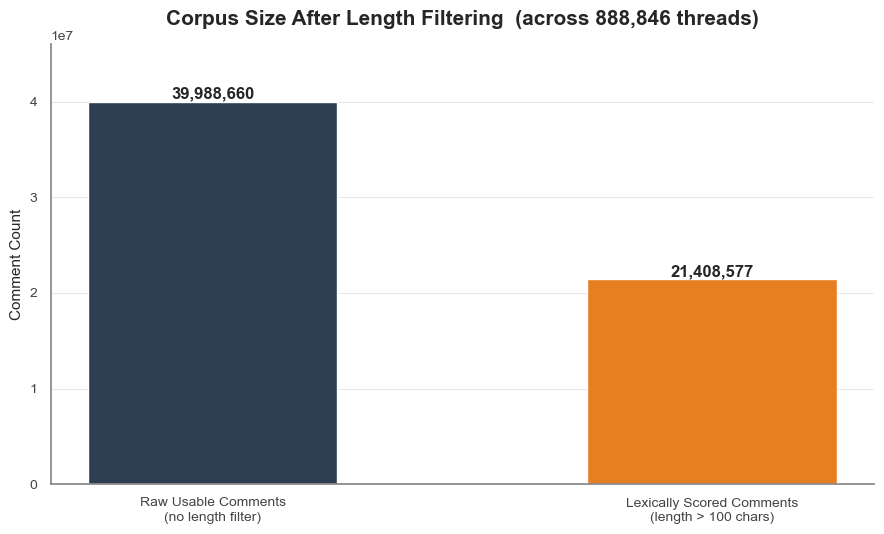

In [4]:
import utils.visualization as viz
viz.plot_corpus_size_funnel(raw, usable, threads)


Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/monthly_volume.csv


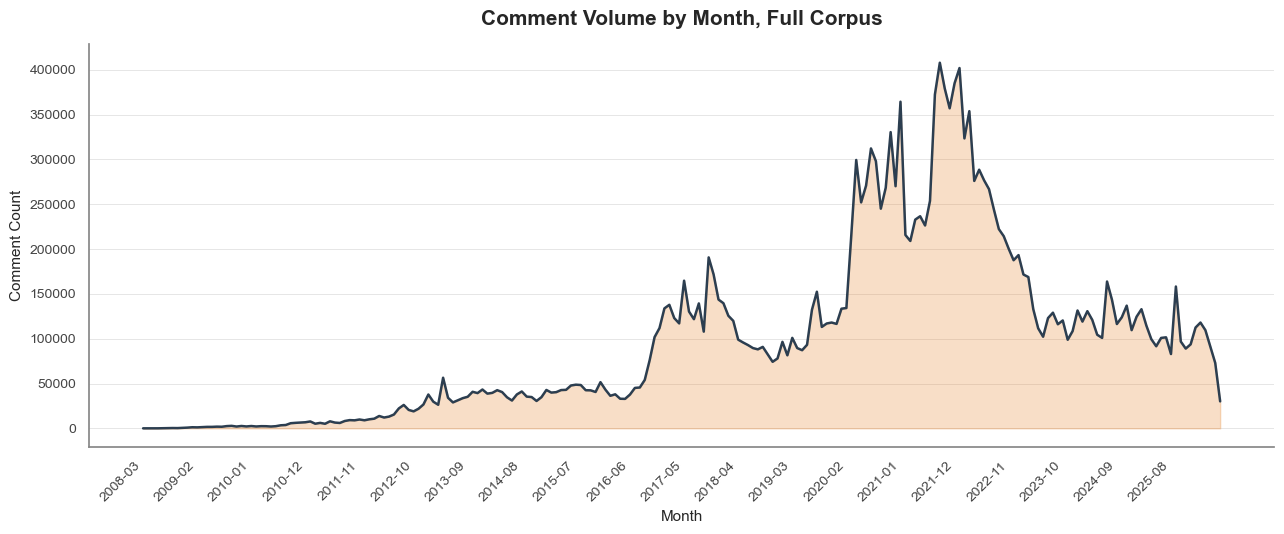

In [5]:
monthly_volume_query = f"""
    SELECT
        strftime(to_timestamp(created_utc), '%Y-%m') as month,
        COUNT(*) as n_comments
    FROM '{LEXICAL}'
    WHERE created_utc IS NOT NULL
    GROUP BY month
    ORDER BY month
"""
df_monthly_volume = cached_query_csv(con, BASE + 'monthly_volume.csv', monthly_volume_query)
viz.plot_monthly_volume(df_monthly_volume)


---
## 2. Lexical Scoring Pipeline

Five dimensions scored via SQL LIKE pattern matching across all 21M comments.
Scores reflect **presence** of category vocabulary (binary per term, summed).

| Dimension | What it captures |
|---|---|
| `hedge_count` | Epistemic uncertainty — *maybe, apparently, I think, probably* |
| `certainty_count` | Strong assertion — *proven, obviously, the truth is, wake up* |
| `evidence_count` | Evidence appeals — *according to, peer-reviewed, data shows, http* |
| `authority_count` | Authority appeals — *expert, scientist, government, CDC, FBI* |
| `rhetorical_count` | Rhetorical moves — *follow the money, sheeple, red pill, connect the dots* |

In [6]:
# Score distributions across corpus
print(con.execute(f"""
    SELECT 
        AVG(hedge_count) as avg_hedge,
        AVG(certainty_count) as avg_certainty,
        AVG(evidence_count) as avg_evidence,
        AVG(authority_count) as avg_authority,
        AVG(rhetorical_count) as avg_rhetorical,
        MAX(hedge_count) as max_hedge,
        MAX(certainty_count) as max_certainty,
        MAX(evidence_count) as max_evidence,
        MAX(authority_count) as max_authority,
        MAX(rhetorical_count) as max_rhetorical
    FROM '{LEXICAL}'
""").df().to_string())

   avg_hedge  avg_certainty  avg_evidence  avg_authority  avg_rhetorical  max_hedge  max_certainty  max_evidence  max_authority  max_rhetorical
0    0.14382       0.050698      0.215923         0.1083        0.344293          8              5             9              8               5


In [7]:
# Lexical scores vs upvotes — does epistemic style predict community reward?
print(con.execute(f"""
    SELECT 
        upvote_tier,
        COUNT(*) as n,
        ROUND(AVG(hedge_count), 3) as avg_hedge,
        ROUND(AVG(certainty_count), 3) as avg_certainty,
        ROUND(AVG(evidence_count), 3) as avg_evidence,
        ROUND(AVG(authority_count), 3) as avg_authority,
        ROUND(AVG(rhetorical_count), 3) as avg_rhetorical
    FROM (
        SELECT *,
            CASE 
                WHEN upvotes < 0 THEN 'negative'
                WHEN upvotes = 0 THEN 'zero'
                WHEN upvotes BETWEEN 1 AND 5 THEN 'low'
                WHEN upvotes BETWEEN 6 AND 50 THEN 'medium'
                WHEN upvotes > 50 THEN 'high'
            END AS upvote_tier
        FROM '{LEXICAL}'
    )
    GROUP BY upvote_tier
    ORDER BY 
        CASE upvote_tier 
            WHEN 'negative' THEN 1 WHEN 'zero' THEN 2 
            WHEN 'low' THEN 3 WHEN 'medium' THEN 4 WHEN 'high' THEN 5 
        END
""").df().to_string())

  upvote_tier         n  avg_hedge  avg_certainty  avg_evidence  avg_authority  avg_rhetorical
0    negative   1913929      0.129          0.054         0.144          0.111           0.338
1        zero   1618487      0.141          0.057         0.171          0.113           0.344
2         low  13879338      0.147          0.050         0.246          0.103           0.364
3      medium   3699036      0.142          0.051         0.165          0.123           0.282
4        high    297787      0.131          0.047         0.149          0.128           0.247


Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/upvote_tier_counts.csv


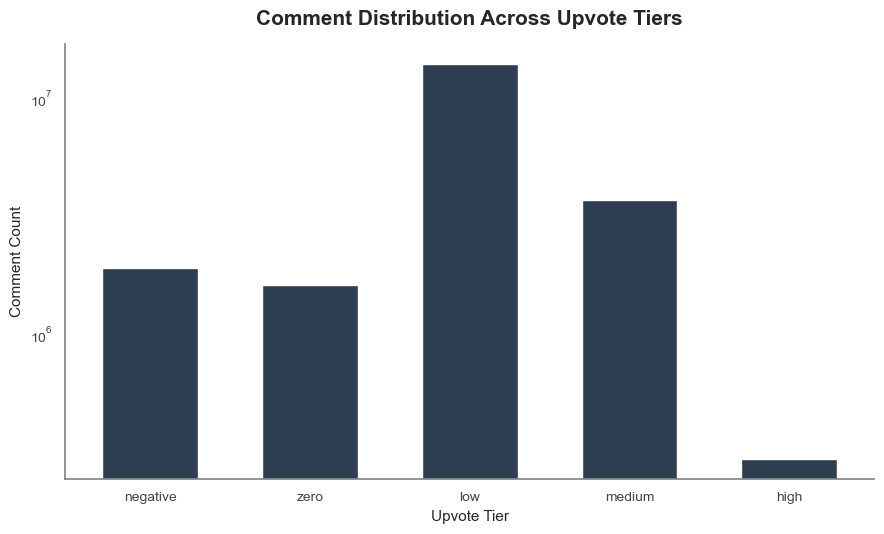

In [8]:
upvote_tier_query = f"""
    SELECT upvote_tier, COUNT(*) as n
    FROM (
        SELECT *,
            CASE
                WHEN upvotes < 0 THEN 'negative'
                WHEN upvotes = 0 THEN 'zero'
                WHEN upvotes BETWEEN 1 AND 5 THEN 'low'
                WHEN upvotes BETWEEN 6 AND 50 THEN 'medium'
                WHEN upvotes > 50 THEN 'high'
            END AS upvote_tier
        FROM '{LEXICAL}'
    )
    GROUP BY upvote_tier
    ORDER BY
        CASE upvote_tier
            WHEN 'negative' THEN 1 WHEN 'zero' THEN 2
            WHEN 'low' THEN 3 WHEN 'medium' THEN 4 WHEN 'high' THEN 5
        END
"""
df_upvote_tiers = cached_query_csv(con, BASE + 'upvote_tier_counts.csv', upvote_tier_query)
viz.plot_upvote_tier_distribution(df_upvote_tiers)


### 2.1 Lexical Scoring Validation

Manual spot-check: pull high scorers and zero-scorers-with-keywords to identify false positives and false negatives.

In [9]:
import json
import os
import pandas as pd

# --- Configuration ---
FORCE_RESAMPLE = False  # Change to True to ignore cache and query fresh samples

spot_check_cache = os.path.join(BASE, 'validation_spot_checks.csv')
count_cache = os.path.join(BASE, 'false_negative_counts.json')

dimensions = ['hedge_count', 'certainty_count', 'evidence_count', 'authority_count', 'rhetorical_count']
keyword_map = {
    'hedge_count': '%maybe%',
    'certainty_count': '%proven%',
    'evidence_count': '%according to%',
    'authority_count': '%scientist%',
    'rhetorical_count': '%wake up%'
}

# 1. FALSE NEGATIVE COUNT CACHE
if not FORCE_RESAMPLE and os.path.exists(count_cache):
    with open(count_cache, 'r') as f:
        counts = json.load(f)
    print(f"Cached False Negatives (hedge_count = 0, contains 'maybe'): {counts['maybe_count']}")
else:
    print("Querying false negative counts...")
    maybe_count = con.execute(f"""
        SELECT COUNT(*) FROM '{LEXICAL}'
        WHERE hedge_count = 0 AND lower(text) LIKE '%maybe%'
    """).fetchone()[0]
    
    with open(count_cache, 'w') as f:
        json.dump({'maybe_count': maybe_count}, f)
    print(f"False Negatives: {maybe_count}")

# 2. SPOT CHECK CACHE 
if not FORCE_RESAMPLE and os.path.exists(spot_check_cache):
    print("\nLoading cached validation samples...\n")
    df_checks = pd.read_csv(spot_check_cache)
    
    for dim in dimensions:
        print(f"\n{'='*70}\nDIMENSION: {dim} — HIGH SCORERS (score >= 3)\n{'='*70}\n")
        high_scorers = df_checks[(df_checks['dimension'] == dim) & (df_checks['type'] == 'high_scorer')]
        for _, row in high_scorers.iterrows():
            print(f"[Score: {int(row['score'])} | Upvotes: {row['upvotes']}]\n{row['text'][:400]}\n{'-'*50}")
            
        print(f"\n--- FALSE NEGATIVE CHECK: score=0 but contains keyword ---\n")
        false_negs = df_checks[(df_checks['dimension'] == dim) & (df_checks['type'] == 'false_negative')]
        for _, row in false_negs.iterrows():
            print(f"[Score: 0 | Upvotes: {row['upvotes']}]\n{row['text'][:400]}\n{'-'*50}")

else:
    print("\nQuerying validation samples from database...")
    all_results = []
    
    for dim in dimensions:
        print(f"Processing {dim}...")
        
        # High Scorers 
        high_res = con.execute(f"""
            SELECT '{dim}' as dimension, 'high_scorer' as type, {dim} as score, upvotes, text
            FROM '{LEXICAL}'
            WHERE {dim} >= 3
            ORDER BY RANDOM()
            LIMIT 5
        """).df()
        all_results.append(high_res)
        
        # False Negatives 
        false_res = con.execute(f"""
            SELECT '{dim}' as dimension, 'false_negative' as type, {dim} as score, upvotes, text
            FROM '{LEXICAL}'
            WHERE {dim} = 0 AND lower(text) LIKE '{keyword_map[dim]}'
            ORDER BY RANDOM()
            LIMIT 3
        """).df()
        all_results.append(false_res)
        
    df_checks = pd.concat(all_results, ignore_index=True)
    df_checks.to_csv(spot_check_cache, index=False)
    print("\nValidation samples cached successfully. They will print immediately now.")
    
    for dim in dimensions:
        print(f"\n{'='*70}\nDIMENSION: {dim} — HIGH SCORERS (score >= 3)\n{'='*70}\n")
        high_scorers = df_checks[(df_checks['dimension'] == dim) & (df_checks['type'] == 'high_scorer')]
        for _, row in high_scorers.iterrows():
            print(f"[Score: {int(row['score'])} | Upvotes: {row['upvotes']}]\n{row['text'][:400]}\n{'-'*50}")
            
        print(f"\n--- FALSE NEGATIVE CHECK: score=0 but contains keyword ---\n")
        false_negs = df_checks[(df_checks['dimension'] == dim) & (df_checks['type'] == 'false_negative')]
        for _, row in false_negs.iterrows():
            print(f"[Score: 0 | Upvotes: {row['upvotes']}]\n{row['text'][:400]}\n{'-'*50}")

Cached False Negatives (hedge_count = 0, contains 'maybe'): 0

Loading cached validation samples...


DIMENSION: hedge_count — HIGH SCORERS (score >= 3)

[Score: 3 | Upvotes: 7.0]
Someone told me that I believe in "fringe conspiracy theories" because I said the CIA *probably* had a hand in Venezuela's decline (the same guy reported my comment to the mods of /r/worldnews, who deleted it because "read a fucking book for once" is apparently a terrible insult. I only demolished his fucking post after he claimed I was ignorant...). The thing is, the CIA has had a hand in the ove
--------------------------------------------------
[Score: 3 | Upvotes: 2.0]
Shift 18 first half of title decodes to: BLACK CUBE
Shift 19 the 2nd half of the title decodes to: RED HEART

You can play with it at : https://cryptii.com/pipes/caesar-cipher

Description is not caesar i think but perhaps viginere or other polyalphabetic cipher. maybe the title is the key.
--------------------------------------------------

---
## 3. Attribution Classification (spaCy)

Stage 1: 614,888 comments filtered by attribution syntax (2.9% of corpus)  
Stage 2: spaCy dependency parsing + NER to classify attribution type

Categories map onto FACTAPPEAL annotation scheme.

> **Methodology note:** spaCy's dependency-parsing classifier (the per-comment `attribution_class` typology used throughout this section) had known reliability issues on raw, ungrammatical Reddit text -- see `handoff/PROJECT_INVENTORY.md` §2A. It was not discarded; instead, this section trains a more robust TF-IDF + Logistic Regression **FactAppeal classifier** (`data/processed/factappeal/`) as a *validation gate*: a comment's fine-grained spaCy attribution type is only trusted (kept as-is; `validated_spacy_type`) if FactAppeal's simpler, more reliable binary flag confirms an attribution is actually present, otherwise it's overwritten to `'None'` (cells below, "Synthesizing validated attributions with SpaCy metadata"). A newer, fully local, deterministic **Attribution Confidence Scorer** (`src/attribution_confidence_scorer.py`) exists and is validated against human labels, but is not yet wired into the core regression (`handoff/task_attribution_scorer_wiring.md`) -- it isn't used anywhere in this notebook yet.


In [10]:
import pandas as pd
import os
import re
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# --- Configuration ---
BASE_DIR = BASE + 'factappeal'
MODEL_CACHE_PATH = os.path.join(BASE_DIR, 'factappeal_classifier.pkl')
VEC_CACHE_PATH = os.path.join(BASE_DIR, 'factappeal_vectorizer.pkl')

def parse_fact_appeal_csv(filepath):
    """
    Reads the FactAppeal CSV structure using the correct columns:
    'sentence' (raw text) and 'annotation' (XML tagged text).
    """
    df_raw = pd.read_csv(filepath)
    parsed_data = []
    
    for _, row in df_raw.iterrows():
        annotation_text = str(row['annotation']).strip()
        clean_text = re.sub(r'<.*?>', '', annotation_text)
        
        if '<Fact_Appeal' in annotation_text or '<Source' in annotation_text:
            label = 1
        else:
            label = 0
            
        parsed_data.append({'text': clean_text, 'label': label})
        
    return pd.DataFrame(parsed_data)

# --- Checkpoint Verification ---
if os.path.exists(MODEL_CACHE_PATH) and os.path.exists(VEC_CACHE_PATH):
    print("Loading pre-trained baseline classifier and vectorizer from disk cache...")
    classifier = joblib.load(MODEL_CACHE_PATH)
    vectorizer = joblib.load(VEC_CACHE_PATH)
    print("Pipeline ready.")
    
else:
    print("Cache missing. Re-building and training the optimal baseline model...")
    
    # 1. Load and parse the files
    print("Parsing train, val, and test splits...")
    train_df = parse_fact_appeal_csv(os.path.join(BASE_DIR, 'train.csv'))
    val_df = parse_fact_appeal_csv(os.path.join(BASE_DIR, 'val.csv'))
    test_df = parse_fact_appeal_csv(os.path.join(BASE_DIR, 'test.csv'))

    # 2. Extract features
    print("Vectorizing structural text features...")
    vectorizer = TfidfVectorizer(
        analyzer='word',
        ngram_range=(1, 3),
        max_features=15000,
        sublinear_tf=True
    )

    X_train = vectorizer.fit_transform(train_df['text'])
    y_train = train_df['label']

    X_val = vectorizer.transform(val_df['text'])
    y_val = val_df['label']

    X_test = vectorizer.transform(test_df['text'])
    y_test = test_df['label']

    # 3. Train the Local Classifier
    print("Training classifier locally...")
    classifier = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    classifier.fit(X_train, y_train)

    # 4. Serialize out to disk so you never have to train it again
    print("Saving pipeline components to cache...")
    joblib.dump(classifier, MODEL_CACHE_PATH)
    joblib.dump(vectorizer, VEC_CACHE_PATH)

    # 5. Evaluate on Validation Set
    val_preds = classifier.predict(X_val)
    print("\n=== Validation Set Performance ===")
    print(classification_report(y_val, val_preds))

    # 6. Final Evaluation on Unseen Test Set
    test_preds = classifier.predict(X_test)
    print("\n=== Final Test Set Performance ===")
    print(classification_report(y_test, test_preds))

Loading pre-trained baseline classifier and vectorizer from disk cache...
Pipeline ready.


In [11]:
import pandas as pd
import os
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# --- Configuration ---
BASE_DIR = BASE + 'factappeal'

def parse_fact_appeal_csv(filepath):
    """
    Reads the FactAppeal CSV structure using the correct columns:
    'sentence' (raw text) and 'annotation' (XML tagged text).
    """
    df_raw = pd.read_csv(filepath)
    
    parsed_data = []
    
    # Iterate through the rows using the exact columns from the README
    for _, row in df_raw.iterrows():
        annotation_text = str(row['annotation']).strip()
        
        # 1. Clean out all XML tags to get raw text for machine learning features
        clean_text = re.sub(r'<.*?>', '', annotation_text)
        
        # 2. Define target label: Look for any form of Fact_Appeal or Source tags
        # If the string contains an appeal or source tag, it's an attribution sentence (1)
        if '<Fact_Appeal' in annotation_text or '<Source' in annotation_text:
            label = 1
        else:
            label = 0
            
        parsed_data.append({'text': clean_text, 'label': label})
        
    return pd.DataFrame(parsed_data)

# 1. Load and parse the files using the exact names from the README
print("Parsing train, val, and test splits...")
train_df = parse_fact_appeal_csv(os.path.join(BASE_DIR, 'train.csv'))
val_df = parse_fact_appeal_csv(os.path.join(BASE_DIR, 'val.csv'))
test_df = parse_fact_appeal_csv(os.path.join(BASE_DIR, 'test.csv'))

# 2. Extract features using word n-grams (1 to 3 words long)
# This captures structural sequences like "said that", "according to", or "criticized the"
print("Vectorizing structural text features...")
vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 3),
    max_features=15000,
    sublinear_tf=True # Smooths out term frequency scaling
)

X_train = vectorizer.fit_transform(train_df['text'])
y_train = train_df['label']

X_val = vectorizer.transform(val_df['text'])
y_val = val_df['label']

X_test = vectorizer.transform(test_df['text'])
y_test = test_df['label']

# 3. Train the Local Classifier
print("Training classifier locally...")
classifier = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
classifier.fit(X_train, y_train)

# 4. Evaluate on Validation Set
val_preds = classifier.predict(X_val)
print("\n=== Validation Set Performance ===")
print(classification_report(y_val, val_preds))

# 5. Final Evaluation on Unseen Test Set
test_preds = classifier.predict(X_test)
print("\n=== Final Test Set Performance ===")
print(classification_report(y_test, test_preds))

Parsing train, val, and test splits...
Vectorizing structural text features...


Training classifier locally...

=== Validation Set Performance ===
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       332
           1       0.74      0.72      0.73       151

    accuracy                           0.83       483
   macro avg       0.81      0.80      0.80       483
weighted avg       0.83      0.83      0.83       483


=== Final Test Set Performance ===
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       332
           1       0.74      0.72      0.73       151

    accuracy                           0.83       483
   macro avg       0.81      0.80      0.80       483
weighted avg       0.83      0.83      0.83       483



In [12]:
con.execute(f"DESCRIBE SELECT * FROM read_parquet('{EMPATH}')").fetchall()

[('id', 'VARCHAR', 'YES', None, None, None),
 ('author', 'VARCHAR', 'YES', None, None, None),
 ('upvotes', 'DOUBLE', 'YES', None, None, None),
 ('controversiality', 'BIGINT', 'YES', None, None, None),
 ('parent_id', 'VARCHAR', 'YES', None, None, None),
 ('link_id', 'VARCHAR', 'YES', None, None, None),
 ('created_utc', 'BIGINT', 'YES', None, None, None),
 ('char_length', 'BIGINT', 'YES', None, None, None),
 ('has_link', 'INTEGER', 'YES', None, None, None),
 ('text', 'VARCHAR', 'YES', None, None, None),
 ('evidence_count', 'INTEGER', 'YES', None, None, None),
 ('adversarial_count', 'INTEGER', 'YES', None, None, None),
 ('hedge_count', 'INTEGER', 'YES', None, None, None),
 ('certainty_count', 'INTEGER', 'YES', None, None, None),
 ('alt_authority_count', 'INTEGER', 'YES', None, None, None),
 ('intuitive_count', 'INTEGER', 'YES', None, None, None),
 ('pattern_count', 'INTEGER', 'YES', None, None, None),
 ('meta_count', 'INTEGER', 'YES', None, None, None),
 ('demand_count', 'INTEGER', 'YES',

In [13]:
# STREAMING_CHUNK: Executing high-signal query filters...
import duckdb
import pandas as pd
import os

con = duckdb.connect()
FILTERED_CACHE = os.path.join(BASE, 'filtered_candidates.parquet')

# Build the SQL query using your target filters
# We wrap it in a COPY command to write directly to Parquet
query = f"""
    COPY (
        SELECT id, author, text 
        FROM read_parquet('{EMPATH}')
        WHERE evidence_count > 0 
           OR has_link = 1 
           OR alt_authority_count > 0 
           OR quantitative_count > 0
    ) TO '{FILTERED_CACHE}' (FORMAT PARQUET, COMPRESSION 'zstd')
"""

if not os.path.exists(FILTERED_CACHE):
    print("Filtering 21M corpus and caching to Parquet...")
    # DuckDB writes the result straight to disk, bypassing RAM limitations
    con.execute(query)
else:
    print("Loading filtered subset from Parquet cache...")

# Load into Pandas memory for the upcoming annotation pipeline
filtered_df = pd.read_parquet(FILTERED_CACHE)
print(f"Original rows: 21,000,000 | Filtered rows: {len(filtered_df):,}")

Loading filtered subset from Parquet cache...


Original rows: 21,000,000 | Filtered rows: 4,781,460


In [14]:
import pandas as pd
import re
import joblib
import os
import glob

# --- 1. Load Pre-trained Models & Data ---
MODEL_CACHE_PATH = os.path.join(BASE_DIR, 'factappeal_classifier.pkl')
VEC_CACHE_PATH = os.path.join(BASE_DIR, 'factappeal_vectorizer.pkl')

print("Loading vectorizer and classifier...")
vectorizer = joblib.load(VEC_CACHE_PATH)
classifier = joblib.load(MODEL_CACHE_PATH)

# BASE is already set globally in the setup cell (Section 0)
FILTERED_CACHE = os.path.join(BASE, 'filtered_candidates.parquet')
run_df = pd.read_parquet(FILTERED_CACHE)

# --- 2. Setup Chunking & Checkpoints ---
CHUNK_SIZE = 5000  # Process 5,000 comments at a time
OUTPUT_DIR = os.path.join(BASE_DIR, 'annotated_chunks')
os.makedirs(OUTPUT_DIR, exist_ok=True)

def split_into_sentences(text):
    if not text or not isinstance(text, str):
        return []
    sentences = re.split(r'(?<=[.!?])\s+', text)
    return [s.strip() for s in sentences if s.strip()]

print(f"Starting batch inference on {len(run_df):,} comments...")

# --- 3. Execute in Batches ---
for start_idx in range(0, len(run_df), CHUNK_SIZE):
    end_idx = min(start_idx + CHUNK_SIZE, len(run_df))
    chunk_file = os.path.join(OUTPUT_DIR, f"chunk_{start_idx}_to_{end_idx}.parquet")
    
    # CHECKPOINT: Skip if this chunk is already done
    if os.path.exists(chunk_file):
        print(f"Skipping {start_idx} to {end_idx} (already cached)")
        continue
        
    print(f"Processing rows {start_idx:,} to {end_idx:,}...")
    chunk = run_df.iloc[start_idx:end_idx].copy()
    
    all_sentences = []
    sentence_to_comment_map = []
    
    # A. Flatten all sentences for batch vectorization
    for i, text in enumerate(chunk['text']):
        sentences = split_into_sentences(text)
        for s in sentences:
            all_sentences.append(s)
            sentence_to_comment_map.append(i) # Tracks which comment this sentence belongs to
            
    if not all_sentences:
        chunk['annotated_body'] = ""
        chunk['contains_attribution_flag'] = 0
        chunk.to_parquet(chunk_file)
        continue
        
    # B. Vectorize and Predict ALL sentences in this chunk AT ONCE
    # (This eliminates the scikit-learn loop overhead)
    X_batch = vectorizer.transform(all_sentences)
    predictions = classifier.predict(X_batch)
    
    # C. Reassemble the tagged sentences back into their original comments
    annotated_bodies = [[] for _ in range(len(chunk))]
    has_attr = [0 for _ in range(len(chunk))]
    
    for s, pred, c_idx in zip(all_sentences, predictions, sentence_to_comment_map):
        if pred == 1:
            annotated_bodies[c_idx].append(f"<Fact_With_Attribution>{s}</Fact_With_Attribution>")
            has_attr[c_idx] = 1
        else:
            annotated_bodies[c_idx].append(f"<Fact_No_Appeal>{s}</Fact_No_Appeal>")
            
    chunk['annotated_body'] = [" ".join(lst) for lst in annotated_bodies]
    chunk['contains_attribution_flag'] = has_attr
    
    # D. Save the completed chunk to disk
    chunk.to_parquet(chunk_file, compression='zstd')

print("\nAll chunks processed! Combining into final dataset...")

# --- 4. Combine Chunks ---
chunk_files = glob.glob(os.path.join(OUTPUT_DIR, "chunk_*.parquet"))
final_df = pd.concat([pd.read_parquet(f) for f in chunk_files], ignore_index=True)

FINAL_OUTPUT_PATH = os.path.join(BASE_DIR, 'annotated_candidates_final.parquet')
final_df.to_parquet(FINAL_OUTPUT_PATH, compression='zstd')

print(f"Done. Saved final annotated dataset ({len(final_df):,} rows) to {FINAL_OUTPUT_PATH}")

Loading vectorizer and classifier...


Starting batch inference on 4,781,460 comments...
Skipping 0 to 5000 (already cached)
Skipping 5000 to 10000 (already cached)
Skipping 10000 to 15000 (already cached)
Skipping 15000 to 20000 (already cached)
Skipping 20000 to 25000 (already cached)
Skipping 25000 to 30000 (already cached)
Skipping 30000 to 35000 (already cached)
Skipping 35000 to 40000 (already cached)
Skipping 40000 to 45000 (already cached)
Skipping 45000 to 50000 (already cached)
Skipping 50000 to 55000 (already cached)
Skipping 55000 to 60000 (already cached)
Skipping 60000 to 65000 (already cached)
Skipping 65000 to 70000 (already cached)
Skipping 70000 to 75000 (already cached)
Skipping 75000 to 80000 (already cached)
Skipping 80000 to 85000 (already cached)
Skipping 85000 to 90000 (already cached)
Skipping 90000 to 95000 (already cached)
Skipping 95000 to 100000 (already cached)
Skipping 100000 to 105000 (already cached)
Skipping 105000 to 110000 (already cached)
Skipping 110000 to 115000 (already cached)
Skippi

Done. Saved final annotated dataset (4,781,460 rows) to /Users/nash/Projects/ConspiracyComments/data/processed/factappeal/annotated_candidates_final.parquet


In [15]:
import duckdb
import os

con = duckdb.connect()
FINAL_OUTPUT_PATH = os.path.join(BASE_DIR, 'annotated_candidates_final.parquet')

# 1. Quick distribution check: How many comments actually got an attribution flag?
print("=== ATTRIBUTION FLAG DISTRIBUTION ===")
print(con.execute(f"""
    SELECT contains_attribution_flag, COUNT(*) as count
    FROM read_parquet('{FINAL_OUTPUT_PATH}')
    GROUP BY contains_attribution_flag
""").df())

# 2. Spot check: Grab 3 examples where an attribution was successfully caught
print("\n=== SAMPLE DETECTED ATTRIBUTIONS ===")
samples = con.execute(f"""
    SELECT author, annotated_body 
    FROM read_parquet('{FINAL_OUTPUT_PATH}')
    WHERE contains_attribution_flag = 1
    LIMIT 3
""").df()

for i, row in samples.iterrows():
    print(f"\nAuthor: {row['author']}")
    print(f"Body: {row['annotated_body'][:500]}...")
    print("-" * 60)

=== ATTRIBUTION FLAG DISTRIBUTION ===
   contains_attribution_flag    count
0                          0  3886014
1                          1   895446

=== SAMPLE DETECTED ATTRIBUTIONS ===

Author: Fearless-Past9652
Body: <Fact_With_Attribution>He said it himself:

https://www.theguardian.com/technology/2022/aug/06/andrew-tate-violent-misogynistic-world-of-tiktok-new-star</Fact_With_Attribution>...
------------------------------------------------------------

Author: a_human-being
Body: <Fact_No_Appeal>SS:

  
this resolution is driving us in the opposite direction, so i proudly voted against it.</Fact_No_Appeal> <Fact_No_Appeal>It peddles the latest lie that this is not now about defending Ukraine.</Fact_No_Appeal> <Fact_No_Appeal>It's about "Ukraine must win".</Fact_No_Appeal> <Fact_No_Appeal>What does that even mean?</Fact_No_Appeal> <Fact_With_Attribution>Last Apri...
------------------------------------------------------------

Author: whosadooza
Body: <Fact_With_Attribution>No, 

In [16]:
import duckdb
import os

BASE_DIR = BASE + 'factappeal'
INPUT_PATH = os.path.join(BASE_DIR, 'annotated_candidates_final.parquet')
CORRECTED_PATH = os.path.join(BASE_DIR, 'annotated_candidates_corrected.parquet')

con = duckdb.connect()

print("Correcting temporal false positives directly on disk...")

# This SQL regex locates any <Fact_With_Attribution> tags that wrap around 
# temporal phrases like 'last April' or explicit years, and flips them to <Appeal_Time>.
con.execute(f"""
    CREATE OR REPLACE TEMP TABLE corrected_data AS
    SELECT 
        id,
        author,
        text,
        -- Replace the XML tags for sentences containing specific time markers
        regexp_replace(
            annotated_body, 
            '<Fact_With_Attribution>([^<]*?\\b(last April|last year|in \\d{{4}})\\b[^<]*?)</Fact_With_Attribution>', 
            '<Appeal_Time>\\1</Appeal_Time>', 
            'g'
        ) AS annotated_body
    FROM read_parquet('{INPUT_PATH}');
""")

print("Recalculating clean source attribution flags...")

# Re-evaluate the boolean flag: if the text still contains a true source tag, it's a 1.
# If it only contains time tags or no-appeal tags, it becomes a 0.
con.execute(f"""
    COPY (
        SELECT 
            *,
            CASE 
                WHEN annotated_body LIKE '%<Fact_With_Attribution>%' THEN 1 
                ELSE 0 
            END AS contains_attribution_flag
        FROM corrected_data
    ) TO '{CORRECTED_PATH}' (FORMAT PARQUET, COMPRESSION 'zstd')
""")

print(f"Done! Cleaned dataset written to {CORRECTED_PATH}")

Correcting temporal false positives directly on disk...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Recalculating clean source attribution flags...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Done! Cleaned dataset written to /Users/nash/Projects/ConspiracyComments/data/processed/factappeal/annotated_candidates_corrected.parquet


In [17]:
print(con.execute(f"""
    SELECT contains_attribution_flag, COUNT(*) 
    FROM read_parquet('{CORRECTED_PATH}') 
    GROUP BY contains_attribution_flag
""").df())

   contains_attribution_flag  count_star()
0                          0       3896075
1                          1        885385


In [18]:
# Distribution of attribution classes
print(con.execute(f"""
    SELECT attribution_class, COUNT(*) as n,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as pct
    FROM '{SPACY}'
    GROUP BY attribution_class
    ORDER BY n DESC
""").df().to_string())

                attribution_class       n    pct
0   Indirect_Quote:Named_Official  139342  22.66
1              Direct_Quote:Named  134889  21.94
2      Indirect_Quote:News_Report  111579  18.15
3            No_Clear_Attribution   73014  11.87
4     Indirect_Quote:Unattributed   58581   9.53
5            Direct_Quote:Unnamed   53717   8.74
6      Indirect_Quote:Named_Other   24315   3.95
7             Direct_Quote:Expert   15072   2.45
8   Indirect_Quote:Unnamed_Expert    2722   0.44
9     Indirect_Quote:Named_Expert    1269   0.21
10  Indirect_Quote:Unnamed_Source     388   0.06


In [19]:
# Attribution class vs community engagement
print(con.execute(f"""
    SELECT 
        attribution_class,
        COUNT(*) as n,
        ROUND(AVG(upvotes), 2) as avg_upvotes,
        ROUND(MEDIAN(upvotes), 2) as median_upvotes,
        ROUND(AVG(controversiality), 3) as avg_controversy
    FROM '{SPACY}'
    GROUP BY attribution_class
    ORDER BY avg_upvotes DESC
""").df().to_string())

                attribution_class       n  avg_upvotes  median_upvotes  avg_controversy
0   Indirect_Quote:Unnamed_Source     388         7.01             2.0            0.070
1              Direct_Quote:Named  134889         6.30             2.0            0.084
2            No_Clear_Attribution   73014         5.97             2.0            0.067
3            Direct_Quote:Unnamed   53717         5.38             2.0            0.076
4      Indirect_Quote:Named_Other   24315         5.24             2.0            0.080
5      Indirect_Quote:News_Report  111579         5.06             2.0            0.073
6   Indirect_Quote:Named_Official  139342         5.03             2.0            0.074
7             Direct_Quote:Expert   15072         4.98             2.0            0.069
8   Indirect_Quote:Unnamed_Expert    2722         4.59             1.0            0.077
9     Indirect_Quote:Unattributed   58581         4.38             1.0            0.070
10    Indirect_Quote:Named_Exper

In [20]:
import duckdb
import os

con = duckdb.connect()
SPACY_CSV_PATH = BASE + 'spacy_attribution_results.csv'
NEW_PARQUET_PATH = BASE + 'factappeal/annotated_candidates_final.parquet'

print("Pulling spot-check examples for SpaCy audit...\n")

# Query the raw text from the parquet file by matching the IDs from the SpaCy CSV
audit_df = con.execute(f"""
    SELECT s.attribution_class, p.text 
    FROM read_parquet('{SPACY}') s
    JOIN read_parquet('{NEW_PARQUET_PATH}') p ON s.id = p.id
    WHERE s.attribution_class IN ('Indirect_Quote:Named_Official', 'Direct_Quote:Named')
    USING SAMPLE 10;
""").df()

for i, row in audit_df.iterrows():
    print(f"[{row['attribution_class']}]")
    print(f"Text: {row['text'][:350]}...\n")
    print("-" * 60)

Pulling spot-check examples for SpaCy audit...



[Indirect_Quote:Named_Official]
Text:   


  


# Senator John Kerry's Aide. Jonathan Winer interview: Jackie Kennedy tried to squash BCCI Investigation.[http://www.pbs.org/wgbh/pages/frontline/shows/choice2004/interviews/winer.html](http://www.pbs.org/wgbh/pages/frontline/shows/choice2004/interviews/winer.html)see also:[http://www.pbs.org/wgbh/pages/frontline/shows/drugs/special/winer...

------------------------------------------------------------
[Direct_Quote:Named]
Text: "The number" is just one of many metrics, and the one that you chose (convictions for sex trafficking) had steadily dropped from 2016 to 2018 (369 to 281). Characterizing the increase in 2019 as a success is disingenuous. By the way, Obama's 2nd to last year saw **789** convicted human trafficking defendants, according to the [Bureau Of Justice Sta...

------------------------------------------------------------
[Indirect_Quote:Named_Official]
Text: http://www.foxnews.com/politics/2015/04/16/clinton-foundation-to-

In [21]:
import duckdb
import pandas as pd

con = duckdb.connect()
SPACY_CSV_PATH = BASE + 'spacy_attribution_results.csv'

print("Pulling stratified sample for SpaCy precision audit...\n")

audit_df = con.execute(f"""
    WITH sampled AS (
        SELECT 
            attribution_class, 
            text,
            ROW_NUMBER() OVER (PARTITION BY attribution_class ORDER BY RANDOM()) as rn
        FROM read_parquet('{SPACY}')
        WHERE attribution_class IN (
            'Indirect_Quote:Named_Expert', 
            'Direct_Quote:Expert', 
            'Indirect_Quote:Unnamed_Source', 
            'Indirect_Quote:Named_Official'
        )
    )
    SELECT attribution_class, text 
    FROM sampled 
    WHERE rn <= 15;
""").df()

# Export this to a quick CSV so you can manually score it
AUDIT_OUTPUT = BASE + 'spacy_audit_scratchpad.csv'
audit_df.to_csv(AUDIT_OUTPUT, index=False)

print(f"Audit scratchpad saved to: {AUDIT_OUTPUT}")
print("Open this in Excel/Numbers, add a 'True_Positive' column (1 or 0), and tally the scores.")

Pulling stratified sample for SpaCy precision audit...



Audit scratchpad saved to: /Users/nash/Projects/ConspiracyComments/data/processed/spacy_audit_scratchpad.csv
Open this in Excel/Numbers, add a 'True_Positive' column (1 or 0), and tally the scores.


In [22]:
import duckdb
import os

VALIDATED_PARQUET_PATH = BASE + 'factappeal/annotated_candidates_final.parquet'
FINAL_ENRICHED_PATH = BASE + 'research_corpus_enriched.parquet'

con = duckdb.connect()

print("Synthesizing validated attributions with SpaCy metadata...")

con.execute(f"""
    COPY (
        SELECT 
            p.*,
            -- ONLY include SpaCy class if the FactAppeal model confirmed an attribution
            CASE 
                WHEN p.contains_attribution_flag = 1 THEN s.attribution_class 
                ELSE 'None' 
            END AS validated_spacy_type
        FROM read_parquet('{VALIDATED_PARQUET_PATH}') p
        LEFT JOIN read_parquet('{SPACY}') s 
            ON p.id = s.id
    ) TO '{FINAL_ENRICHED_PATH}' (FORMAT PARQUET, COMPRESSION 'zstd')
""")

print(f"Success! Enriched dataset saved to {FINAL_ENRICHED_PATH}")

Synthesizing validated attributions with SpaCy metadata...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Success! Enriched dataset saved to /Users/nash/Projects/ConspiracyComments/data/processed/research_corpus_enriched.parquet


In [23]:

con = duckdb.connect()

print("=== Validated SpaCy Type Distribution ===")
# This shows how many SpaCy labels were kept (the ones flagged by the model)
# vs how many were discarded (marked as 'None')
dist = con.execute(f"""
    SELECT validated_spacy_type, COUNT(*) as n
    FROM read_parquet('{FINAL_ENRICHED_PATH}')
    GROUP BY validated_spacy_type
    ORDER BY n DESC
""").df()
print(dist)

print("\n=== Spot-Check Examples (Flagged as Fact-Appeal + SpaCy Type) ===")
# This pulls 10 random samples of successful attributions 
# that also have a specific SpaCy typology assigned
spot_checks = con.execute(f"""
    SELECT validated_spacy_type, text
    FROM read_parquet('{FINAL_ENRICHED_PATH}')
    WHERE validated_spacy_type != 'None'
    AND validated_spacy_type != 'No_Clear_Attribution'
    ORDER BY RANDOM()
    LIMIT 8
""").df()

for i, row in spot_checks.iterrows():
    print(f"\nType: {row['validated_spacy_type']}")
    print(f"Text: {row['text'][:250]}...")
    print("-" * 60)

=== Validated SpaCy Type Distribution ===
             validated_spacy_type        n
0                            None  3886110
1                            None   692659
2              Direct_Quote:Named    46183
3   Indirect_Quote:Named_Official    40789
4            No_Clear_Attribution    38399
5      Indirect_Quote:News_Report    37614
6            Direct_Quote:Unnamed    16628
7     Indirect_Quote:Unattributed     8183
8             Direct_Quote:Expert     7281
9      Indirect_Quote:Named_Other     6361
10  Indirect_Quote:Unnamed_Expert     1279
11    Indirect_Quote:Named_Expert      659
12  Indirect_Quote:Unnamed_Source      245

=== Spot-Check Examples (Flagged as Fact-Appeal + SpaCy Type) ===


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Type: Direct_Quote:Named
Text: This pisses me off mainly because he has literally said that he had a plan to stop the next pandemic 5 years ago right after Ebola. Every article involving him talked about this plan...he even wrote a whole journal on ways to prevent this next pandemic but clearly didn’t. AND 5 years ago said that the next attack was going to be bioterrorism. Here’s some articles from a couple years ago:


[Bill G...
------------------------------------------------------------

Type: Direct_Quote:Named
Text: "Trolling" goes to what his intend is.

According to CNN, yesterday, a Rand Paul's question naming the whistle blower was refused (Most questions are pre-authorized by the Chief Justice, he literally signs them. You can see that he looks the back side of the question paper and either read it out loud immediately, or reads it and then announces it). It is my belief that todays "on the fly" question...
------------------------------------------------------------

Type:

In [24]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Load your CSV
# Replace 'dataset.csv' and 'column_name' with your actual file and column header
df_raw = pd.read_csv(BASE + 'factappeal/train.csv')

In [25]:
df_raw

,sentence,annotation
0,Using campaign funds for personal use is a violation of federal campaign law.,<Fact_No_Appeal>Using campaign funds for personal use is a violation of federal campaign law.</Fact_No_Appeal>
1,The move by North Korea was the first of its kind since Trump took office January 20.,<Fact_No_Appeal>The move by North Korea was the first of its kind since Trump took office January 20.</Fact_No_Appeal>
2,It seems like her job had an insurance policy on her and she didn't even know.,<Fact_No_Appeal>It seems like her job had an insurance policy on her and she didn't even know.</Fact_No_Appeal>
3,"He knew that his own parents had been investigated by the caseworkers who picked him up, but the boy in the car was not the person whom protective services thought he was.","<Fact_No_Appeal>He knew that his own parents had been investigated by the caseworkers who picked him up, but the boy in the car was not the person whom protective services thought he was.</Fact_No_Appeal>"
4,"What was also interesting is that the shy ones that cried for their parents, would shine once the parent left.","<Fact_No_Appeal>What was also interesting is that the shy ones that cried for their parents, would shine once the parent left.</Fact_No_Appeal>"
...,...,...
2251,"More than a month after Hurricane Maria ravaged Puerto Rico, most of the territory's residents -- U.S. citizens -- remain without power.","<Fact_No_Appeal>More than a month after Hurricane Maria ravaged Puerto Rico, most of the territory's residents -- U.S. citizens -- remain without power.</Fact_No_Appeal>"
2252,Most furloughed workers will likely eventually receive backpay for the time they were forced not to work.,<Fact_No_Appeal>Most furloughed workers will likely eventually receive backpay for the time they were forced not to work.</Fact_No_Appeal>
2253,"There will always be radicals among us, but they don't have to be so powerful.","<Fact_No_Appeal>There will always be radicals among us, but they don't have to be so powerful.</Fact_No_Appeal>"
2254,"Colleen Condon, a Democratic voting rights advocate in coastal South Carolina, called the turnout ""super,"" but she criticized the state for not being ready to handle so many voters.","<Fact_No_Appeal>Colleen Condon, a Democratic voting rights advocate in coastal South Carolina, called the turnout ""super,"" but she criticized the state for not being ready to handle so many voters.</Fact_No_Appeal>"


In [26]:
df = pd.DataFrame(parsed_data)

# 1. Check the exact distribution of your labels
print("\nLabel Distribution:")
print(df['label'].value_counts())

# 2. If it prints only '0', let's see what tags your regex is ACTUALLY finding
if 1 not in df['label'].values:
    print("\nWarning: No 1s found. Hunting for unique tags...")
    unique_tags = set(re.search(r'<(\w+)>', line).group(1) for line in raw_lines if re.search(r'<(\w+)>', line))
    print("Unique tags found in raw data:", unique_tags)

NameError: name 'parsed_data' is not defined

In [27]:
raw_lines = df_raw['annotation'].dropna().tolist()

parsed_data = []

# 2. Parse out the raw text and the target tags
for line in raw_lines:
    # This regex captures everything before the first tag, and then extracts the tag name
    # e.g., "Text... <Fact_No_Appeal>...</Fact_No_Appeal>"
    match = re.search(r'^(.*?)(<(\w+)>.*?</\3>)', line.strip())
    if match:
        full_text = match.group(1)
        tag_name = match.group(3)  # This captures "Fact_No_Appeal", "Fact_With_Attribution", etc.
        
        # Clean out any residual tags inside the main text body
        clean_text = re.sub(r'<.*?>', '', full_text).strip()
        
        # Binary Classification Target: 
        # Set to 1 if the tag indicates attribution, 0 if it doesn't
        # (Adjust 'With_Attribution' to match the exact name of the attribution tag in your dataset)
        label = 1 if 'Source_Attribute' in tag_name else 0
        
        parsed_data.append({'text': clean_text, 'label': label})

# Convert to a clean DataFrame
df = pd.DataFrame(parsed_data)

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

# 4. Feature Extraction (Word & Character N-Grams)
# Using structural n-grams (1 to 3 words) helps the model grab strings like "called the", 
# "criticized the", or "according to", which are strong lexical anchors for source attribution.
vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=10000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 5. Train the Local Classifier
# Using class_weight='balanced' ensures it doesn't get skewed if the dataset has a lot more 0s than 1s.
classifier = LogisticRegression(class_weight='balanced', max_iter=1000)
classifier.fit(X_train_vec, y_train)

# 6. Evaluate
y_pred = classifier.predict(X_test_vec)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       273
           1       0.48      0.52      0.50        21

    accuracy                           0.93       294
   macro avg       0.72      0.74      0.73       294
weighted avg       0.93      0.93      0.93       294



In [28]:
df

,text,label
0,,0
1,,0
2,,0
3,,0
4,,0
...,...,...
1465,,0
1466,,0
1467,,0
1468,,0


In [29]:
# Baseline classifier on the HITL-labeled hedged-suspicion spans
df_hitl = pd.read_csv(BASE + 'hedged_suspicion_hitl_queue_deduped.csv')
df_hitl = df_hitl.dropna(subset=['hitl_label'])

X_text = df_hitl['extracted_span']
y = df_hitl['hitl_label'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

# Vectorize using word n-grams to capture phrases like "the police" or "according to"
vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

classifier = LogisticRegression(class_weight='balanced')
classifier.fit(X_train_vec, y_train)

print("Baseline Test Accuracy:", classifier.score(X_test_vec, y_test))


Baseline Test Accuracy: 0.6758620689655173


---
## 4. Source Citation Analysis

What external sources does the community cite, and which get rewarded?

In [30]:
print(con.execute(f"""
    WITH urls AS (
        SELECT 
            id, upvotes, controversiality,
            UNNEST(regexp_extract_all(text, 'https?://[^\\s)\\]]+')) AS url
        FROM '{LEXICAL}'
        WHERE text LIKE '%http%'
    ),
    domains AS (
        SELECT id, upvotes, controversiality,
            regexp_extract(url, 'https?://(?:www[.])?([^/\\s]+)') AS domain
        FROM urls
    )
    SELECT 
        domain,
        COUNT(*) as citations,
        ROUND(AVG(upvotes), 2) as avg_upvotes,
        ROUND(MEDIAN(upvotes), 2) as median_upvotes,
        ROUND(AVG(controversiality), 3) as avg_controversy,
        COUNT(DISTINCT id) as unique_comments
    FROM domains
    WHERE domain != '' AND length(domain) > 3
    GROUP BY domain
    ORDER BY citations DESC
    LIMIT 50
""").df().to_string())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                             domain  citations  avg_upvotes  median_upvotes  avg_controversy  unique_comments
0            https://www.reddit.com    2475946         1.32             1.0            0.005          1298010
1           https://www.youtube.com     245849         5.54             2.0            0.065           158502
2          https://en.wikipedia.org     153453         5.92             2.0            0.062           101099
3                  https://youtu.be     149249         5.51             2.0            0.068           108728
4             https://np.reddit.com     115107         4.09             1.0            0.024            48568
5               https://twitter.com      58882         8.87             2.0            0.131            41644
6                https://archive.is      58856         5.27             1.0            0.050            49655
7               https://i.imgur.com      48922         6.44             1.0            0.077            27549
8        h

In [31]:
wiki_query = f"""
    SELECT
        regexp_extract(url, '/wiki/([^\s)\]]+)', 1) AS wiki_slug,
        COUNT(*) as reference_count
    FROM (
        SELECT UNNEST(regexp_extract_all(text, 'wikipedia[.]org/wiki/[^\s)\]]+')) AS url
        FROM '{LEXICAL}'
        WHERE text LIKE '%wikipedia.org/wiki/%'
    )
    WHERE wiki_slug != ''
    GROUP BY wiki_slug
    ORDER BY reference_count DESC
    LIMIT 30
"""

def _resolve_wiki_titles(df):
    df['url'] = 'https://en.wikipedia.org/wiki/' + df['wiki_slug']
    df['title'] = df['url'].apply(translate_wikipedia_url)
    return df[['wiki_slug', 'title', 'reference_count', 'url']]

df_wiki = cached_query_csv(con, BASE + 'top_wikipedia_canon.csv', wiki_query, postprocess=_resolve_wiki_titles)
viz.display_with_links(df_wiki, url_col='url', text_col='title', columns=['title', 'reference_count'])


<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
/var/folders/ym/6mr3ypl97rj6468b4m65lq240000gp/T/ipykernel_11738/3187427196.py:16: SyntaxWarning: invalid escape sequence '\s'
  def _resolve_wiki_titles(df):


Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/top_wikipedia_canon.csv


title,reference_count
Stockholm syndrome,1733
Operation Mockingbird,691
Operation Northwoods,533
Haavara Agreement,405
Consumerism,360
New York Stock Exchange,347
Reality tunnel,334
COINTELPRO,313
Operation Paperclip,299
Donald Trump sexual misconduct allegations,296


In [ ]:
viz.plot_top_citations_bar(df_wiki, 'title', 'reference_count',
                           'Top 15 Wikipedia Articles by Citation Count')

In [32]:
pubmed_query = f"""
    SELECT
        regexp_extract(url, '/pubmed/([0-9]+)', 1) AS pubmed_id,
        COUNT(*) as reference_count
    FROM (
        SELECT UNNEST(regexp_extract_all(text, 'ncbi[.]nlm[.]nih[.]gov/pubmed/[0-9]+')) AS url
        FROM '{LEXICAL}'
        WHERE text LIKE '%ncbi.nlm.nih.gov/pubmed%'
    )
    WHERE pubmed_id != ''
    GROUP BY pubmed_id
    ORDER BY reference_count DESC
    LIMIT 30
"""

def _resolve_pubmed_metadata(df):
    titles, authors = [], []
    for pmid in df['pubmed_id']:
        meta = fetch_pubmed_metadata(pmid)
        titles.append(meta['title'])
        authors.append(meta['authors'])
        time.sleep(0.34)  # respect NCBI rate limits
    df['title'] = titles
    df['authors'] = authors
    df['url'] = 'https://pubmed.ncbi.nlm.nih.gov/' + df['pubmed_id'].astype(str) + '/'
    return df[['pubmed_id', 'title', 'authors', 'reference_count', 'url']]

df_pubmed = cached_query_csv(con, BASE + 'top_pubmed_studies.csv', pubmed_query, postprocess=_resolve_pubmed_metadata)
viz.display_with_links(df_pubmed, url_col='url', text_col='title', columns=['title', 'authors', 'reference_count'])


Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/top_pubmed_studies.csv


title,authors,reference_count
Abnormal measles-mumps-rubella antibodies and CNS autoimmunity in children with autism.,"Singh VK, Lin SX, Newell E, Nelson C",195
A positive association found between autism prevalence and childhood vaccination uptake across the U.S. population.,Delong G,187
A case series of children with apparent mercury toxic encephalopathies manifesting with clinical symptoms of regressive autistic disorders.,"Geier DA, Geier MR",164
"Hepatitis B vaccination of male neonates and autism diagnosis, NHIS 1997-2002.","Gallagher CM, Goodman MS",155
Hypothesis: conjugate vaccines may predispose children to autism spectrum disorders.,Richmand BJ,141
Autism: a novel form of mercury poisoning.,"Bernard S, Enayati A, Redwood L, Roger H, Binstock T",130
Aluminum adjuvant linked to Gulf War illness induces motor neuron death in mice.,"Petrik MS, Wong MC, Tabata RC, Garry RF, Shaw CA",123
Reduced levels of mercury in first baby haircuts of autistic children.,"Holmes AS, Blaxill MF, Haley BE",107
Do aluminum vaccine adjuvants contribute to the rising prevalence of autism?,"Tomljenovic L, Shaw CA",105
Elevated levels of measles antibodies in children with autism.,"Singh VK, Jensen RL",102


In [ ]:
viz.plot_top_citations_bar(df_pubmed, 'title', 'reference_count',
                           'Top 15 PubMed Studies by Citation Count')

### 4.1 Deeper Source Breakdown

The domain-level pull above shows *where* people link to; these three
subsections go one level deeper -- specific articles, specific videos,
specific leaked documents -- rather than stopping at the domain.

In [33]:
# All individually-cited URLs (not just domains), for the three drill-downs below.
# One corpus scan, reused by all three -- filtering happens in pandas.
url_level_query = f"""
    WITH urls AS (
        SELECT
            id, upvotes,
            UNNEST(regexp_extract_all(text, 'https?://[^\s)\]]+')) AS url
        FROM '{LEXICAL}'
        WHERE text LIKE '%http%'
    ),
    parsed AS (
        SELECT
            url, upvotes,
            regexp_extract(url, 'https?://(?:www[.])?([^/\s]+)', 1) AS domain
        FROM urls
    )
    SELECT
        domain,
        url,
        COUNT(*) as citations,
        ROUND(AVG(upvotes), 2) as avg_upvotes
    FROM parsed
    WHERE domain != '' AND length(domain) > 3
    GROUP BY domain, url
    HAVING citations > 2
    ORDER BY citations DESC
    LIMIT 3000
"""
df_urls = cached_query_csv(con, BASE + 'url_level_citations.csv', url_level_query)
print(f"{len(df_urls):,} distinct cited URLs (citations > 2)")


Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/url_level_citations.csv
3,000 distinct cited URLs (citations > 2)


<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\s'
/var/folders/ym/6mr3ypl97rj6468b4m65lq240000gp/T/ipykernel_11738/2542719750.py:32: SyntaxWarning: invalid escape sequence '\s'
/var/folders/ym/6mr3ypl97rj6468b4m65lq240000gp/T/ipykernel_11738/2542719750.py:34: SyntaxWarning: invalid escape sequence '\s'


In [34]:
# Reddit's own submitted post titles for these URLs -- when a URL was
# itself submitted as a link post (not just mentioned in a comment), the
# submitter's title is free, deterministic, already in the corpus, and
# often more informative than the raw page <title> (e.g. a submission
# titled with the actual finding, not just the outlet's own headline).
# Used as the first-choice source below, before any external fetch.
post_titles_query = f"""
    WITH post_urls AS (
        SELECT url, title, score,
               ROW_NUMBER() OVER (PARTITION BY url ORDER BY score DESC) as rn
        FROM read_json_auto('{RAW_POSTS}', union_by_name=true, ignore_errors=true)
        WHERE url IS NOT NULL AND url != ''
    )
    SELECT url, title as reddit_title
    FROM post_urls
    WHERE rn = 1
"""
df_post_titles = cached_query_csv(con, BASE + 'post_title_lookup.csv', post_titles_query)
print(f"{len(df_post_titles):,} distinct submitted URLs with a Reddit post title")
reddit_title_lookup = dict(zip(df_post_titles['url'], df_post_titles['reddit_title']))


Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/post_title_lookup.csv


1,742,404 distinct submitted URLs with a Reddit post title


#### 4.1.1 Common Articles (Mainstream News)

Domain-level counts above tell you nytimes.com gets cited N times, but
not *which* nytimes.com articles. This resolves the actual page titles
for the most-cited specific mainstream-news URLs.

In [35]:
# Full patched taxonomy list (Section 9.3's base `taxonomy['mainstream_news']`
# + its `additional_taxonomy` patch, merged and de-duplicated) -- using the
# complete, already-improved domain set rather than a smaller ad hoc subset.
MAINSTREAM_NEWS_DOMAINS = ['abcnews.go.com', 'aljazeera.com', 'apnews.com', 'bbc.co.uk', 'bbc.com', 'bloomberg.com', 'businessinsider.com', 'cbc.ca', 'cbsnews.com', 'cnbc.com', 'cnn.com', 'dailymail.co.uk', 'edition.cnn.com', 'forbes.com', 'foxnews.com', 'haaretz.com', 'healthline.com', 'history.com', 'huffingtonpost.com', 'huffpost.com', 'independent.co.uk', 'jpost.com', 'latimes.com', 'livescience.com', 'metabunk.org', 'msn.com', 'nbcnews.com', 'news.bbc.co.uk', 'news.yahoo.com', 'newsweek.com', 'npr.org', 'nydailynews.com', 'nypost.com', 'nytimes.com', 'pbs.org', 'politico.com', 'reuters.com', 'rollingstone.com', 'salon.com', 'sciencedaily.com', 'scientificamerican.com', 'telegraph.co.uk', 'theatlantic.com', 'theconversation.com', 'thedailybeast.com', 'theguardian.com', 'thehill.com', 'thesun.co.uk', 'theverge.com', 'time.com', 'timesofisrael.com', 'usatoday.com', 'usnews.com', 'vanityfair.com', 'vice.com', 'vox.com', 'washingtonexaminer.com', 'washingtonpost.com', 'washingtontimes.com', 'webmd.com', 'wired.com', 'wsj.com', 'yahoo.com']

df_news_articles = df_urls[df_urls['domain'].isin(MAINSTREAM_NEWS_DOMAINS)] \
    .nlargest(20, 'citations').reset_index(drop=True)

NEWS_ARTICLES_CACHE = BASE + 'top_mainstream_articles.csv'
if os.path.exists(NEWS_ARTICLES_CACHE):
    df_news_articles = pd.read_csv(NEWS_ARTICLES_CACHE)
else:
    df_news_articles['title'] = resolve_titles_with_reddit_first(df_news_articles['url'], reddit_title_lookup)
    df_news_articles.to_csv(NEWS_ARTICLES_CACHE, index=False)

viz.display_with_links(df_news_articles, url_col='url', text_col='title', columns=['domain', 'title', 'citations', 'avg_upvotes'])


domain,title,citations,avg_upvotes
reuters.com,"Pfizer to pay $2.3 billion, agrees to criminal plea. (Reuters 2009)",497,10.72
reuters.com,https://www.reuters.com/article/health-vaccine-idUSL1N0YQ0W820150604,445,9.32
reuters.com,"Johns Hopkins, Bristol-Myers must face $1 billion syphilis infections suit | Reuters",411,9.50
reuters.com,Merck & Co has agreed to pay $4.85 billion to settle U.S. claims of heart attacks and strokes allegedly linked to its withdrawn painkiller Vioxx. (Reuters 2007),408,10.25
nytimes.com,Your Coronavirus Test Is Positive. Maybe It Shouldn’t Be.,401,5.00
cbsnews.com,"Merck made a ""hit list"" of doctors who criticized Vioxx...The list, emailed between Merck employees, contained doctors' names with the labels ""neutralise,"" ""neutralised"" or ""discredit"" next to them.",399,10.99
thedailybeast.com,Jeffrey Epstein Could Bring Down Trump and Hillary Clinton,378,2.72
reuters.com,"“At Pfizer I was expected to increase profits at all costs, even when sales meant endangering lives.”",377,13.15
time.com,They're literally admitting to stealing the election using corporate america and the cabal.,365,3.76
nytimes.com,"Bill Gates Met With Jeffrey Epstein Many Times, Despite His Past",363,12.01


In [ ]:
viz.plot_top_citations_bar(df_news_articles, 'title', 'citations',
                           'Top 15 Mainstream Articles by Citation Count')

#### 4.1.2 Common Articles (Alternative Media)

Same drill-down, scoped to the `alt_media` taxonomy category (Section
9.3) -- the sites r/conspiracy cites as counter-narrative sources, as
opposed to the mainstream outlets above.

In [36]:
ALT_MEDIA_DOMAINS = ['911research.wtc7.net', 'activistpost.com', 'beforeitsnews.com', 'bitchute.com', 'breitbart.com', 'childrenshealthdefense.org', 'collective-evolution.com', 'corbettreport.com', 'globalresearch.ca', 'greenwald.substack.com', 'humansarefree.com', 'infowars.com', 'lewrockwell.com', 'mercola.com', 'mileswmathis.com', 'mintpressnews.com', 'naturalnews.com', 'off-guardian.org', 'prisonplanet.com', 'rt.com', 'rumble.com', 'saidit.net', 'steemit.com', 'thedailysheeple.com', 'theepochtimes.com', 'thefreethoughtproject.com', 'thegatewaypundit.com', 'theintercept.com', 'therabbithole.wiki', 'veteranstoday.com', 'voat.co', 'whale.to', 'whatreallyhappened.com', 'yournewswire.com', 'zerohedge.com']

df_alt_articles = df_urls[df_urls['domain'].isin(ALT_MEDIA_DOMAINS)] \
    .nlargest(20, 'citations').reset_index(drop=True)

ALT_ARTICLES_CACHE = BASE + 'top_alt_media_articles.csv'
if os.path.exists(ALT_ARTICLES_CACHE):
    df_alt_articles = pd.read_csv(ALT_ARTICLES_CACHE)
else:
    df_alt_articles['title'] = resolve_titles_with_reddit_first(df_alt_articles['url'], reddit_title_lookup)
    df_alt_articles.to_csv(ALT_ARTICLES_CACHE, index=False)

viz.display_with_links(df_alt_articles, url_col='url', text_col='title', columns=['domain', 'title', 'citations', 'avg_upvotes'])


domain,title,citations,avg_upvotes
whale.to,http://whale.to/b/josephson.pdf,770,7.82
whale.to,T h e D R U G S T O R Y By Morris A. Bealle,737,7.80
mintpressnews.com,"Hidden in Plain Sight: The Shocking Origins of the Jeffrey Epstein Case — Epstein is only the latest incarnation of a much older, more extensive and sophisticated operation that offers a frightening window into how deeply tied the U.S. government is to the modern-day equivalents of organized crime.",647,20.11
mintpressnews.com,"Mega Group, Maxwells and Mossad: The Spy Story at the Heart of the Jeffrey Epstein Scandal",521,23.12
off-guardian.org,"COVID19 PCR Tests are Scientifically Meaningless; Though the whole world relies on RT-PCR to “diagnose” Sars-Cov-2 infection, the science is clear they are not fit for purpose",496,3.18
mintpressnews.com,"Government by Blackmail: Jeffrey Epstein, Roy Cohn and the Dark Secrets of the Reagan Era",485,22.98
steemit.com,"The Gentleman's Guide To Forum Spies (spooks, feds, paid disrupters, etc.) - COINTELPRO Techniques for dilution, misdirection and control of a internet forum - 25 techniques they use",429,1.87
mintpressnews.com,Part 4 is here! From “Spook Air” to the “Lolita Express”: The Genesis and Evolution of the Jeffrey Epstein-Bill Clinton Relationship,324,24.82
bitchute.com,WW2 Hoax Air Raids,306,2.92
bitchute.com,Fake History: Why It's Called Free-Masonry,296,1.82


In [ ]:
viz.plot_top_citations_bar(df_alt_articles, 'title', 'citations',
                           'Top 15 Alternative Media Articles by Citation Count')

#### 4.1.3 Top Referenced YouTube Videos

`social_video` domains (youtube.com, youtu.be) resolved to actual video
titles + channel via YouTube's free oEmbed endpoint.

In [37]:
YOUTUBE_DOMAINS = ['youtube.com', 'youtu.be', 'm.youtube.com']

def _extract_youtube_id(url):
    match = re.search(r'(?:v=|youtu\.be/)([A-Za-z0-9_-]{11})', url)
    return match.group(1) if match else None

df_youtube = df_urls[df_urls['domain'].isin(YOUTUBE_DOMAINS)].copy()
df_youtube['video_id'] = df_youtube['url'].apply(_extract_youtube_id)
df_youtube = df_youtube.dropna(subset=['video_id']) \
    .groupby('video_id', as_index=False).agg(citations=('citations', 'sum')) \
    .nlargest(15, 'citations').reset_index(drop=True)

YOUTUBE_CACHE = BASE + 'top_youtube_videos.csv'

# Manually verified via Wayback Machine (Nash, 2026-07-18) for videos
# oEmbed/Wayback's automated fallback couldn't resolve (deleted from
# YouTube, and archive.org's own captures were inconsistent/rate-limited
# when checked programmatically) -- recorded here as ground truth rather
# than left as a bare video ID.
MANUAL_TITLE_OVERRIDES = {
    'rdrKCilEhC0': {
        'title': 'The Milgram Experiment',
        'channel': '',
        'note': 'Confirmed via https://web.archive.org/web/*/https://www.youtube.com/watch?v=rdrKCilEhC0 -- video since deleted from YouTube.',
    },
    'U1Qt6a-vaNM': {
        'title': "JFK to 911: Everything Is A Rich Man's Trick",
        'channel': "Everything Is A Rich Man's Trick",
        'note': 'Confirmed via https://web.archive.org/web/20170111024222/https://m.youtube.com/watch?v=U1Qt6a-vaNM -- video since deleted from YouTube.',
    },
}

if os.path.exists(YOUTUBE_CACHE):
    df_youtube = pd.read_csv(YOUTUBE_CACHE)
else:
    titles, channels = [], []
    for vid in df_youtube['video_id']:
        if vid in MANUAL_TITLE_OVERRIDES:
            override = MANUAL_TITLE_OVERRIDES[vid]
            titles.append(override['title'])
            channels.append(override['channel'])
        else:
            meta = fetch_youtube_metadata(vid)
            titles.append(meta['title'])
            channels.append(meta['channel'])
    df_youtube['title'] = titles
    df_youtube['channel'] = channels
    df_youtube['url'] = 'https://www.youtube.com/watch?v=' + df_youtube['video_id']
    df_youtube = df_youtube[['video_id', 'title', 'channel', 'citations', 'url']]
    df_youtube.to_csv(YOUTUBE_CACHE, index=False)

viz.display_with_links(df_youtube, url_col='url', text_col='title', columns=['title', 'channel', 'citations'])


title,channel,citations
The Milgram Experiment,NaN,1268
Surplus: Terrorized into Being Consumers (2003) Full,Shae Kermiet,356
X Factor Winner Reveals World's Secret Religion - Altiyan Childs,Will Jova,349
"The Fed's Money ""Printing"" Explained",The Hated One,347
"Israeli Minister ""We always use the anti-Semitism trick or bring up the Holocaust""",91177info,265
American Moon (English Version),luogocomune2,262
JFK to 911: Everything Is A Rich Man's Trick,Everything Is A Rich Man's Trick,256
D-day was boring.,RFTKOHIAH,248
Attorney Bradley Edwards Explains the Latest on Jeffrey Epstein's Prosecution,The Conscious Resistance,236
SUN GAZING TUTORIAL (Become a GOD),SPIRITUAL So,225


In [ ]:
viz.plot_top_citations_bar(df_youtube, 'title', 'citations',
                           'Top 15 YouTube Videos by Citation Count')

#### 4.1.4 Top WikiLeaks Documents

Same drill-down pattern, scoped to `wikileaks.org` (the `leak_whistleblower`
category in Section 9.3's taxonomy) -- what specific leaked documents/pages
actually get cited, not just "WikiLeaks" as an undifferentiated domain.

In [38]:
df_wikileaks = df_urls[df_urls['domain'].str.contains('wikileaks', case=False, na=False)] \
    .nlargest(15, 'citations').reset_index(drop=True)

WIKILEAKS_CACHE = BASE + 'top_wikileaks_documents.csv'
if os.path.exists(WIKILEAKS_CACHE):
    df_wikileaks = pd.read_csv(WIKILEAKS_CACHE)
elif len(df_wikileaks) > 0:
    df_wikileaks['title'] = resolve_titles_with_reddit_first(df_wikileaks['url'], reddit_title_lookup)
    df_wikileaks.to_csv(WIKILEAKS_CACHE, index=False)

if len(df_wikileaks) > 0:
    viz.display_with_links(df_wikileaks, url_col='url', text_col='title', columns=['domain', 'title', 'citations', 'avg_upvotes'])
else:
    print("No wikileaks.org URLs met the citations > 2 threshold in this corpus sample.")


domain,title,citations,avg_upvotes
wikileaks.org,FBI List of pedophile symbols and logos - 2007 Wiki,278,15.58
wikileaks.org,"'I think Obama spent about $65,000 of the tax-payers money flying in pizza/dogs from Chicago for a private party at the White House'",195,9.27
wikileaks.org,"TRI to Clinton regarding: ""Moloch"" - UNCLASSIFIED U.S. Department of State Case No. F-2014-20439",182,5.61
wikileaks.org,"People are beginning to ask the important question: ""Do you think I'll do better playing dominos on cheese than on pasta""?",169,9.82
wikileaks.org,Did you leave a handkerchief,139,5.42
wikileaks.org,"Wikileaks Podesta Email Discusses Children in a Hot Tub: ""We plan to heat the pool, so a swim is a possibility. Bonnie will be Uber Service to transport Ruby, Emerson, and Maeve Luzzatto (11, 9, and almost 7) so you’ll have some further entertainment, and they will be in that pool for sure.""",128,10.76
wikileaks.org,WikiLeaks just dropped Podesta emails,105,6.06
file.wikileaks.org,FBI: Symbols that identify pedophiles,88,5.47
wikileaks.org,"Hi John, The World found a pizza-related email we think is proof you're a sick pedophile. Is it yours? MSM can censor #pizzagate if you want. Know you’re busy, so feel free to hide for 35 days, deflect to Russian hackers if it’s not yours or you don’t want it. - Everyone",85,6.78
wikileaks.org,WikiLeaks - The Podesta Emails,81,4.64


In [ ]:
if len(df_wikileaks) > 0:
    viz.plot_top_citations_bar(df_wikileaks, 'title', 'citations',
                               'Top 15 WikiLeaks Documents by Citation Count')

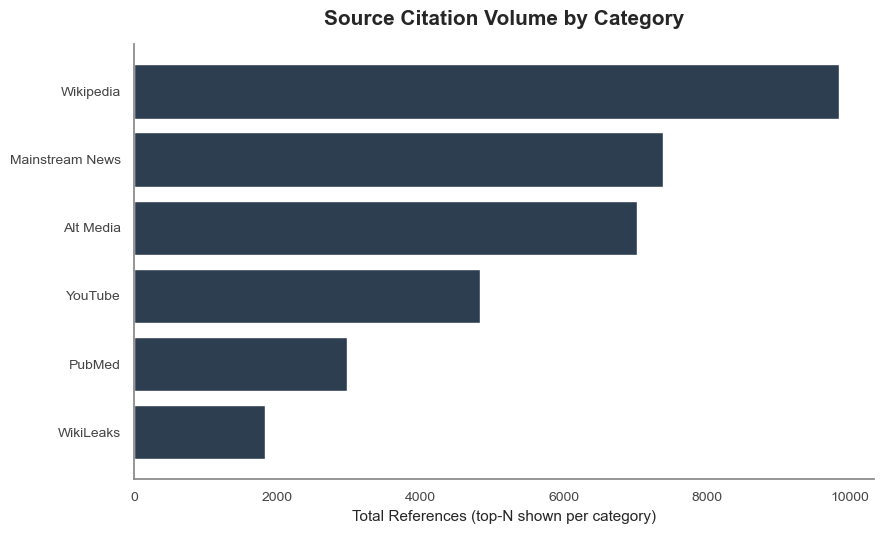

In [39]:
# Total reference/citation volume by source category (ties the 4.1
# subsections together at a glance -- each table above already has its
# own detail; this is just the relative scale).
_source_totals = {
    'Wikipedia': df_wiki['reference_count'].sum(),
    'PubMed': df_pubmed['reference_count'].sum(),
    'Mainstream News': df_news_articles['citations'].sum(),
    'Alt Media': df_alt_articles['citations'].sum(),
    'YouTube': df_youtube['citations'].sum(),
    'WikiLeaks': df_wikileaks['citations'].sum() if len(df_wikileaks) > 0 else 0,
}
viz.plot_source_category_totals(_source_totals)


> **Takeaway:** Among the top resolved items in each category here, Wikipedia is cited most, with mainstream news and alternative media in similar volume just behind it, then YouTube, then PubMed, then WikiLeaks smallest. Note this compares only the top ~15-30 *resolved* items per category (Section 4.1's tables), not full domain-level citation totals -- see Section 9.3 for the complete domain-level breakdown, where `social_video` and `mainstream_news` are the two largest categories overall.

---
## 5. Post-Level Analysis

Submission metadata from r_conspiracy_posts*.jsonl

In [40]:
# Domain performance at submission level
print(con.execute(f"""
    SELECT 
        domain,
        COUNT(*) as total_submissions,
        ROUND(AVG(score), 2) as avg_score,
        MAX(score) as top_score,
        ROUND(AVG(upvote_ratio), 3) as avg_upvote_ratio,
        ROUND(AVG(num_comments), 1) as avg_comments
    FROM read_json_auto('{RAW_POSTS}', union_by_name=true, ignore_errors=true)
    WHERE domain IS NOT NULL
    GROUP BY domain
    HAVING total_submissions > 500
    ORDER BY avg_score DESC
    LIMIT 40
""").df().to_string())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                        domain  total_submissions  avg_score  top_score  avg_upvote_ratio  avg_comments
0             files.catbox.moe                746     398.07      21310             0.759          90.9
1                  i.imgur.com              19167     268.15      36780             0.915          59.3
2                    i.redd.it             197111     206.08      76121             0.760          54.4
3               streamable.com               1727     197.07      26372             0.755          58.9
4    thefreethoughtproject.com               1901     160.33      12433             0.995          21.5
5                    v.redd.it                724     135.01      15069             0.839          35.9
6                inquisitr.com                609     126.28       4825             0.989          21.1
7                pbs.twimg.com                799     126.25       7137             0.931          34.6
8             yournewswire.com                918     117.04    

In [41]:
# All-time top posts
attp = cached_query_csv(con, BASE + "attp.csv", f"""
    SELECT title, domain, score, num_comments, upvote_ratio
    FROM read_json_auto('{RAW_POSTS}', union_by_name=true, ignore_errors=true)
    WHERE score > 1000
      AND title IS NOT NULL
    ORDER BY score DESC
    LIMIT 500
""")
print(attp.to_string())


Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/attp.csv


                                                                                                                                                                                                                                                                                                            title                     domain  score  num_comments  upvote_ratio
0                                                                                                          This rare image, featuring the victims of the mass slaughter of peaceful protesters by the Chinese army at Tiananmen Square, was just censored from the front page of reddit with 134,000 net upvotes.                  i.redd.it  76121          2923          1.00
1                                                                                                                                                                                                                                                                This wa

In [42]:
#checking range of post data

print(con.execute(f"""
    SELECT 
        MIN(TO_TIMESTAMP(created_utc)) as earliest,
        MAX(TO_TIMESTAMP(created_utc)) as latest
    FROM read_json_auto('{RAW_POSTS}', union_by_name=true, ignore_errors=true)
    WHERE created_utc IS NOT NULL
""").df().to_string())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

                   earliest                    latest
0 2008-01-30 03:02:37+13:00 2026-06-16 10:02:43+12:00


---
## 6. Master Thread Synthesis

Post metadata joined with aggregated comment-level lexical scores.  
888,846 threads. Enables analysis of post topic × comment epistemic style.

In [43]:
# Epistemic profile by source domain
display(con.execute(f"""
    SELECT 
        domain,
        COUNT(*) as threads,
        ROUND(AVG(post_score), 1) as avg_post_score,
        ROUND(AVG(avg_evidence_score), 3) as avg_evidence,
        ROUND(AVG(avg_rhetoric_score), 3) as avg_rhetoric,
        ROUND(AVG(avg_certainty_score), 3) as avg_certainty,
        ROUND(AVG(avg_authority_score), 3) as avg_authority,
        ROUND(AVG(avg_controversiality), 4) as avg_controversy
    FROM '{SYNTHESIS}'
    GROUP BY domain
    HAVING threads > 100
    ORDER BY avg_rhetoric DESC
    LIMIT 30
""").df())

,domain,threads,avg_post_score,avg_evidence,avg_rhetoric,avg_certainty,avg_authority,avg_controversy
0,tecchtecnical.blogspot.com,145,1.0,1.000,1.000,0.000,0.000,0.0000
1,minddebris.com,174,1.0,1.000,1.000,0.000,0.000,0.0000
2,wwefunda.com,119,1.0,1.000,1.000,0.000,0.000,0.0000
3,prosveshtenieto.com,159,1.0,1.000,1.000,0.000,0.000,0.0000
4,starlightinternational786.world,201,1.0,1.000,1.000,0.000,0.000,0.0000
5,a3lank.com,111,1.0,1.000,1.000,0.000,0.000,0.0000
6,rajacreator.com,2993,1.0,1.000,1.000,0.000,0.000,0.0000
7,collective-spark.xyz,512,1.0,0.996,0.998,0.000,0.001,0.0000
8,read.cash,121,1.0,0.975,0.982,0.000,0.000,0.0000
9,mynutriday.com,141,1.0,0.974,0.973,0.005,0.108,0.0000


In [44]:
# Most contested threads — high comments, high controversiality
display(con.execute(f"""
    SELECT 
        title,
        domain,
        post_score,
        total_comments,
        ROUND(avg_controversiality, 3) as avg_controversy,
        ROUND(avg_evidence_score, 3) as avg_evidence,
        ROUND(avg_rhetoric_score, 3) as avg_rhetoric,
        ROUND(total_comments::FLOAT / NULLIF(post_score, 0), 2) as comment_to_score_ratio
    FROM '{SYNTHESIS}'
    WHERE total_comments > 500
    ORDER BY avg_controversiality DESC
    LIMIT 20
""").df())

,title,domain,post_score,total_comments,avg_controversy,avg_evidence,avg_rhetoric,comment_to_score_ratio
0,Everything they wanted to inject into my baby his first year of life.,i.redd.it,0,644,0.295,0.169,0.314,NaN
1,Joe Rogan Experience #2219 - Donald Trump,youtu.be,1669,615,0.293,0.101,0.312,0.37
2,A conspiracy that has gone from online - real life. Undeniable now,i.redd.it,687,525,0.286,0.046,0.316,0.76
3,Matt Walsh's pro-reality film 'what is a woman' viewed over 60 million times on Twitter,imgur.com,949,774,0.279,0.110,0.324,0.82
4,Any thoughts on what’s happening here??,i.redd.it,4876,550,0.278,0.104,0.327,0.11
5,This is Joe Biden’s Campaign Strategy. Bankrupt Donald Trump. Arrest Donald Trump. We are a 3rd World Nation.,i.redd.it,386,529,0.259,0.064,0.312,1.37
6,Sandy Hook Game-Changer: Solid New Evidence of a Cover-Up Presented,21stcenturywire.com,784,519,0.254,0.158,0.412,0.66
7,This is just the start. Just the beginning of the experiment. Coming to a city near you,i.redd.it,2278,758,0.253,0.050,0.307,0.33
8,"""science""",i.redd.it,2192,589,0.246,0.256,0.374,0.27
9,Donald Trump becomes first US President to be convicted as a felon,i.redd.it,1885,577,0.243,0.055,0.302,0.31


---
## 7. Time Series

How do epistemic patterns shift over the subreddit's history?

In [45]:
# Lexical scores by year
df_yearly = con.execute(f"""
    SELECT
        YEAR(TO_TIMESTAMP(created_utc)) as year,
        COUNT(*) as n_comments,
        ROUND(AVG(hedge_count), 3) as avg_hedge,
        ROUND(AVG(certainty_count), 3) as avg_certainty,
        ROUND(AVG(evidence_count), 3) as avg_evidence,
        ROUND(AVG(authority_count), 3) as avg_authority,
        ROUND(AVG(rhetorical_count), 3) as avg_rhetorical
    FROM '{LEXICAL}'
    WHERE created_utc IS NOT NULL
    GROUP BY year
    ORDER BY year
""").df()
display(df_yearly)


,year,n_comments,avg_hedge,avg_certainty,avg_evidence,avg_authority,avg_rhetorical
0,2008,2224,0.187,0.063,0.227,0.177,0.373
1,2009,22591,0.202,0.060,0.276,0.183,0.382
2,2010,45985,0.183,0.055,0.261,0.160,0.361
3,2011,89355,0.172,0.053,0.247,0.153,0.345
4,2012,211408,0.180,0.054,0.235,0.129,0.339
5,2013,436677,0.177,0.056,0.221,0.150,0.341
6,2014,441327,0.174,0.055,0.236,0.139,0.342
7,2015,530331,0.168,0.059,0.245,0.136,0.347
8,2016,655094,0.175,0.057,0.205,0.123,0.324
9,2017,1681239,0.168,0.056,0.204,0.114,0.340


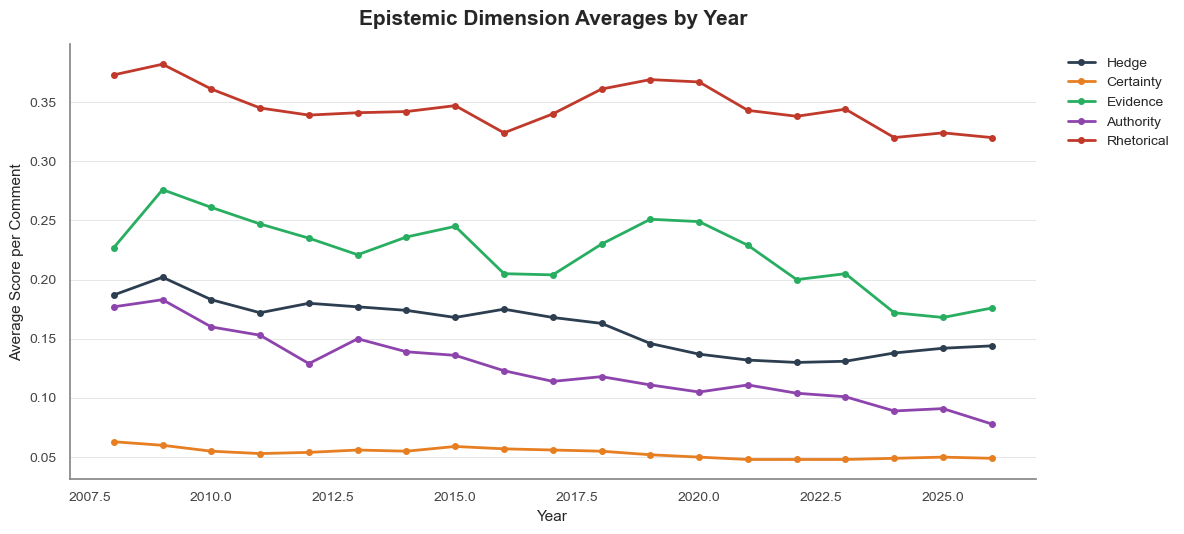

In [46]:
viz.plot_yearly_lexical_trends(df_yearly)


> **Takeaway:** Rhetorical and evidence-appeal language are the dominant, roughly stable dimensions across the corpus's history. Authority-appeal language has declined fairly steadily since ~2015; certainty language stays consistently the smallest dimension throughout. None of the five shows a sharp regime change -- shifts are gradual, not tied to a single event year.

---
## 8. Human-in-the-Loop Annotation

Active learning annotator: `python3 src/hitl_rater.py` (local HTTP server on port 8420).

Current labeling happens in `data/hitl/queue_*.csv` -- 4 active queues (`personal_experience`, `procedural_skepticism`, `maverick_authority`, `consensus_stance`), 3 of them fully labeled. `human_labels_active_learning.csv` (used by 8.0 below) was an early pilot on a different, now-superseded schema (`epistemic_moves` list + free-text stance) -- kept for reference, not where current annotation happens.

### 8.0 Early Pilot Queue (3 rows, superseded)

The cell below reads `human_labels_active_learning.csv` directly -- a 3-row pilot that predates the `data/hitl/queue_*.csv` system. Kept as-is for the schema it explored (`epistemic_moves` list x `human_stance`), not as a live dataset.

In [47]:
import ast

labels_df = pd.read_csv(LABELS)
labels_df['epistemic_moves'] = labels_df['epistemic_moves'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
)

exploded = labels_df.explode('epistemic_moves')

matrix = pd.crosstab(
    index=exploded['epistemic_moves'],
    columns=exploded['human_stance'],
    margins=True,
    margins_name='Total'
).sort_values('Total', ascending=False)

print(f"Total annotations: {len(labels_df)}")
print(f"Stance distribution:\n{labels_df['human_stance'].value_counts()}")
print(f"\nEpistemic move × stance matrix:")
print(matrix.to_string())

Total annotations: 3
Stance distribution:
human_stance
Anti-Conspiracy    2
Pro-Conspiracy     1
Name: count, dtype: int64

Epistemic move × stance matrix:
human_stance                    Anti-Conspiracy  Pro-Conspiracy  Total
epistemic_moves                                                       
Total                                         2               1      3
Mockery / Insult / Sarcasm                    1               1      2
Appeal to Logic / Common Sense                1               0      1


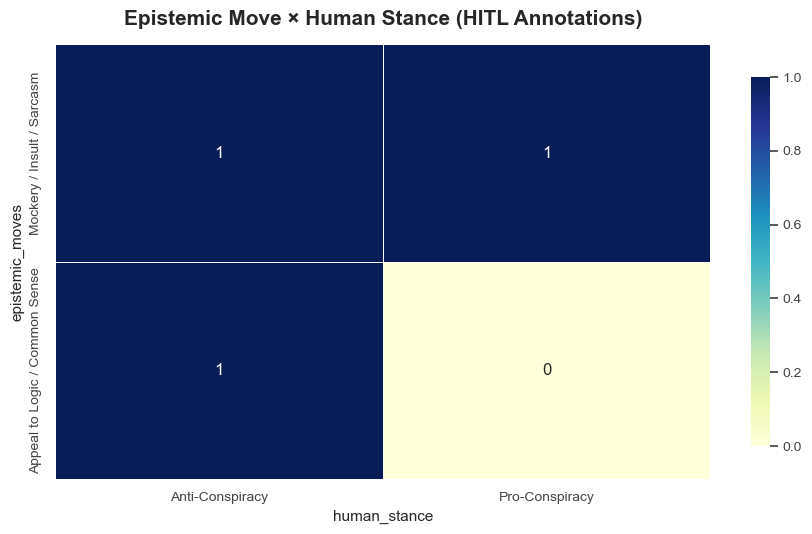

In [48]:
viz.plot_epistemic_stance_heatmap(matrix)


> **Note on sample size:** this crosstab is still very sparse (single-digit counts per cell) -- `human_labels_active_learning.csv` is an early active-learning queue, not yet at a size where cell-to-cell comparisons are meaningful. Useful for spotting labeling schema issues (e.g. an epistemic move that never co-occurs with a stance, which may indicate a rare category or a queue-construction gap), not yet for drawing conclusions about the relationship itself.

### 8.1 Current Queue Progress

The 4 active queues in `data/hitl/queue_*.csv`, rated via `src/hitl_rater.py`.

,queue,labeled,remaining,total
0,personal_experience,100,0,100
1,procedural_skepticism,100,0,100
2,maverick_authority,197,0,197
3,consensus_stance,152,88,240


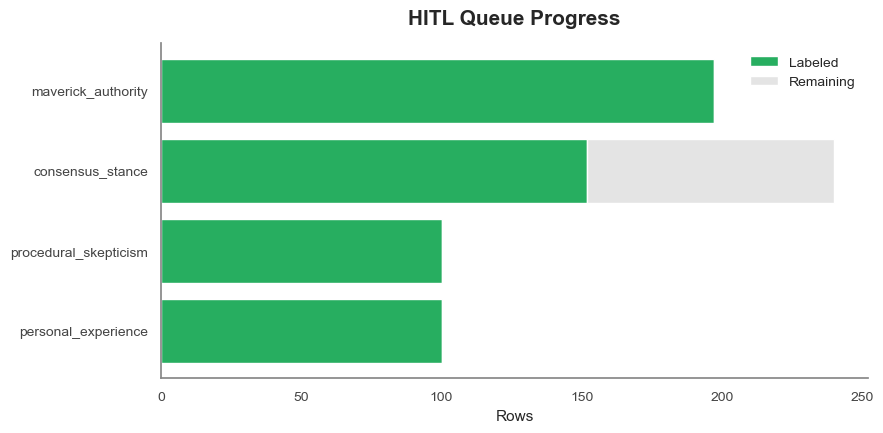

In [49]:
HITL_QUEUES = {
    'personal_experience': ('human_label', REPO_ROOT / 'data' / 'hitl' / 'queue_personal_experience.csv'),
    'procedural_skepticism': ('human_label', REPO_ROOT / 'data' / 'hitl' / 'queue_procedural_skepticism.csv'),
    'maverick_authority': ('human_label', REPO_ROOT / 'data' / 'hitl' / 'queue_maverick_authority.csv'),
    'consensus_stance': ('human_stance', REPO_ROOT / 'data' / 'hitl' / 'queue_consensus_stance.csv'),
}

progress_rows = []
for queue_name, (label_col, path) in HITL_QUEUES.items():
    df_q = pd.read_csv(path)
    labeled = df_q[label_col].notna().sum()
    progress_rows.append({'queue': queue_name, 'labeled': labeled, 'remaining': len(df_q) - labeled, 'total': len(df_q)})

df_hitl_progress = pd.DataFrame(progress_rows)
display(df_hitl_progress)
viz.plot_hitl_queue_progress(df_hitl_progress)


### 8.2 Label Distributions (Completed Queues)

`personal_experience`, `procedural_skepticism`, and `maverick_authority` are fully labeled and share the same 4-way label vocabulary (`positive` / `lean_positive` / `negative` / `unsure`), so their distributions are directly comparable. `consensus_stance` uses a different vocabulary (endorsement/hostile/neutral/ambiguous) and is only 63% complete -- shown separately, not merged into this comparison.

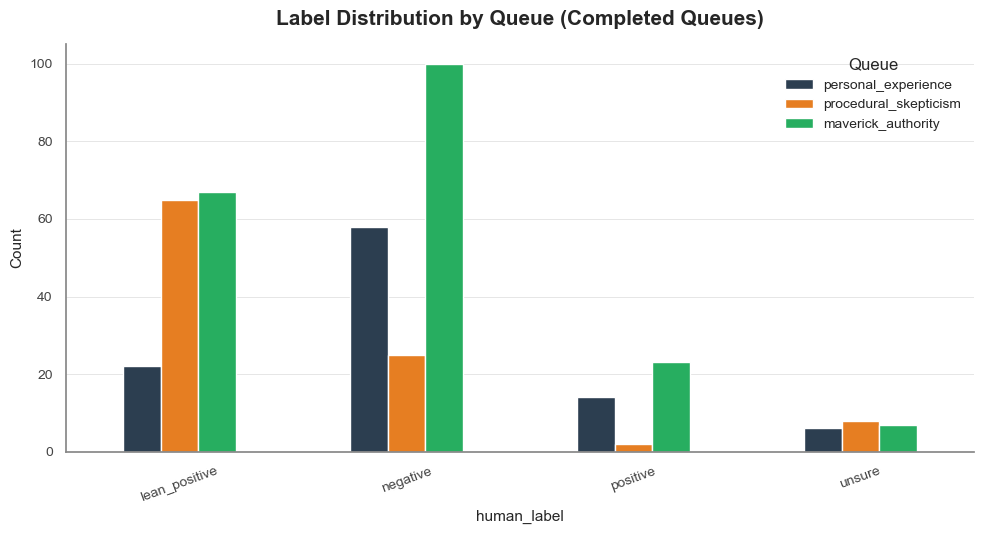

=== consensus_stance (in progress, 152/240) ===
human_stance
hostile        99
NaN            88
endorsement    30
ambiguous      12
neutral        11


In [50]:
COMPLETE_QUEUES = ['personal_experience', 'procedural_skepticism', 'maverick_authority']
dist_by_queue = {}
for queue_name in COMPLETE_QUEUES:
    label_col, path = HITL_QUEUES[queue_name]
    df_q = pd.read_csv(path)
    dist_by_queue[queue_name] = df_q[label_col].value_counts()

viz.plot_hitl_label_distributions(dist_by_queue)

print("=== consensus_stance (in progress, 152/240) ===")
_, consensus_path = HITL_QUEUES['consensus_stance']
df_consensus = pd.read_csv(consensus_path)
print(df_consensus['human_stance'].value_counts(dropna=False).to_string())


> **Takeaway:** All three completed queues skew negative/lean-positive rather than strongly positive -- raters rarely call a comment a clean "positive" hit for personal-experience, procedural-skepticism, or maverick-authority framing; the more common judgment call is negative or a qualified "lean". `consensus_stance` (still in progress) already shows hostile framing (99) outnumbering endorsement (30) roughly 3:1 among comments mentioning a consensus expert -- consistent with the coefficient-interpretation question already flagged in `ANTIGRAVITY_HANDOFF.md` (does citing a consensus expert predict engagement because people cite them approvingly, or because people cite them to attack them?).

---
## 9. Extended Analyses & Method Development

Everything below builds on the validated pipeline (Sections 0–8). Cells are grouped by method family. **Outputs already on disk** — re-run a pipeline cell only if you need to regenerate its file.

**Reading order:** 9.1 lexicon → 9.2 topics → 9.3 domains → 9.4 attribution deep dive → 9.5–9.6 tier/insider profiles → 9.7 cross-post demographics → 9.8 lexical convergence → 9.9 strategy vs upvotes → 9.10 full-corpus scale-up → 9.11–9.12 spam/bot detection.


### 9.1 Extended Lexical Scoring (11 dimensions)

Replaced Empath's `analyse()` with DuckDB `LIKE` patterns over the externalized lexicon (`epistemic_lexicon.py`). The production run writes `empath_scores_full.parquet`. Subsequent cells validate distributions, extract exemplars, and check category correlations.

**Note:** If the lexicon import reports 0 categories, restore `epistemic_lexicon.py` from `ConspiracyMaster_Archive.ipynb` (the Gemini cleanup truncated it to `lex = {}`).

In [51]:
# Load the externalized lexicon dictionary
try:
    from utils.epistemic_lexicon import lex
    categories = list(lex.keys())
    print(f"Loaded {len(categories)} categories from external lexicon file.")
except ImportError:
    print("Lexicon file not found. Make sure epistemic_lexicon.py is in the same directory.")

Loaded 11 categories from external lexicon file.


In [52]:
# One-time pipeline — reads LEXICAL parquet, writes empath_scores_full.parquet
import time
import os

SAMPLE_ONLY = False
OUTPUT_FILE = EMPATH

if os.path.exists(OUTPUT_FILE):
    print(f"Skipping pipeline: {OUTPUT_FILE} already exists on disk.")
else:
    print("Building bulletproof SIMD string search query...")

    # 1. Build the SQL addition statements dynamically
    category_columns = []
    for cat, words in lex.items():
        term_checks = []
        for word in words:
            # Sanitize the dictionary word (replace hyphens with spaces to match our cleaned text)
            clean_word = word.replace('-', ' ').replace("'", "''").lower()
            # Create a CONTAINS check. ::INT converts True to 1 and False to 0 so we can sum them.
            term_checks.append(f"contains(clean_text, ' {clean_word} ')::INT")
            
        # Join them with + to sum the counts for this category
        cat_sum_sql = " + \n            ".join(term_checks)
        category_columns.append(f"({cat_sum_sql}) as {cat}_count")

    category_sql = ",\n        ".join(category_columns)

    if SAMPLE_ONLY:
        input_sql = f"(SELECT * FROM '{LEXICAL}' USING SAMPLE 2000)"
    else:
        input_sql = f"'{LEXICAL}'"

    # 2. The Query: Clean, Pad, and Sum
    query = f"""
        WITH cleaned_data AS (
            SELECT 
                id,
                author,
                upvotes,
                controversiality,
                parent_id,
                link_id,
                created_utc,
                char_length,
                CASE WHEN text LIKE '%http%' THEN 1 ELSE 0 END as has_link,
                text,
                -- Strip punctuation, replace with space, and pad the ends with spaces
                ' ' || regexp_replace(lower(text), '[^a-z0-9]', ' ', 'g') || ' ' as clean_text
            FROM {input_sql}
            WHERE text IS NOT NULL
        )
        SELECT 
            id,
            author,
            upvotes,
            controversiality,
            parent_id,
            link_id,
            created_utc,
            char_length,
            has_link,
            text,
            {category_sql}
        FROM cleaned_data
    """

    print(f"Running {'SAMPLE' if SAMPLE_ONLY else 'FULL'} scoring using clean-text padding...")
    start = time.time()

    if SAMPLE_ONLY:
        df_scored = con.execute(query).df()
        elapsed = time.time() - start
        print(f"Done in {elapsed:.1f}s — {len(df_scored):,} comments")
        display(df_scored[[c for c in df_scored.columns if c.endswith('_count')]].describe())
    else:
        # Stream directly from Parquet to Parquet
        con.execute(f"COPY ({query}) TO '{OUTPUT_FILE}' (FORMAT PARQUET, COMPRESSION 'zstd')")
        elapsed = (time.time() - start) / 60
        print(f"Done in {elapsed:.1f} minutes — saved 11 dimensions to {OUTPUT_FILE}")


Skipping pipeline: /Users/nash/Projects/ConspiracyComments/data/processed/empath_scores_full.parquet already exists on disk.


In [53]:
# Point this to your completed 11-dimension parquet file
print("Analyzing Macro Patterns (11 Dimensions)...")

# 1. Calculate the raw baseline prevalence of each category across the entire corpus
macro_query = f"""
    SELECT 
        ROUND(AVG(evidence_count), 4) as avg_evidence,
        ROUND(AVG(adversarial_count), 4) as avg_adversarial,
        ROUND(AVG(hedge_count), 4) as avg_hedge,
        ROUND(AVG(certainty_count), 4) as avg_certainty,
        ROUND(AVG(alt_authority_count), 4) as avg_alt_authority,
        ROUND(AVG(intuitive_count), 4) as avg_intuitive,
        ROUND(AVG(pattern_count), 4) as avg_pattern,
        ROUND(AVG(meta_count), 4) as avg_meta,
        ROUND(AVG(demand_count), 4) as avg_demand,
        ROUND(AVG(anecdotal_count), 4) as avg_anecdotal,
        ROUND(AVG(quantitative_count), 4) as avg_quantitative
    FROM '{EMPATH}'
"""
df_macro = duckdb.query(macro_query).df()
print("\n--- Average Mentions Per Comment (Corpus-Wide) ---")
display(df_macro.T.sort_values(by=0, ascending=False))

# 2. Isolate comments by their primary move to evaluate upvotes and controversiality metrics
controversy_query = f"""
    SELECT 
        CASE 
            WHEN demand_count > 0 THEN '1. Demands Proof'
            WHEN quantitative_count > 0 THEN '2. Cites Stats/Data'
            WHEN evidence_count > 0 THEN '3. Cites Evidence/Docs'
            WHEN alt_authority_count > 0 THEN '4. Cites Alt-Authority'
            WHEN meta_count > 0 THEN '5. Meta-Debate / Logic'
            WHEN anecdotal_count > 0 THEN '6. Uses Lived Experience'
            WHEN pattern_count > 0 THEN '7. Pattern Recognition'
            WHEN intuitive_count > 0 THEN '8. Uses Intuition'
            WHEN adversarial_count > 0 THEN '9. Adversarial / Rhetoric'
            WHEN hedge_count > 0 THEN '10. Hedging / Tentative'
            WHEN certainty_count > 0 THEN '11. Certitude / Bravado'
            ELSE '12. General / No Key Move'
        END as primary_move,
        COUNT(*) as total_comments,
        ROUND(AVG(controversiality), 4) as avg_controversy,
        ROUND(AVG(upvotes), 2) as avg_upvotes
    FROM '{EMPATH}'
    GROUP BY primary_move
    ORDER BY avg_controversy DESC
"""
df_controversy = duckdb.query(controversy_query).df()
print("\n--- Engagement & Controversiality by Primary Move ---")
display(df_controversy)

Analyzing Macro Patterns (11 Dimensions)...



--- Average Mentions Per Comment (Corpus-Wide) ---


,0
avg_hedge,0.1946
avg_adversarial,0.0991
avg_evidence,0.0734
avg_anecdotal,0.0505
avg_quantitative,0.0396
avg_pattern,0.0320
avg_alt_authority,0.0202
avg_intuitive,0.0184
avg_certainty,0.0123
avg_meta,0.0106



--- Engagement & Controversiality by Primary Move ---


,primary_move,total_comments,avg_controversy,avg_upvotes
0,9. Adversarial / Rhetoric,1303087,0.1135,5.28
1,11. Certitude / Bravado,109429,0.1009,4.51
2,5. Meta-Debate / Logic,126952,0.0984,3.65
3,1. Demands Proof,192782,0.0953,4.18
4,4. Cites Alt-Authority,287418,0.0911,6.70
5,8. Uses Intuition,239808,0.0890,4.02
6,2. Cites Stats/Data,712762,0.0837,4.75
7,12. General / No Key Move,13770223,0.0763,5.06
8,7. Pattern Recognition,473556,0.0743,5.74
9,3. Cites Evidence/Docs,1146700,0.0743,4.95


In [54]:
EXPORT_PATH = BASE + 'top_30_per_category.csv'

categories = [
    'evidence', 'adversarial', 'hedge', 'certainty', 'alt_authority', 
    'intuitive', 'pattern', 'meta', 'demand', 'anecdotal', 'quantitative'
]

all_tops = []
if os.path.exists(EXPORT_PATH):
    df_all_tops = pd.read_csv(EXPORT_PATH)


else:
    print("Extracting top 30 comments for all 11 categories...")
    
    for cat in categories:
        query = f"""
            SELECT 
                '{cat}' as category,
                id,
                author,
                upvotes,
                controversiality,
                char_length,
                {cat}_count as word_count,
                ROUND(({cat}_count::FLOAT / (char_length + 1)) * 100, 2) as density_score,
                text
            FROM '{EMPATH}'
            WHERE {cat}_count > 0 AND char_length > 100
            ORDER BY word_count DESC, density_score DESC
            LIMIT 30
        """
        df_cat = duckdb.query(query).df()
        all_tops.append(df_cat)
    
    # Combine into a single master dataframe and export
    df_all_tops = pd.concat(all_tops, ignore_index=True)
    df_all_tops.to_csv(EXPORT_PATH, index=False)
    print(f"Done. Saved master list to: {EXPORT_PATH}")

# --- QUICK IN-NOTEBOOK VIEWER ---
# Change this variable to any category name to inspect its top comments inside Jupyter
view_category = 'anecdotal' 

pd.set_option('display.max_colwidth', 300)
print(f"\n--- Previewing Top Comments for Category: '{view_category}' ---")
display(df_all_tops[df_all_tops['category'] == view_category][['word_count', 'upvotes', 'text']].head(5))


--- Previewing Top Comments for Category: 'anecdotal' ---


,word_count,upvotes,text
270,7,2.0,"Again, not trying to offer this as proof, just stating my experience:\nThe streets are very full at that time of day. As planes hit and I looked up, I was gasping with dozens of people around me in every immediate direction. With both hits, some people screamed,others said,""what just happened?"" ..."
271,7,3.0,"Since this is reddit so I don't know if this counts. this is my personal experience (so it's highly subjective). \n\nFirst of all, I want to say that COVID is *actually real*. It's not a hoax. It's not a Conspiracy. It's not just another flu. It's real. I have seen some healthy people drained to..."
272,7,1.0,"People are glued to the idea of the daily grind. Social media allows people to form hives of what they call friends. People to stave off the feeling of loneliness, to belong really.\n\nI've realized just how easily led astray people are due to such simple things like pornography or social habits..."
273,7,3.0,"> I would love to know more about ur experience with mkuktra.\n\nSo, to clarify, I was not part of mkultra since it ended dozens of years before I was born. With that said, mkultra has spiritual successors in other programs that are largely undocumented. The mkultra project is part of a very lon..."
274,7,1.0,"Hey, you also seem like a reasonable person, so let me offer you my perspective on this. I don't think we will agree on much of this to be honest (this is just my gut feeling), but that is alright. I'm always open to both offering my perspective to others as well as listening to other people's v..."


In [55]:
print("Extracting score distributions for validation...")
query = f"""
    SELECT 
        evidence_count, adversarial_count, hedge_count, certainty_count, 
        alt_authority_count, intuitive_count, pattern_count, meta_count, 
        demand_count, anecdotal_count, quantitative_count
    FROM '{EMPATH}'
"""
df_counts = duckdb.query(query).df()

# Calculate the correlation matrix
corr = df_counts.corr(method='pearson')

print("\n--- Category Correlation Matrix ---")
pd.set_option('display.float_format', lambda x: '%.3f' % x)
display(corr)

Extracting score distributions for validation...



--- Category Correlation Matrix ---


,evidence_count,adversarial_count,hedge_count,certainty_count,alt_authority_count,intuitive_count,pattern_count,meta_count,demand_count,anecdotal_count,quantitative_count
evidence_count,1.000,0.055,0.077,0.055,0.109,0.032,0.056,0.034,0.085,0.026,0.121
adversarial_count,0.055,1.000,0.060,0.045,0.056,0.040,0.054,0.033,0.030,0.029,0.034
hedge_count,0.077,0.060,1.000,0.041,0.050,0.057,0.078,0.026,0.033,0.091,0.068
certainty_count,0.055,0.045,0.041,1.000,0.027,0.035,0.023,0.023,0.038,0.017,0.028
alt_authority_count,0.109,0.056,0.050,0.027,1.000,0.009,0.046,0.007,0.028,0.014,0.016
intuitive_count,0.032,0.040,0.057,0.035,0.009,1.000,0.025,0.121,0.029,0.024,0.031
pattern_count,0.056,0.054,0.078,0.023,0.046,0.025,1.000,0.008,0.015,0.038,0.031
meta_count,0.034,0.033,0.026,0.023,0.007,0.121,0.008,1.000,0.026,0.009,0.017
demand_count,0.085,0.030,0.033,0.038,0.028,0.029,0.015,0.026,1.000,0.011,0.019
anecdotal_count,0.026,0.029,0.091,0.017,0.014,0.024,0.038,0.009,0.011,1.000,0.034


---
### 9.2 BERTopic on High-Upvote Comments

Fit on comments with ≥50 upvotes to discover semantic topic clusters. Topic 13 was selected as the "epistemic credibility" cluster via embedding search. **Expensive** — model saved to `bertopic_model/`.

In [56]:
print("Analyzing upvote distribution across the full corpus...")

# 1. Get specific percentile cutoffs
percentile_query = f"""
    SELECT 
        COUNT(*) as total_valid_comments,
        MIN(upvotes) as min_score,
        APPROX_QUANTILE(upvotes, 0.50) as p50_median,
        APPROX_QUANTILE(upvotes, 0.75) as p75,
        APPROX_QUANTILE(upvotes, 0.90) as p90,
        APPROX_QUANTILE(upvotes, 0.95) as p95,
        APPROX_QUANTILE(upvotes, 0.99) as p99,
        MAX(upvotes) as max_score
    FROM '{EMPATH}'
    WHERE text IS NOT NULL 
      AND text != '[deleted]' 
      AND text != '[removed]'
"""

df_percentiles = duckdb.query(percentile_query).df()
print("\n--- Upvote Percentile Thresholds ---")
display(df_percentiles)

# 2. Get exact row counts at specific upvote minimums
count_query = f"""
    SELECT 
        SUM(CASE WHEN upvotes >= 2 THEN 1 ELSE 0 END) as remaining_gte_2,
        SUM(CASE WHEN upvotes >= 5 THEN 1 ELSE 0 END) as remaining_gte_5,
        SUM(CASE WHEN upvotes >= 10 THEN 1 ELSE 0 END) as remaining_gte_10,
        SUM(CASE WHEN upvotes >= 25 THEN 1 ELSE 0 END) as remaining_gte_25,
        SUM(CASE WHEN upvotes >= 50 THEN 1 ELSE 0 END) as remaining_gte_50,
        SUM(CASE WHEN upvotes >= 100 THEN 1 ELSE 0 END) as remaining_gte_100
    FROM '{EMPATH}'
    WHERE text IS NOT NULL 
      AND text != '[deleted]' 
      AND text != '[removed]'
"""

df_counts = duckdb.query(count_query).df()
print("\n--- Comment Counts Remaining per Cutoff ---")
display(df_counts.T)

Analyzing upvote distribution across the full corpus...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


--- Upvote Percentile Thresholds ---


,total_valid_comments,min_score,p50_median,p75,p90,p95,p99,max_score
0,21408577,-1305.000,1.129,4.000,9.954,18.532,65.593,7364.000


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


--- Comment Counts Remaining per Cutoff ---


,0
remaining_gte_2,10574447.000
remaining_gte_5,4796206.000
remaining_gte_10,2284489.000
remaining_gte_25,752258.000
remaining_gte_50,305721.000
remaining_gte_100,118102.000


In [57]:
import os
import pandas as pd
from sentence_transformers import SentenceTransformer
from umap import UMAP
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

# Define your cache paths (adjust the folder path to match your BASE directory if needed)
MODEL_CACHE = BASE + 'bertopic_model' 
DF_CACHE = BASE + 'high_upvote_with_topics.parquet'

# STEP 1: Check if the cache exists
if os.path.exists(MODEL_CACHE) and os.path.exists(DF_CACHE):
    print("Loading cached BERTopic model and scored dataframe from disk...")
    topic_model = BERTopic.load(MODEL_CACHE)
    df_high_upvote = pd.read_parquet(DF_CACHE)
    
    print(f"Loaded {len(df_high_upvote):,} high-signal comments.")
    print("\n--- Global High-Upvote Topics Discovered (From Cache) ---")
    display(topic_model.get_topic_info().head(25))

# STEP 2: If cache is missing, run the heavy computation
else:
    print("Cache not found. Running heavy BERTopic computation...")
    
    # Maintain single-threaded safety for Apple Silicon
    os.environ["OMP_NUM_THREADS"] = "1"
    os.environ["TOKENIZERS_PARALLELISM"] = "false"

    query = f"""
        SELECT 
            id, text, upvotes, controversiality, evidence_count, adversarial_count,
            hedge_count, certainty_count, alt_authority_count, intuitive_count,
            pattern_count, meta_count, demand_count, anecdotal_count, quantitative_count
        FROM '{EMPATH}'
        WHERE upvotes >= 100
          AND text IS NOT NULL 
          AND char_length BETWEEN 100 AND 1000
          AND lower(author) NOT LIKE '%moderator%'
          AND text NOT LIKE '%###[Meta] Sticky Comment%'
          AND text NOT LIKE '%submission statement%'
          AND text NOT LIKE '%Your post has been removed%'
          AND text != '[deleted]' 
          AND text != '[removed]'
    """

    df_high_upvote = duckdb.query(query).df()
    docs = df_high_upvote['text'].dropna().tolist()
    print(f"Loaded {len(docs):,} high-signal comments for global topic modeling.")

    print("Generating sentence embeddings...")
    embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
    embeddings = embedding_model.encode(docs, show_progress_bar=True)

    print("Reducing dimensions with UMAP...")
    umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

    print("Optimizing word extraction...")
    vectorizer_model = CountVectorizer(stop_words="english", min_df=5)

    print("Training global BERTopic model...")
    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        vectorizer_model=vectorizer_model,
        min_topic_size=100, 
        calculate_probabilities=False,
        verbose=True
    )

    topics, _ = topic_model.fit_transform(docs, embeddings)
    df_high_upvote['assigned_topic'] = topics

    # STEP 3: Save the cache so you never have to run this again
    print("Saving model and dataframe to cache...")
    topic_model.save(MODEL_CACHE)
    df_high_upvote.to_parquet(DF_CACHE)

    print("\n--- Global High-Upvote Topics Discovered ---")
    display(topic_model.get_topic_info().head(25))

Loading cached BERTopic model and scored dataframe from disk...


Loaded 112,775 high-signal comments.

--- Global High-Upvote Topics Discovered (From Cache) ---


,Topic,Count,Name,Representation,Representative_Docs
0,-1,59704,-1_people_like_just_don,"[people, like, just, don, https, think, time, know, com, trump]",[Honestly this whole Video is just sad. A bunch of dumb fucking kids going out in the streets of their own country and playing fucking civil war GI Joe. I’m not talking about anyone specific and yes I think Kyle is innocent here after watching that. \n\nBut the whole thing is sad and embarrassin...
1,0,3762,0_vaccine_vaccinated_vaccines_covid,"[vaccine, vaccinated, vaccines, covid, unvaccinated, heart, jab, vaccination, shot, people]","[The thing I don’t understand is why only the unvaccinated need to be tested? Vaccinated people can get covid too, the vaccine doesn’t stop infection, it only limits serious illness. Vaccinated people should be tested too to ensure we aren’t passing it to non-vaccinated., The vaccine is so dur..."
2,1,3500,1_gun_police_shooting_guns,"[gun, police, shooting, guns, shooter, cops, shot, cop, suicide, vegas]","[""Right here you got yer rear window rifle, in here is your console gun, over there is the glove box gun, down here is the door gun, under the seat gun, boot gun, holster gun right here in my hip, armpit holster gun, toolbox gun, and those are just the ones I'm willing to tell you about..."
3,2,3068,2_woman_hillary_like_just,"[woman, hillary, like, just, husband, did, dead, think, com, lady]","[And what about Virginia - the most vocal of victims is hit by a bus in a car, says she has four days to live - goes on to live four weeks then dies by suicide? After having tweeted I think in 2019 that she is making it clear she was not suicidal and that people want her quieted? Granted she has..."
4,3,2368,3_israel_iran_israeli_jews,"[israel, iran, israeli, jews, jewish, gaza, netanyahu, palestine, zionist, anti]","[Also, Israel has wanted the US to destroy Iran for decades. Looks like the US will be Israel's bully once again., Israel needs to be taken down, this is more then obvious. I know that people say that Iran does this and that, but comeone, it is not our thing what are they doing there. Israel is ..."
5,4,2068,4_epstein_maxwell_jeffrey_files,"[epstein, maxwell, jeffrey, files, ghislaine, trump, island, blackmail, mossad, https]",[And that network is supported/encouraged by the government as part of a decades-long international intelligence operation for blackmail and control.\n\n[Part 1: Hidden in Plain Sight: The Shocking Origins of the Jeffrey Epstein Case](https://www.mintpressnews.com/shocking-origins-jeffrey-epstei...
6,5,1956,5_plane_building_11_towers,"[plane, building, 11, towers, buildings, pentagon, planes, wtc, collapse, flight]","[Conspiracy or not, you have to admit it's extremely convenient that the day after 2 trillion dollars is said to be missing from the Pentagon ledgers, the evidence to possibly find out where that money went gets destroyed.\n\nAlso, where the hell were the plane parts? The supposed plane that hit..."
7,6,1829,6_conspiracy_conspiracies_sub_theories,"[conspiracy, conspiracies, sub, theories, theory, post, subreddit, theorists, political, theorist]","[The biggest conspiracy theory of them all, is that people now believe the truth is a conspiracy theory., Conspiracy theory is just a theory about a conspiracy. A conspiracy is just some people who get together (in secret) to make a plan to do something. A conspiracy theory is just people tryin..."
8,7,1803,7_russia_ukraine_russian_putin,"[russia, ukraine, russian, putin, nato, war, russians, ukrainian, propaganda, trump]","[What is the Ukrainian propaganda exactly? Is Russia not bombing the shit out of the Ukraine right now?, >Understanding this does not make you pro russia).\n\nIt's funny how post feb 2022 everybody saying Ukraine is full of criminals is labeled as pro Russia.\n\nUkraine always has been one of t..."
9,8,1281,8_covid_virus_pandemic_flu,"[covid, virus, pandemic, flu, deaths, coronavirus, 19, people, 2020, death]","[Yeah, I know people that after

In [58]:
target_topic = 13

# Retrieve the documents BERTopic identified as most central to this topic
representative_docs = topic_model.get_representative_docs(target_topic)

print(f"--- Most Representative Docs for Topic {target_topic} ---")
for idx, doc in enumerate(representative_docs, 1):
    print(f"[{idx}] {doc}")
    print("=" * 50)

--- Most Representative Docs for Topic 13 ---
[1] A bunch of states changed their rules in 2020 and sent everyone mail in ballots without them requesting. States went back to how it was and people had to request ballots. You get a bunch more people to vote if you mail them a ballot and then send a ballot harvester to their house a few days later who tells them to fill it out right there. 

Trump would have probably won 2020 if it was not for covid. It doesn't mean there was fraud or anything but it was the worst environment for an incumbent you could imagine.
[2] Weird. Every single one of these spikes lines up exactly with each time Trump publicly spouted his bullshit theories about fraudulent mail-in ballots even though mail-in historically is less susceptible to fraud than in-person. Plus the face that there have only been 1200 cases of voter fraud in the past 20 years. 

It's almost as if he's been signposting that he wouldn't accept the result of the election unless he won for the

In [59]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Choose the topic ID you want to inspect (e.g., 13 for media propaganda, 1 for vaccines)
target_topic = 13
top_n_docs = 15

# 1. Isolate the comments belonging to the target topic (CHANGED df_sample to df_high_upvote)
df_target = df_high_upvote[df_high_upvote['assigned_topic'] == target_topic].copy()

# Catch empty topics
if len(df_target) == 0:
    print(f"No comments found for Topic {target_topic}. Check if the ID is correct.")
else:
    target_docs = df_target['text'].dropna().tolist()

    print(f"Total comments in Topic {target_topic}: {len(target_docs)}")
    print("Calculating semantic distances to the cluster center...")

    # 2. Generate embeddings for just this topic's documents
    # (embedding_model is already in memory from the previous BERTopic cell)
    embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
    doc_embeddings = embedding_model.encode(target_docs)

    # 3. Compute the centroid (mean vector) of the cluster
    cluster_centroid = np.mean(doc_embeddings, axis=0).reshape(1, -1)

    # 4. Calculate the cosine similarity of each document to the centroid
    similarities = cosine_similarity(doc_embeddings, cluster_centroid).flatten()
    df_target['similarity_to_center'] = similarities

    # 5. Sort by highest similarity to get the most central documents
    df_representative = df_target.sort_values(by='similarity_to_center', ascending=False)

    # 6. Display the results clearly
    print(f"\n--- Top {top_n_docs} Most Representative Comments for Topic {target_topic} ---")
    for idx, row in enumerate(df_representative.head(top_n_docs).itertuples(), 1):
        print(f"[{idx}] Similarity Score: {row.similarity_to_center:.3f} | Upvotes: {row.upvotes}")
        print(row.text)
        print("=" * 60)

Total comments in Topic 13: 955
Calculating semantic distances to the cluster center...



--- Top 15 Most Representative Comments for Topic 13 ---
[1] Similarity Score: 0.743 | Upvotes: 308.0
If you've ever taken a stats class you know how unlikely it is that so many states show massive discrepancies between the reported vote totals and the exit polls.  This is almost certainly widespread election fraud.
[2] Similarity Score: 0.731 | Upvotes: 131.0
Vividly. Didn’t they lie and say there was a water pipe that busted to force everyone out? And then wasn’t there video capturing EVERYTHING they did including running ballots through multiple times? 

And then we still have to listen to to people that say there’s absolutely no evidence of fraud as they attempt to silence and censor others just for speaking about what they’ve witnessed?
[3] Similarity Score: 0.729 | Upvotes: 126.0
The president and the USPS post master conspiring to delay ballots so they can't be counted is kind of unconstitutional too lol

Trump has also admitted there is no evidence of fraud. 

This is a coup a

---
### 9.3 Source Domain Taxonomy

Classifies cited domains into epistemic types (institutional, alternative, social proof, etc.) and aggregates citation counts with engagement metrics.

In [60]:
# Pull top domains from comments with upvote and controversy data
domain_query = f"""
    WITH urls AS (
        SELECT
            id, upvotes, controversiality,
            UNNEST(regexp_extract_all(text, 'https?://[^\\s)\\]]+')) AS url
        FROM '{LEXICAL}'
        WHERE text LIKE '%http%'
    ),
    domains AS (
        SELECT
            id, upvotes, controversiality,
            regexp_extract(url, 'https?://(?:www[.])?([^/\\s]+)') AS domain
        FROM urls
    )
    SELECT
        domain,
        COUNT(*) as citations,
        COUNT(DISTINCT id) as unique_comments,
        ROUND(AVG(upvotes), 2) as avg_upvotes,
        ROUND(MEDIAN(upvotes), 2) as median_upvotes,
        ROUND(AVG(controversiality), 3) as avg_controversy
    FROM domains
    WHERE domain != ''
      AND length(domain) > 3
      AND domain NOT LIKE '%reddit%'
      AND domain NOT LIKE '%redd.it%'
    GROUP BY domain
    HAVING citations > 100
    ORDER BY citations DESC
    LIMIT 200
"""
df_domains = cached_query_csv(con, BASE + 'domains.csv', domain_query)
print(f"Domains to classify: {len(df_domains)}")
display(df_domains.head(20))


Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/domains.csv
Domains to classify: 200


,domain,citations,unique_comments,avg_upvotes,median_upvotes,avg_controversy
0,https://www.youtube.com,245849,158502,5.540,2.000,0.065
1,https://en.wikipedia.org,153453,101099,5.920,2.000,0.062
2,https://youtu.be,149249,108728,5.510,2.000,0.068
3,https://twitter.com,58882,41644,8.870,2.000,0.131
4,https://archive.is,58856,49655,5.270,1.000,0.050
5,https://i.imgur.com,48922,27549,6.440,1.000,0.077
6,https://en.m.wikipedia.org,41263,31899,6.220,2.000,0.061
7,https://www.google.com,38439,32327,5.040,2.000,0.064
8,http://en.wikipedia.org,32504,24249,4.840,2.000,0.028
9,http://www.youtube.com,32101,22198,3.920,2.000,0.025


In [61]:
# Epistemic domain taxonomy
taxonomy = {
    # Mainstream institutional news
    'mainstream_news': [
        'nytimes.com', 'washingtonpost.com', 'theguardian.com', 'reuters.com',
        'bbc.com', 'bbc.co.uk', 'cnn.com', 'nbcnews.com', 'cbsnews.com',
        'abcnews.go.com', 'npr.org', 'bloomberg.com', 'newsweek.com',
        'time.com', 'theatlantic.com', 'politico.com', 'thehill.com',
        'apnews.com', 'forbes.com', 'businessinsider.com', 'cnbc.com',
        'huffingtonpost.com', 'huffpost.com', 'usatoday.com', 'wsj.com',
        'latimes.com', 'independent.co.uk', 'telegraph.co.uk',
        'dailymail.co.uk', 'nypost.com', 'nydailynews.com', 'rollingstone.com'
    ],
    
    # Alternative / conspiracy-adjacent media
    'alt_media': [
        'zerohedge.com', 'infowars.com', 'breitbart.com', 'rt.com',
        'globalresearch.ca', 'activistpost.com', 'beforeitsnews.com',
        'naturalnews.com', 'thefreethoughtproject.com', 'thedailysheeple.com',
        'mintpressnews.com', 'corbettreport.com', 'theintercept.com',
        'greenwald.substack.com', 'rumble.com', 'bitchute.com',
        'collective-evolution.com', 'humansarefree.com', 'yournewswire.com',
        'theepochtimes.com', 'thegatewayпунdit.com', 'thegatewaypundit.com',
        'childrenshealthdefense.org', 'mercola.com', 'lewrockwell.com',
        'prisonplanet.com', 'whatreallyhappened.com', 'veteranstoday.com'
    ],
    
    # Academic and scientific
    'academic_scientific': [
        'ncbi.nlm.nih.gov', 'pubmed.ncbi.nlm.nih.gov', 'nature.com',
        'sciencedirect.com', 'springer.com', 'journals.plos.org',
        'academic.oup.com', 'jamanetwork.com', 'nejm.org', 'thelancet.com',
        'bmj.com', 'annals.org', 'cell.com', 'science.org',
        'researchgate.net', 'academia.edu', 'jstor.org', 'scholar.google.com',
        'biorxiv.org', 'medrxiv.org', 'tandfonline.com', 'wiley.com'
    ],
    
    # Government and official institutions  
    'government_official': [
        'cdc.gov', 'nih.gov', 'fda.gov', 'who.int', 'fbi.gov', 'cia.gov',
        'state.gov', 'whitehouse.gov', 'congress.gov', 'senate.gov',
        'house.gov', 'justice.gov', 'doj.gov', 'nsa.gov', 'nasa.gov',
        'epa.gov', 'usda.gov', 'defense.gov', 'treasury.gov',
        'federalreserve.gov', 'sec.gov', 'ftc.gov', 'un.org', 'nato.int'
    ],
    
    # Archive and preservation — censorship-aware sourcing
    'archive_preservation': [
        'archive.is', 'archive.org', 'web.archive.org', 'archive.ph',
        'archive.fo', 'reveddit.com', 'removeddit.com', 'ceddit.com',
        'ghostarchive.org', 'timeoutinternet.com'
    ],
    
    # Leaked documents and whistleblower sources
    'leak_whistleblower': [
        'wikileaks.org', 'wikileaks.com', 'cryptome.org', 'dcleaks.com',
        'theintercept.com', 'documentcloud.org', 'cia.gov',
        'foia.state.gov', 'vault.fbi.gov', 'muckrock.com',
        'judicialwatch.org', 'governmentattic.org'
    ],
    
    # Legal documents and court records
    'legal_documents': [
        'documentcloud.org', 'courtlistener.com', 'pacer.gov',
        'law.cornell.edu', 'supremecourt.gov', 'findlaw.com',
        'justia.com', 'scribd.com'
    ],
    
    # Social media and video
    'social_video': [
        'youtube.com', 'youtu.be', 'm.youtube.com', 'twitter.com',
        'x.com', 'mobile.twitter.com', 'facebook.com', 'm.facebook.com',
        'instagram.com', 'tiktok.com', 'vm.tiktok.com', 'twitch.tv',
        'odysee.com', 'bitchute.com', 'rumble.com', 'dailymotion.com',
        'vimeo.com', 'streamable.com'
    ],
    
    # Reference and encyclopaedic
    'reference': [
        'en.wikipedia.org', 'en.m.wikipedia.org', 'wikipedia.org',
        'britannica.com', 'investopedia.com', 'merriam-webster.com'
    ],
    
    # Image hosting — often screenshots
    'image_screenshot': [
        'i.imgur.com', 'imgur.com', 'i.redd.it', 'pbs.twimg.com',
        'i.postimg.cc', 'files.catbox.moe', 'ibb.co', 'prnt.sc',
        'postimg.cc', 'gyazo.com'
    ]
}

# Build reverse lookup
domain_to_type = {}
for etype, domains in taxonomy.items():
    for d in domains:
        domain_to_type[d] = etype

# Apply classification
def classify_domain(domain):
    # Strip www. and https:// if present
    clean = domain.replace('https://', '').replace('http://', '').replace('www.', '').strip('/')
    if clean in domain_to_type:
        return domain_to_type[clean]
    # Fuzzy fallbacks
    if any(x in clean for x in ['.gov', '.mil']):
        return 'government_official'
    if any(x in clean for x in ['substack', 'wordpress', 'blogspot', 'medium.com']):
        return 'blog_independent'
    if any(x in clean for x in ['university', 'edu', 'ac.uk', 'ac.nz']):
        return 'academic_scientific'
    return 'other'

df_domains['epistemic_type'] = df_domains['domain'].apply(classify_domain)

print("\nDomain type distribution:")
print(df_domains['epistemic_type'].value_counts())


Domain type distribution:
epistemic_type
other                   79
mainstream_news         48
social_video            16
academic_scientific     13
archive_preservation     8
image_screenshot         8
government_official      8
alt_media                8
reference                5
leak_whistleblower       3
legal_documents          3
blog_independent         1
Name: count, dtype: int64


In [62]:
# Aggregate by epistemic type
type_summary = df_domains.groupby('epistemic_type').agg(
    total_citations=('citations', 'sum'),
    unique_domains=('domain', 'count'),
    avg_upvotes=('avg_upvotes', 'mean'),
    median_upvotes=('median_upvotes', 'mean'),
    avg_controversy=('avg_controversy', 'mean')
).round(3).sort_values('avg_upvotes', ascending=False).reset_index()

print("\n--- Epistemic Type Performance ---")
display(type_summary)

# Also show top 5 domains within each type
print("\n--- Top Domains by Type ---")
for etype in df_domains['epistemic_type'].unique():
    subset = df_domains[df_domains['epistemic_type'] == etype].nlargest(5, 'avg_upvotes')
    print(f"\n{etype.upper()}")
    display(subset[['domain', 'citations', 'avg_upvotes', 'avg_controversy']].head(5))


--- Epistemic Type Performance ---


,epistemic_type,total_citations,unique_domains,avg_upvotes,median_upvotes,avg_controversy
0,leak_whistleblower,14850,3,9.727,2.333,0.058
1,archive_preservation,151895,8,7.621,2.000,0.068
2,image_screenshot,118854,8,7.594,1.875,0.094
3,alt_media,19341,8,7.330,2.375,0.083
4,mainstream_news,318014,48,6.986,1.979,0.077
5,legal_documents,6849,3,6.940,2.333,0.090
6,blog_independent,4897,1,6.330,2.000,0.061
7,government_official,44044,8,5.961,1.875,0.080
8,social_video,572569,16,5.899,1.812,0.073
9,other,261256,79,5.726,1.772,0.070



--- Top Domains by Type ---

SOCIAL_VIDEO


,domain,citations,avg_upvotes,avg_controversy
56,https://streamable.com,6057,9.660,0.183
3,https://twitter.com,58882,8.870,0.131
30,https://x.com,10507,7.630,0.113
155,https://vimeo.com,2013,6.970,0.050
36,https://mobile.twitter.com,8847,6.900,0.094



REFERENCE


...

,domain,citations,avg_upvotes,avg_controversy
65,https://medium.com,4897,6.330,0.061



ALT_MEDIA


,domain,citations,avg_upvotes,avg_controversy
102,https://www.mintpressnews.com,3143,18.230,0.038
90,https://www.corbettreport.com,3601,9.300,0.048
150,https://www.rt.com,2090,6.970,0.064
171,https://www.zerohedge.com,1761,5.480,0.170
168,https://childrenshealthdefense.org,1825,5.400,0.082



LEGAL_DOCUMENTS


,domain,citations,avg_upvotes,avg_controversy
137,https://www.documentcloud.org,2291,10.010,0.086
115,https://www.scribd.com,2803,5.800,0.111
172,https://www.law.cornell.edu,1755,5.010,0.072


In [63]:
# Patch the taxonomy with domains from 'other'
additional_taxonomy = {
    'mainstream_news': [
        'foxnews.com', 'msn.com', 'vox.com', 'thedailybeast.com',
        'pbs.org', 'cbc.ca', 'news.yahoo.com', 'yahoo.com',
        'wired.com', 'vice.com', 'aljazeera.com', 'edition.cnn.com',
        'salon.com', 'vanityfair.com', 'thesun.co.uk', 'usnews.com',
        'washingtontimes.com', 'washingtonexaminer.com', 'jpost.com',
        'timesofisrael.com', 'haaretz.com', 'theconversation.com',
        'theverge.com', 'livescience.com', 'news.bbc.co.uk',
        'scientificamerican.com', 'sciencedaily.com', 'healthline.com',
        'webmd.com', 'history.com', 'metabunk.org'
    ],
    
    'academic_scientific': [
        'statista.com', 'ourworldindata.org', 'pewresearch.org',
        'worldometers.info', 'opensecrets.org'
    ],
    
    'archive_preservation': [
        'archive.vn', 'reveddit.com', 'removeddit.com',
        'archive.4plebs.org', 'reminddit.com'
    ],
    
    'government_official': [
        'c-span.org', 'patents.google.com'
    ],
    
    'alt_media': [
        'off-guardian.org', 'whale.to', 'steemit.com', 'voat.co',
        'saidit.net', 'therabbithole.wiki', '911research.wtc7.net',
        'mileswmathis.com'
    ],
    
    'leak_whistleblower': [
        'judicialwatch.org', 'documentcloud.org'
    ],
    
    'legal_documents': [
        'courtlistener.com', 'scribd.com'
    ],
    
    'social_video': [
        't.me', 't.co', 'pastebin.com'
    ],
    
    'reference': [
        'upload.wikimedia.org', 'books.google.com', 'quora.com',
        'snopes.com', 'politifact.com', 'biblegateway.com',
        'biblehub.com', 'imdb.com', 'britannica.com'
    ],
    
    'fact_check': [
        'snopes.com', 'politifact.com', 'factcheck.org',
        'metabunk.org'
    ],
    
    'image_screenshot': [
        'i.pinimg.com', 'images.app.goo.gl'
    ],
    
    'search_utility': [
        'google.com', 'duckduckgo.com', 'wolframalpha.com',
        'drive.google.com', 'docs.google.com', 'icloud.com',
        'socpub.com', 'snewd.com', 'amazon.com'
    ],
    
    'blog_independent': [
        'substack.com', 'medium.com', 'wordpress.com', 'blogspot.com'
    ],
    
    'wef_globalist': [
        'weforum.org'
    ]
}

# Rebuild reverse lookup with patches
domain_to_type = {}
for etype, domains in taxonomy.items():
    for d in domains:
        domain_to_type[d] = etype

for etype, domains in additional_taxonomy.items():
    for d in domains:
        domain_to_type[d] = etype

# Reapply classification
def classify_domain(domain):
    clean = domain.replace('https://', '').replace('http://', '').replace('www.', '').strip('/')
    if clean in domain_to_type:
        return domain_to_type[clean]
    if any(x in clean for x in ['.gov', '.mil']):
        return 'government_official'
    if any(x in clean for x in ['substack', 'wordpress', 'blogspot']):
        return 'blog_independent'
    if any(x in clean for x in ['university', '.edu', 'ac.uk', 'ac.nz']):
        return 'academic_scientific'
    if 'http:' == clean:
        return 'malformed'
    return 'other'

df_domains['epistemic_type'] = df_domains['domain'].apply(classify_domain)

print("Updated distribution:")
print(df_domains['epistemic_type'].value_counts())

# Check remaining 'other'
remaining = df_domains[df_domains['epistemic_type'] == 'other']
print(f"\nStill unclassified: {len(remaining)}")
display(remaining[['domain', 'citations', 'avg_upvotes']].head(20))

Updated distribution:
epistemic_type
mainstream_news         80
social_video            19
academic_scientific     18
alt_media               17
reference               11
archive_preservation    11
search_utility          11
image_screenshot        10
government_official     10
leak_whistleblower       4
fact_check               3
legal_documents          2
other                    1
wef_globalist            1
blog_independent         1
malformed                1
Name: count, dtype: int64

Still unclassified: 1


,domain,citations,avg_upvotes
41,https://github.com,7911,2.560


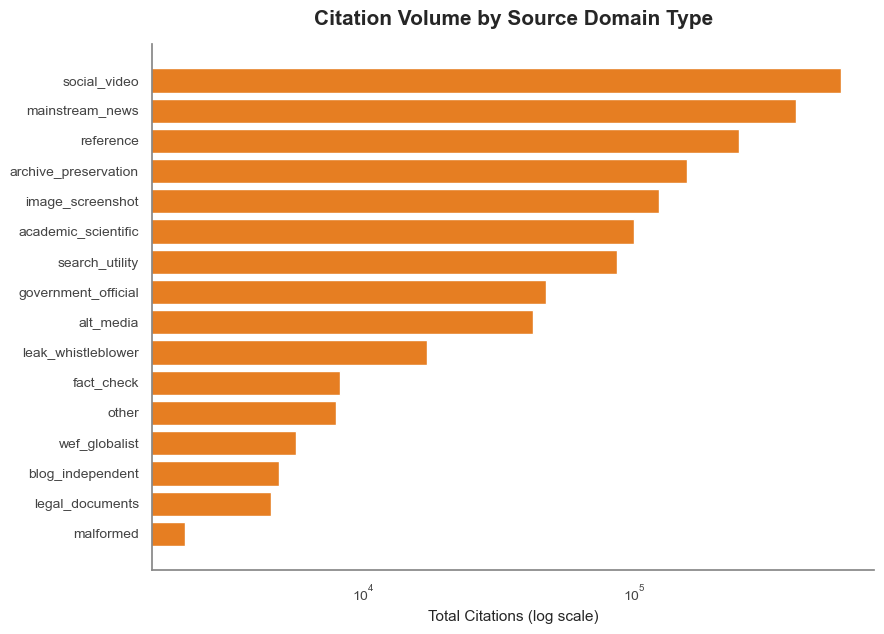

In [64]:
# Recompute the summary using the PATCHED classification (cell above) --
# the earlier type_summary (before this patch) still has the inflated 'other' bucket.
type_summary = df_domains.groupby('epistemic_type').agg(
    total_citations=('citations', 'sum'),
    unique_domains=('domain', 'count'),
    avg_upvotes=('avg_upvotes', 'mean'),
    median_upvotes=('median_upvotes', 'mean'),
    avg_controversy=('avg_controversy', 'mean')
).round(3).sort_values('avg_upvotes', ascending=False).reset_index()
viz.plot_domain_type_citations(type_summary)


> **Takeaway:** After the taxonomy patch above, only 1 domain remains unclassified as `other` (down from 79 under the base `taxonomy` dict alone -- see the patch cell's own printed "Still unclassified" check). `social_video` (YouTube, Twitter, etc.) and `mainstream_news` dominate total citation volume, each roughly double the next-largest category (`reference`, i.e. Wikipedia).

---
### 9.4 spaCy Attribution Deep Dive

Inspects how specific entities (e.g. "The Clintons") appear in attribution constructions within the 614k filtered comments.

> **Caveat:** unlike Section 3's `validated_spacy_type` (gated by the FactAppeal classifier), the cells below query `{SPACY}` -- the raw spaCy `attribution_class` typology -- directly, with no FactAppeal validation applied. Per the methodology note in Section 3, this classifier has known reliability issues on raw Reddit text. Treat this section's entity-specific pairs as qualitative/exploratory illustrations, not confirmed attribution findings.


In [65]:
print("Extracting and aggregating cited individuals from attribution layers...")
attribution_query = f"""
    SELECT
        text,
        upvotes,
        controversiality,
        attribution_class
    FROM '{SPACY}'
    WHERE attribution_class IN ('Direct_Quote:Named', 'Indirect_Quote:Named_Official', 'Indirect_Quote:Named_Expert')
"""
df_attributed = cached_query_csv(con, BASE + 'attributed.csv', attribution_query)
print(f"Loaded {len(df_attributed):,} instances of structured human attribution.")

# Aggregate performance by the correct column name
attr_summary = df_attributed.groupby('attribution_class').agg(
    count=('text', 'count'),
    avg_upvotes=('upvotes', 'mean'),
    avg_controversy=('controversiality', 'mean')
).round(3)

print("\n--- Attribution Class Performance ---")
display(attr_summary)


Extracting and aggregating cited individuals from attribution layers...
Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/attributed.csv


Loaded 275,500 instances of structured human attribution.

--- Attribution Class Performance ---


,count,avg_upvotes,avg_controversy
attribution_class,,,
Direct_Quote:Named,134889,6.296,0.084
Indirect_Quote:Named_Expert,1269,3.948,0.074
Indirect_Quote:Named_Official,139342,5.034,0.074


In [66]:
# Choose an entity to inspect: 'Jeffrey Epstein', 'The Clintons', 'Donald Trump', 'Anthony Fauci', 'Seth Rich'
inspect_entity = 'The Clintons'

query_text_pairs = f"""
    WITH parent_entities AS (
        SELECT
            id AS parent_id, text AS parent_text, upvotes AS parent_upvotes
        FROM '{SPACY}'
        WHERE attribution_class IN ('Direct_Quote:Named', 'Indirect_Quote:Named_Official', 'Indirect_Quote:Named_Expert')
          AND (text LIKE '%Hillary%' OR text LIKE '%Clinton%')
    ),
    child_replies AS (
        SELECT
            p.parent_text, p.parent_upvotes,
            c.text AS child_text, c.upvotes AS child_upvotes
        FROM parent_entities p
        JOIN '{LEXICAL}' c ON REGEXP_REPLACE(c.parent_id, '^t[13]_', '') = p.parent_id
        WHERE c.text NOT LIKE '%###[Meta]%'
        ORDER BY p.parent_upvotes DESC
        LIMIT 5
    )
    SELECT * FROM child_replies
"""
df_pairs = cached_query_csv(con, BASE + "pairs.csv", query_text_pairs)

print(f"\n--- Reading Parent-Child Dialogue Matrix for: {inspect_entity} ---")
for idx, row in enumerate(df_pairs.itertuples(), 1):
    print(f"\n[PAIR {idx}]")
    print(f"PARENT QUOTE (Upvotes: {row.parent_upvotes}):\n{row.parent_text}")
    print(f"\nCHILD REPLY (Upvotes: {row.child_upvotes}):\n{row.child_text}")
    print("=" * 70)


Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/pairs.csv

--- Reading Parent-Child Dialogue Matrix for: The Clintons ---

[PAIR 1]
PARENT QUOTE (Upvotes: 1229.0):
I have a conspiracy! I believe that Clinton and Trump have been in on this whole thing together from day one. Especially after Stormy Daniels said that while she was with him he took a phone call with Hilary to talk about the plan. I think both sides are rigged to keep the same system in place to keep the elite in power(including Trump and Clinton, the reps and the dems) and you guys are all being set against each other to divide and conquer. Mainstream media is just a tool used by both Trump and the Dems to keep actual progressives from putting the real power back into the hands of the people. I have always thought the whole thing was rigged and Trump is just there to appease the conspiracy nuts and keep them on side too. So it won't matter who gets in, America will always be fucked. Althou

---
### 9.5 Upvote-Tier Signatures & Brigading Detection

Compares epistemic dimension averages across upvote tiers to detect structural shifts that might indicate brigading or outsider interference.

In [67]:
# Path to your master text files on disk
print("Checking master archive row count and upvote schema...")

if os.path.exists(BASE + "diag.csv"):
    df_diag = pd.read_csv(BASE + "diag.csv")
else:
        
    
    diagnostic_query = f"""
        SELECT 
            COUNT(*) as total_rows,
            COUNT(CASE WHEN upvotes >= 50 THEN 1 END) as rows_above_50_upvotes,
            COUNT(CASE WHEN upvotes >= 100 THEN 1 END) as rows_above_100_upvotes
        FROM '{LEXICAL}'
    """
    
    df_diag = con.execute(diagnostic_query).df()
print("\n--- Master File Breakdown ---")
print(df_diag.to_string(index=False))

Checking master archive row count and upvote schema...



--- Master File Breakdown ---
 total_rows  rows_above_50_upvotes  rows_above_100_upvotes
   21408577                 305721                  118102


In [68]:
print("Analyzing epistemic signatures across upvote tiers to detect outsider interference...")

brigade_detection_query = f"""
    WITH categorized_corpus AS (
        SELECT
            id,
            upvotes,
            controversiality,
            -- Split the data into your precise upvote tiers
            CASE
                WHEN upvotes >= 10 AND upvotes < 50 THEN '1. Trench Tier (10-49 Upvotes)'
                WHEN upvotes >= 50 AND upvotes < 100 THEN '2. Intermediate Tier (50-99 Upvotes)'
                WHEN upvotes >= 100 THEN '3. Viral Tier (100+ Upvotes)'
            END AS upvote_tier,
            -- Check if the comment uses our explicit expertise vocabulary
            CASE
                WHEN regexp_matches(text, '(?i)\\b(expert|scientist|doctor|researcher|academia)\\b') THEN 1
                ELSE 0
            END as talks_about_expertise
        FROM '{LEXICAL}'
        WHERE upvotes >= 10
          AND text IS NOT NULL
          AND text != '[deleted]'
          AND text != '[removed]'
    )
    SELECT
        upvote_tier,
        COUNT(*) as total_comments,
        ROUND(AVG(controversiality), 4) as avg_controversiality,
        ROUND(AVG(talks_about_expertise) * 100, 2) as expertise_talk_percentage
    FROM categorized_corpus
    GROUP BY upvote_tier
    ORDER BY upvote_tier ASC
"""
df_brigade_test = cached_query_csv(con, BASE + "brigade_test.csv", brigade_detection_query)
print("\n--- Structural Signature Shifts Across Tiers ---")
print(df_brigade_test.to_string(index=False))


Analyzing epistemic signatures across upvote tiers to detect outsider interference...
Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/brigade_test.csv

--- Structural Signature Shifts Across Tiers ---
                         upvote_tier  total_comments  avg_controversiality  expertise_talk_percentage
      1. Trench Tier (10-49 Upvotes)         1978768                 0.023                      1.010
2. Intermediate Tier (50-99 Upvotes)          187619                 0.004                      1.040
        3. Viral Tier (100+ Upvotes)          118102                 0.001                      0.960


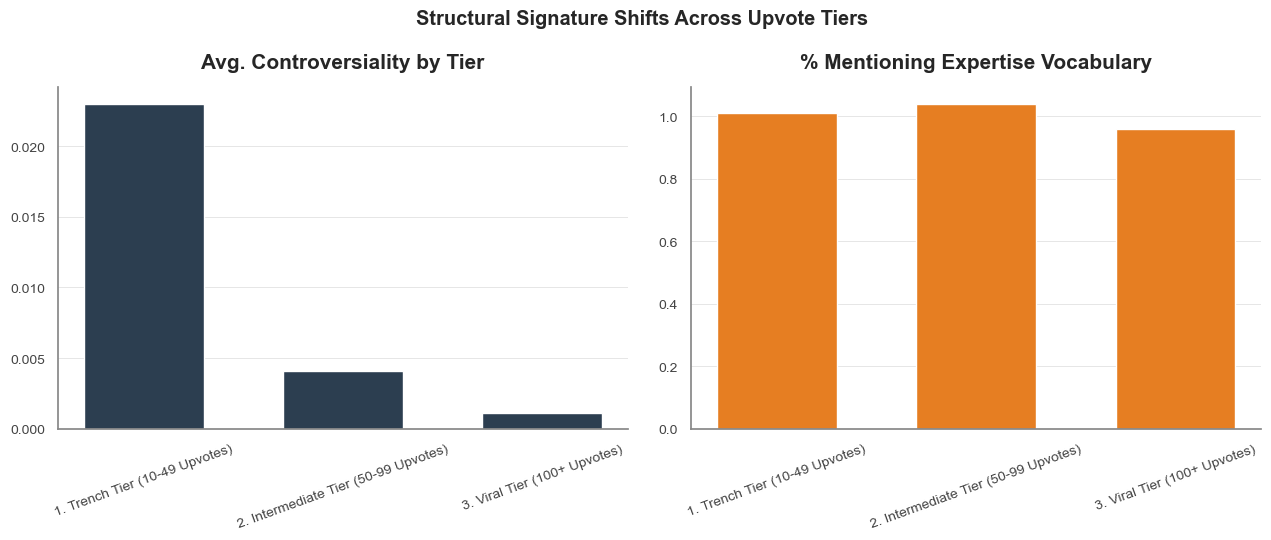

In [69]:
viz.plot_tier_signature_shifts(df_brigade_test)


> **Takeaway:** Controversiality drops sharply as upvotes increase -- the lowest tier (10-49 upvotes) is roughly 20x more controversial on average than the viral tier (100+) -- while use of explicit expertise vocabulary ("expert", "scientist", "researcher"...) stays flat around 1% regardless of tier. Controversiality tracks upvote tier far more than it tracks expertise-language framing.

In [70]:
# Fetch a single row to inspect all available metric columns
df_schema = con.execute(f"SELECT * FROM '{LEXICAL}' LIMIT 1").df()

print("=== Available Lexical, Structural, and Downstream Columns ===")
for col in df_schema.columns:
    print(f"- {col}")

=== Available Lexical, Structural, and Downstream Columns ===
- id
- author
- upvotes
- controversiality
- parent_id
- link_id
- created_utc
- char_length
- hedge_count
- certainty_count
- evidence_count
- authority_count
- rhetorical_count
- text


In [71]:
print("\n" + "="*80)
print("TYPOLOGY A: The Analytic-Investigative Slicing (High Hedge, High Evidence)")
print("="*80)



# Isolate texts where open-ended exploration (hedging) runs alongside data markers (evidence)
investigative_query = f"""
    SELECT upvotes, char_length, hedge_count, evidence_count, text
    FROM '{LEXICAL}'
    WHERE upvotes >= 10 AND upvotes < 50
      AND text IS NOT NULL AND text != '[deleted]' AND text != '[removed]'
      AND hedge_count > 3
      AND evidence_count > 3
    ORDER BY char_length DESC
    LIMIT 2
"""
df_investigative = con.execute(investigative_query).df()
for i, row in enumerate(df_investigative.itertuples(), 1):
    print(f"\n[Investigative Case {i}] Upvotes: {row.upvotes} | Hedge Count: {row.hedge_count} | Evidence Count: {row.evidence_count}")
    print(f"Text:\n{row.text.strip()}")
    print("." * 60)

print("\n" + "="*80)
print("TYPOLOGY B: The Dogmatic Narrative Defense (High Certainty, High Rhetorical)")
print("="*80)

# Isolate texts where absolute conviction (certainty) runs alongside persuasion framing (rhetorical)
defensive_query = f"""
    SELECT upvotes, char_length, certainty_count, rhetorical_count, text
    FROM '{LEXICAL}'
    WHERE upvotes >= 10 AND upvotes < 50
      AND text IS NOT NULL AND text != '[deleted]' AND text != '[removed]'
      AND certainty_count > 3
      AND rhetorical_count > 3
    ORDER BY upvotes DESC
    LIMIT 2
"""
df_defensive = con.execute(defensive_query).df()
for i, row in enumerate(df_defensive.itertuples(), 1):
    print(f"\n[Defensive Case {i}] Upvotes: {row.upvotes} | Certainty Count: {row.certainty_count} | Rhetorical Count: {row.rhetorical_count}")
    print(f"Text:\n{row.text.strip()}")
    print("." * 60)


TYPOLOGY A: The Analytic-Investigative Slicing (High Hedge, High Evidence)



[Investigative Case 1] Upvotes: 18.0 | Hedge Count: 5 | Evidence Count: 4
Text:
Awesome! I have been doing tons of research on QANON since last year and I wish I had some material prepared already to post but I'mma get my opinion out there with the time I have right now.  

So if you read Qanon's posts, from the beginning, the first thing he talks about is an impending arrest of Hillary Clinton, among other figures, part of a series of broader actions taken against a network of corruption and treason against the US government. Called "The Storm".  

Now, earlier in the month \(October 2017\) Trump made some mysterious comments to the press at the White House, saying “Do you know what this represents? I don’t know. Maybe it’s the calm before the storm. Could be the calm. The calm before the storm.”

Getting some clarification on what exactly those comments meant made the chans pretty excited, and even though the supposed day of Hillary’s arrest came and went without an arrest, Q was ba

---
### 9.6 Insider-Only Epistemic Profiles

Restricts to authors with ≥21 lifetime comments ("insiders") and profiles negative-score, long-tail, and controversiality bands separately.

In [72]:
print("Profiling the Long-Tail Native Tier (5 <= Upvotes < 50)...")

long_tail_query = f"""
    SELECT
        COUNT(*) as total_comments,
        ROUND(AVG(char_length), 1) as avg_length,
        ROUND(AVG(evidence_count), 4) as avg_evidence,
        ROUND(AVG(adversarial_count), 4) as avg_adversarial,
        ROUND(AVG(hedge_count), 4) as avg_hedge,
        ROUND(AVG(certainty_count), 4) as avg_certainty,
        ROUND(AVG(alt_authority_count), 4) as avg_alt_authority,
        ROUND(AVG(intuitive_count), 4) as avg_intuitive,
        ROUND(AVG(pattern_count), 4) as avg_pattern,
        ROUND(AVG(meta_count), 4) as avg_meta,
        ROUND(AVG(demand_count), 4) as avg_demand,
        ROUND(AVG(anecdotal_count), 4) as avg_anecdotal,
        ROUND(AVG(quantitative_count), 4) as avg_quantitative
    FROM '{EMPATH}'
    WHERE upvotes >= 5 AND upvotes < 50
      AND text IS NOT NULL
      AND text != '[deleted]'
      AND text != '[removed]'
"""
df_long_tail = cached_query_csv(con, BASE + "long_tail.csv", long_tail_query)
print("\n=== Long-Tail 11-Dimensional Profile ===")
print(df_long_tail.to_string(index=False))


Profiling the Long-Tail Native Tier (5 <= Upvotes < 50)...
Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/long_tail.csv

=== Long-Tail 11-Dimensional Profile ===
 total_comments  avg_length  avg_evidence  avg_adversarial  avg_hedge  avg_certainty  avg_alt_authority  avg_intuitive  avg_pattern  avg_meta  avg_demand  avg_anecdotal  avg_quantitative
        4490485     347.300         0.075            0.111      0.191          0.012              0.025          0.016        0.036     0.009       0.009          0.054             0.040


In [73]:
print("=== PART 1: NEGATIVE SUBSET PROFILE (Upvotes < 0) ===")

negative_profile_query = f"""
    SELECT
        COUNT(*) as total_comments,
        ROUND(AVG(char_length), 1) as avg_length,
        ROUND(AVG(evidence_count), 4) as avg_evidence,
        ROUND(AVG(adversarial_count), 4) as avg_adversarial,
        ROUND(AVG(hedge_count), 4) as avg_hedge,
        ROUND(AVG(certainty_count), 4) as avg_certainty,
        ROUND(AVG(alt_authority_count), 4) as avg_alt_authority,
        ROUND(AVG(intuitive_count), 4) as avg_intuitive,
        ROUND(AVG(pattern_count), 4) as avg_pattern,
        ROUND(AVG(meta_count), 4) as avg_meta,
        ROUND(AVG(demand_count), 4) as avg_demand,
        ROUND(AVG(anecdotal_count), 4) as avg_anecdotal,
        ROUND(AVG(quantitative_count), 4) as avg_quantitative
    FROM '{EMPATH}'
    WHERE upvotes < 0
      AND text IS NOT NULL
      AND text != '[deleted]'
      AND text != '[removed]'
"""
df_neg_profile = cached_query_csv(con, BASE + "neg_profile.csv", negative_profile_query)
print(df_neg_profile.to_string(index=False))


print("\n=== PART 2: TEXT EXAMPLES FROM THE LONG-TAIL TIER (5 <= Upvotes < 50) ===")
# Pulling comments with high pattern and evidence markers within the positive long-tail tier
pos_text_query = f"""
    SELECT upvotes, pattern_count, evidence_count, text
    FROM '{EMPATH}'
    WHERE upvotes >= 5 AND upvotes < 50
      AND text IS NOT NULL AND text != '[deleted]' AND text != '[removed]'
      AND pattern_count >= 1 AND evidence_count >= 1
    ORDER BY (pattern_count + evidence_count) DESC
    LIMIT 2
"""
df_pos_texts = cached_query_csv(con, BASE + "pos_texts.csv", pos_text_query)

for i, row in enumerate(df_pos_texts.itertuples(), 1):
    print(f"\n[Positive Case {i}] Upvotes: {row.upvotes} | Patterns: {row.pattern_count} | Evidence: {row.evidence_count}")
    print(f"Text:\n{row.text.strip()}")
    print("." * 60)


print("\n=== PART 3: TEXT EXAMPLES FROM THE REJECTED TIER (Upvotes < 0) ===")
# Pulling comments that maximize adversarial and certainty counts within the negative tier
neg_text_query = f"""
    SELECT upvotes, certainty_count, adversarial_count, text
    FROM '{EMPATH}'
    WHERE upvotes < 0
      AND text IS NOT NULL AND text != '[deleted]' AND text != '[removed]'
    ORDER BY (certainty_count + adversarial_count) DESC
    LIMIT 2
"""
df_neg_texts = cached_query_csv(con, BASE + "neg_texts.csv", neg_text_query)
for i, row in enumerate(df_neg_texts.itertuples(), 1):
    print(f"\n[Negative Case {i}] Upvotes: {row.upvotes} | Certainty: {row.certainty_count} | Adversarial: {row.adversarial_count}")
    print(f"Text:\n{row.text.strip()}")
    print("." * 60)


=== PART 1: NEGATIVE SUBSET PROFILE (Upvotes < 0) ===
Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/neg_profile.csv
 total_comments  avg_length  avg_evidence  avg_adversarial  avg_hedge  avg_certainty  avg_alt_authority  avg_intuitive  avg_pattern  avg_meta  avg_demand  avg_anecdotal  avg_quantitative
        1913929     324.900         0.068            0.129      0.171          0.015              0.020          0.021        0.027     0.014       0.012          0.041             0.041

=== PART 2: TEXT EXAMPLES FROM THE LONG-TAIL TIER (5 <= Upvotes < 50) ===
Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/pos_texts.csv

[Positive Case 1] Upvotes: 8.0 | Patterns: 2 | Evidence: 8
Text:
Brown University has removed a scientific article investigating rapid onset gender dysphoria due to some "expressing concerns that the conclusions of the study could be used to discredit efforts to support transgender youth and invalidat

In [74]:
print("Building the Insider-Only Epistemic Dataset (Author History >= 21)...")

# Relational sub-query to isolate verified insiders
insider_matrix_query = f"""
    WITH author_counts AS (
        SELECT author, COUNT(*) as total_global_comments
        FROM '{EMPATH}'
        WHERE author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
        GROUP BY author
    ),
    verified_insiders AS (
        SELECT m.*
        FROM '{EMPATH}' m
        JOIN author_counts ac ON m.author = ac.author
        WHERE ac.total_global_comments >= 21
          AND m.text IS NOT NULL
          AND m.text != '[deleted]'
          AND m.text != '[removed]'
    )
    SELECT
        CASE
            WHEN upvotes >= 5 AND upvotes < 50 THEN '1. Insider Trench (5-49 Upvotes)'
            WHEN upvotes BETWEEN 50 AND 100 AND controversiality >= 0.5 THEN '2. Insider Contested High (50-100 Up, Friction >= 0.5)'
            WHEN upvotes < 0 AND controversiality >= 0.5 THEN '3. Insider Organic Negatives (Downvoted, Friction >= 0.5)'
        END AS insider_segment,
        COUNT(*) as total_comments,
        ROUND(AVG(char_length), 1) as avg_length,
        ROUND(AVG(evidence_count), 4) as avg_evidence,
        ROUND(AVG(adversarial_count), 4) as avg_adversarial,
        ROUND(AVG(hedge_count), 4) as avg_hedge,
        ROUND(AVG(certainty_count), 4) as avg_certainty,
        ROUND(AVG(pattern_count), 4) as avg_pattern,
        ROUND(AVG(meta_count), 4) as avg_meta
    FROM verified_insiders
    WHERE
        (upvotes >= 5 AND upvotes < 50)
        OR (upvotes BETWEEN 50 AND 100 AND controversiality >= 0.5)
        OR (upvotes < 0 AND controversiality >= 0.5)
    GROUP BY insider_segment
    ORDER BY insider_segment ASC
"""
df_insider_matrix = cached_query_csv(con, BASE + "insider_matrix.csv", insider_matrix_query)

print("\n=== The Insider-Only Multi-Band Epistemic Profile ===")
print(df_insider_matrix.to_string(index=False))


Building the Insider-Only Epistemic Dataset (Author History >= 21)...
Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/insider_matrix.csv

=== The Insider-Only Multi-Band Epistemic Profile ===
                                          insider_segment  total_comments  avg_length  avg_evidence  avg_adversarial  avg_hedge  avg_certainty  avg_pattern  avg_meta
                         1. Insider Trench (5-49 Upvotes)         3816962     352.100         0.076            0.115      0.192          0.012        0.037     0.009
   2. Insider Contested High (50-100 Up, Friction >= 0.5)             665     437.000         0.096            0.182      0.158          0.012        0.039     0.017
3. Insider Organic Negatives (Downvoted, Friction >= 0.5)          467753     328.000         0.070            0.146      0.162          0.015        0.028     0.013


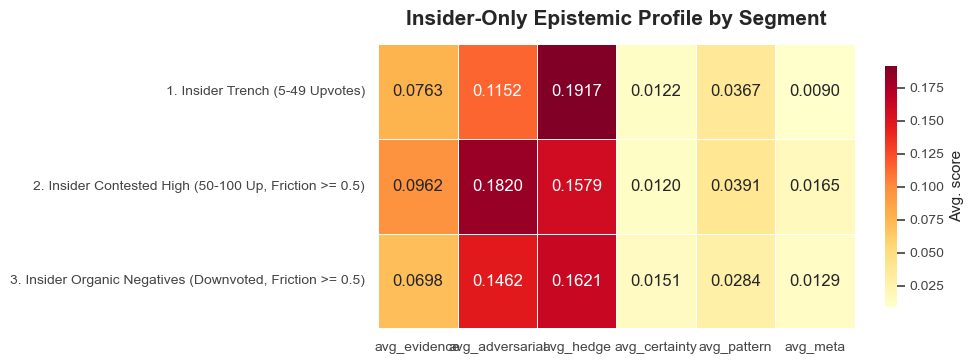

In [75]:
viz.plot_insider_segment_profile(df_insider_matrix)


> **Takeaway:** Hedge language dominates all three insider segments (~0.16-0.19 avg) over adversarial and evidence language. The "Contested High" segment (50-100 upvotes, controversiality ≥ 0.5) shows the highest adversarial score of the three -- consistent with insiders escalating combative language specifically in threads that are both contested *and* rewarded, rather than adversarial language being uniformly punished or ignored.

In [76]:
print("Calculating controversiality distributions across tiers...")

distribution_query = f"""
    WITH author_counts AS (
        SELECT author, COUNT(*) as total_global_comments
        FROM '{EMPATH}'
        WHERE author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
        GROUP BY author
    ),
    labeled_data AS (
        SELECT
            m.upvotes,
            m.controversiality,
            CASE
                WHEN m.upvotes >= 100 AND ac.total_global_comments = 1 THEN 'Known Upvote Brigade'
                WHEN m.upvotes <= -6 AND ac.total_global_comments >= 21 THEN 'Known Downvote Suppression'
                WHEN m.upvotes BETWEEN 5 AND 49 AND ac.total_global_comments >= 21 THEN 'Organic Insider Trench'
            END AS structural_cohort
        FROM '{EMPATH}' m
        JOIN author_counts ac ON m.author = ac.author
    )
    SELECT
        structural_cohort,
        COUNT(*) as sample_size,
        ROUND(AVG(controversiality), 4) as mean_controversiality,
        -- Use DuckDB's native QUANTILE function for percentile distributions
        ROUND(QUANTILE(controversiality, 0.50), 4) as p50_median,
        ROUND(QUANTILE(controversiality, 0.75), 4) as p75,
        ROUND(QUANTILE(controversiality, 0.90), 4) as p90
    FROM labeled_data
    WHERE structural_cohort IS NOT NULL
    GROUP BY structural_cohort
"""
df_dist = cached_query_csv(con, BASE + "dist.csv", distribution_query)
print("\n=== Controversiality Percentile Matrix ===")
print(df_dist.to_string(index=False))


Calculating controversiality distributions across tiers...
Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/dist.csv

=== Controversiality Percentile Matrix ===
         structural_cohort  sample_size  mean_controversiality  p50_median  p75  p90
      Known Upvote Brigade         2040                  0.000           0    0    0
Known Downvote Suppression       429138                  0.157           0    0    1
    Organic Insider Trench      3816962                  0.040           0    0    0


---
### 9.7 Cross-Post Audit & Thread Demographics

1. Stratified sample of 1,000 high-traction threads (`api_audit_sampling_1k.parquet`)
2. Arctic Shift API sweep for external cross-posts (`cross_post_audit_results.csv`)
3. Hour-by-hour insider/outsider ratio in breakout threads — tests whether viral threads attract tourists

**Note:** API sweep cells are archival; the CSV is complete.

In [77]:
POSTS_2 = str(REPO_ROOT / 'data' / 'raw' / 'r_conspiracy_posts2.jsonl.gz')

print("Extracting top breakout threads with high external footprints...")

breakout_query = f"""
    WITH combined_posts AS (
        SELECT id, title, num_comments, score, num_crossposts, upvote_ratio, permalink
        FROM read_json_auto('{RAW_POSTS}', maximum_object_size=50000000, union_by_name=True)
    )
    SELECT title, score, num_comments, num_crossposts, upvote_ratio, permalink
    FROM combined_posts
    WHERE num_comments > 1000
      AND num_crossposts >= 2
    ORDER BY num_comments DESC
    LIMIT 5
"""
df_breakouts = cached_query_csv(con, BASE + "breakouts.csv", breakout_query)

for i, row in enumerate(df_breakouts.itertuples(), 1):
    print(f"\n[{i}] {row.title}")
    print(f"    Score: {row.score} | Comments: {row.num_comments} | Crossposts: {row.num_crossposts} | Ratio: {row.upvote_ratio}")
    print(f"    Link: https://reddit.com{row.permalink}")


Extracting top breakout threads with high external footprints...
Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/breakouts.csv

[1] Sources: Jeffrey Epstein dies by suicide in Manhattan jail cell
    Score: 32373 | Comments: 5617 | Crossposts: 6 | Ratio: 1.0
    Link: https://reddit.com/r/conspiracy/comments/cohqc7/sources_jeffrey_epstein_dies_by_suicide_in/

[2] Breaking: FBI has raided Mar-A-Lago
    Score: 7484 | Comments: 5401 | Crossposts: 5 | Ratio: 0.7599999904632568
    Link: https://reddit.com/r/conspiracy/comments/wjn1nu/breaking_fbi_has_raided_maralago/

[3] No New Normal subreddit banned from Reddit
    Score: 9170 | Comments: 5399 | Crossposts: 4 | Ratio: 0.7699999809265137
    Link: https://reddit.com/r/conspiracy/comments/pfz4xc/no_new_normal_subreddit_banned_from_reddit/

[4] What the actual Fuck! This better not be true.
    Score: 3341 | Comments: 4805 | Crossposts: 2 | Ratio: 0.7300000190734863
    Link: https://reddit.com/r/conspira

In [78]:
import os
import time
import requests
import pandas as pd

print("Checking for cached Arctic Shift API data...")

CACHE_FILE = BASE + "cross_post_audit_results.csv"

if os.path.exists(CACHE_FILE):
    print("Loading cached cross-post data from disk...")
    df_crossposts = pd.read_csv(CACHE_FILE)
    display(df_crossposts)

else:
    print("Cache not found. Pinging Arctic Shift API...")
    BASE_URL = "https://arctic-shift.photon-reddit.com/api/posts/search"
    breakout_ids = ['cohqc7', 'wjn1nu', 'pfz4xc', 'pl57wj', 'ihsn1c']
    
    all_crossposts = []

    for post_id in breakout_ids:
        target_url = f"https://www.reddit.com/r/conspiracy/comments/{post_id}/"
        
        params = {
            "url": target_url,
            "url_exact": "false",
            "limit": 15,
            "fields": "subreddit,score,title,url,id"
        }
        
        headers = {
            "User-Agent": "AcademicDissertationContextAudit/1.0 (Massey University student project)"
        }
        
        try:
            response = requests.get(BASE_URL, params=params, headers=headers, timeout=15)
            remaining = response.headers.get("X-RateLimit-Remaining", "Unknown")
            
            if response.status_code == 200:
                root_json = response.json()
                post_list = root_json.get('data', [])
                
                print(f"ID: {post_id} | Found {len(post_list)} total matches. (Rate Limit: {remaining})")
                
                for post in post_list:
                    sub = post.get('subreddit', 'Unknown')
                    # Filter out the internal conspiracy posts to only keep external footprints
                    if sub.lower() != 'conspiracy':
                        all_crossposts.append({
                            'source_id': post_id,
                            'target_subreddit': sub,
                            'target_score': post.get('score'),
                            'target_id': post.get('id'),
                            'title': post.get('title'),
                            'url': post.get('url')
                        })
            else:
                print(f"API Error for {post_id}: HTTP {response.status_code}")
                
        except Exception as e:
            print(f"Request failed for {post_id}: {e}")
            
        # Respect the API rate limits
        time.sleep(2.0)
        
    # Convert the extracted data into a clean DataFrame and cache it
    df_crossposts = pd.DataFrame(all_crossposts)
    df_crossposts.to_csv(CACHE_FILE, index=False)
    
    print(f"\nAPI scrape complete. Saved {len(df_crossposts)} external cross-posts to {CACHE_FILE}")
    display(df_crossposts)

Checking for cached Arctic Shift API data...
Loading cached cross-post data from disk...


,source_post_id,external_subreddit,cross_post_score,cross_post_title
0,1k8v23c,TopMindsOfReddit,22,Top Minds cannot into history
1,c2av7a,TopMindsOfReddit,40,"Top Mind tries to woke people up to the Sandy Hook crisis actors and Pizzagate by calling them ""idiots"". They then proceed to cry about the downvotes in /r/conspiracy. They're only trying to help children!"
2,c2av7a,betternews,1,"Apparently Reddit agrees we're ""wasting our lives"" trying to help children (child sex rings/pizza gate)"
3,9zrv3u,betternews,2,Boston Marathon bomber Dzhokhar Tsarnaev tried to make plea deal with prosecutors in exchange for life in prison. Tsarnaev's death was a foregone conclusion. They weren't going to let him stick around long enough to talk.
4,c7j10i,betternews,1,The Government Conspiracy
...,...,...,...,...
2123,2tvah1,RedditCensorship,10,SLC Creepy Daycare Saga
2124,2tvah1,undelete,29,SLC Creepy Daycare Saga - deleted from /r/conspiracy. Mod says it must have been an admin
2125,1r4wlu9,NONE_FOUND,0,NaN
2126,1r1kql7,NONE_FOUND,0,NaN


In [79]:
# Load the saved check-pointed IDs
df_viral = pd.read_parquet(BASE + 'unfiltered_viral_thread_ids.parquet')
df_mid_high = pd.read_parquet(BASE + 'unfiltered_mid_high_thread_ids.parquet')

# Combine and find the actual unique number of post IDs
all_post_ids = pd.concat([df_viral['link_id'], df_mid_high['link_id']])
unique_thread_count = all_post_ids.nunique()

print(f"Total unique threads with at least one comment >= 50 upvotes: {unique_thread_count}")
print(f"Number of threads that appear in both lists: {len(df_viral) + len(df_mid_high) - unique_thread_count}")

Total unique threads with at least one comment >= 50 upvotes: 96008
Number of threads that appear in both lists: 48821


In [80]:
con.execute(f"DESCRIBE SELECT * FROM '{EMPATH}'")

In [81]:
PROGRESS_CSV = BASE + 'cross_post_audit_results.csv'

print("Analyzing cross-post distribution from your live audit file...\n")

analysis_query = f"""
    SELECT 
        external_subreddit,
        COUNT(*) as link_count,
        ROUND(AVG(cross_post_score), 1) as avg_external_score
    FROM read_csv_auto('{PROGRESS_CSV}')
    WHERE external_subreddit != 'NONE_FOUND'
    GROUP BY external_subreddit
    ORDER BY link_count DESC
"""

try:
    df_audit_dist = con.execute(analysis_query).df()
    print("=== Top External Communities Linking to Target Threads ===")
    print(df_audit_dist.loc[:30].to_string(index=False))
except Exception as e:
    print("Analysis failed:", e)

Analyzing cross-post distribution from your live audit file...

=== Top External Communities Linking to Target Threads ===
external_subreddit  link_count  avg_external_score
     TopConspiracy         305               4.100
        betternews         249               2.100
  TopMindsOfReddit         195             330.300
  Conspiracy4Plebs          53               1.000
             Drama          41              32.200
    SubredditDrama          23            1278.200
        classified          13               5.800
        The_Donald          12              92.700
     u_kurtpalmers           9               1.100
            bestof           8               1.000
    HOTandTRENDING           8               1.300
 LasVegasFalseFlag           7              12.400
          Nudelete           7               1.100
   FutebolOnReddit           7               1.000
          undelete           7              63.900
          longtail           6               1.500
      circ

In [82]:
import os
import pandas as pd

print("Extracting continuous timelines and top-voted comment demographic profiles...")

POSTS_CACHE = BASE + "target_posts_meta.csv"
COMMENTS_CACHE = BASE + "thread_demographic_raw_comments.csv"

# --- 1. Post Metadata (The Fast Query) ---
posts_query = f"""
    SELECT id, created_utc as post_created_utc, title
    FROM read_json_auto('{RAW_POSTS}', maximum_object_size=50000000, union_by_name=True)
    WHERE id IN ('cohqc7', 'wjn1nu', 'pfz4xc')
"""
df_target_posts = cached_query_csv(con, POSTS_CACHE, posts_query)

# --- 2. Demographic Timelines (Accurate Raw Query) ---
comments_query = f"""
    WITH global_author_counts AS (
        SELECT author, COUNT(*) as total_sub_comments
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
        GROUP BY author
    ),
    raw_comments AS (
        SELECT
            CASE WHEN c.link_id LIKE 't3_%' THEN SUBSTRING(c.link_id, 4) ELSE c.link_id END as clean_link_id,
            c.author,
            c.score,
            c.created_utc as comment_created_utc
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True) c
        WHERE c.link_id IN ('t3_cohqc7', 't3_wjn1nu', 't3_pfz4xc')
          AND c.body IS NOT NULL AND c.body NOT IN ('[deleted]', '[removed]')
    )
    SELECT
        rc.clean_link_id,
        rc.author,
        rc.score,
        rc.comment_created_utc,
        CASE WHEN gac.total_sub_comments >= 21 THEN 'insider' ELSE 'outsider' END as user_type
    FROM raw_comments rc
    LEFT JOIN global_author_counts gac ON rc.author = gac.author
"""
df_raw_comments = cached_query_csv(con, COMMENTS_CACHE, comments_query)

print("\nData pulled successfully. Ready for processing distinct thread profiles...")


Extracting continuous timelines and top-voted comment demographic profiles...
Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/target_posts_meta.csv
Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/thread_demographic_raw_comments.csv

Data pulled successfully. Ready for processing distinct thread profiles...


In [83]:
print("Calculating hour-by-hour user composition shifts for breakout threads...")

timeline_query = f"""
    WITH target_posts AS (
        SELECT id, created_utc as post_created_utc, title
        FROM read_json_auto('{RAW_POSTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE id IN ('cohqc7', 'wjn1nu', 'pfz4xc')
    ),
    global_author_counts AS (
        SELECT author, COUNT(*) as total_sub_comments
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
        GROUP BY author
    ),
    raw_comments AS (
        SELECT
            CASE WHEN c.link_id LIKE 't3_%' THEN SUBSTRING(c.link_id, 4) ELSE c.link_id END as clean_link_id,
            c.author,
            c.created_utc as comment_created_utc
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True) c
        WHERE c.body IS NOT NULL AND c.body NOT IN ('[deleted]', '[removed]')
    ),
    comment_intervals AS (
        SELECT
            rc.clean_link_id,
            tp.title,
            FLOOR((rc.comment_created_utc - tp.post_created_utc) / 3600.0)::INT as hour_since_post,
            CASE WHEN gac.total_sub_comments >= 21 THEN 1 ELSE 0 END as is_regular
        FROM raw_comments rc
        JOIN target_posts tp ON rc.clean_link_id = tp.id
        LEFT JOIN global_author_counts gac ON rc.author = gac.author
        WHERE rc.comment_created_utc >= tp.post_created_utc
          AND FLOOR((rc.comment_created_utc - tp.post_created_utc) / 3600.0) BETWEEN 0 AND 24
    )
    SELECT
        clean_link_id,
        hour_since_post,
        COUNT(*) as total_comments_in_hour,
        SUM(is_regular) as regular_user_comments,
        COUNT(*) - SUM(is_regular) as outsider_comments,
        ROUND(SUM(is_regular) * 100.0 / COUNT(*), 2) as native_regular_ratio_pct
    FROM comment_intervals
    GROUP BY clean_link_id, hour_since_post
    ORDER BY clean_link_id, hour_since_post ASC
"""

df_timeline = cached_query_csv(con, BASE + "thread_demographic_timelines.csv", timeline_query)

try:
    # Preview the breakout threads to inspect the shift
    for post_id in df_timeline['clean_link_id'].unique():
        print(f"\n--- Hour-by-Hour Demographic Shift for Thread: {post_id} ---")
        print(df_timeline[df_timeline['clean_link_id'] == post_id].head(10).to_string(index=False))

except Exception as e:
    print("Timeline tracking failed:", e)


Calculating hour-by-hour user composition shifts for breakout threads...
Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/thread_demographic_timelines.csv

--- Hour-by-Hour Demographic Shift for Thread: cohqc7 ---
clean_link_id  hour_since_post  total_comments_in_hour  regular_user_comments  outsider_comments  native_regular_ratio_pct
       cohqc7                0                     561                392.000            169.000                    69.880
       cohqc7                1                     896                604.000            292.000                    67.410
       cohqc7                2                     707                448.000            259.000                    63.370
       cohqc7                3                     574                363.000            211.000                    63.240
       cohqc7                4                     452                278.000            174.000                    61.500
       cohqc7  

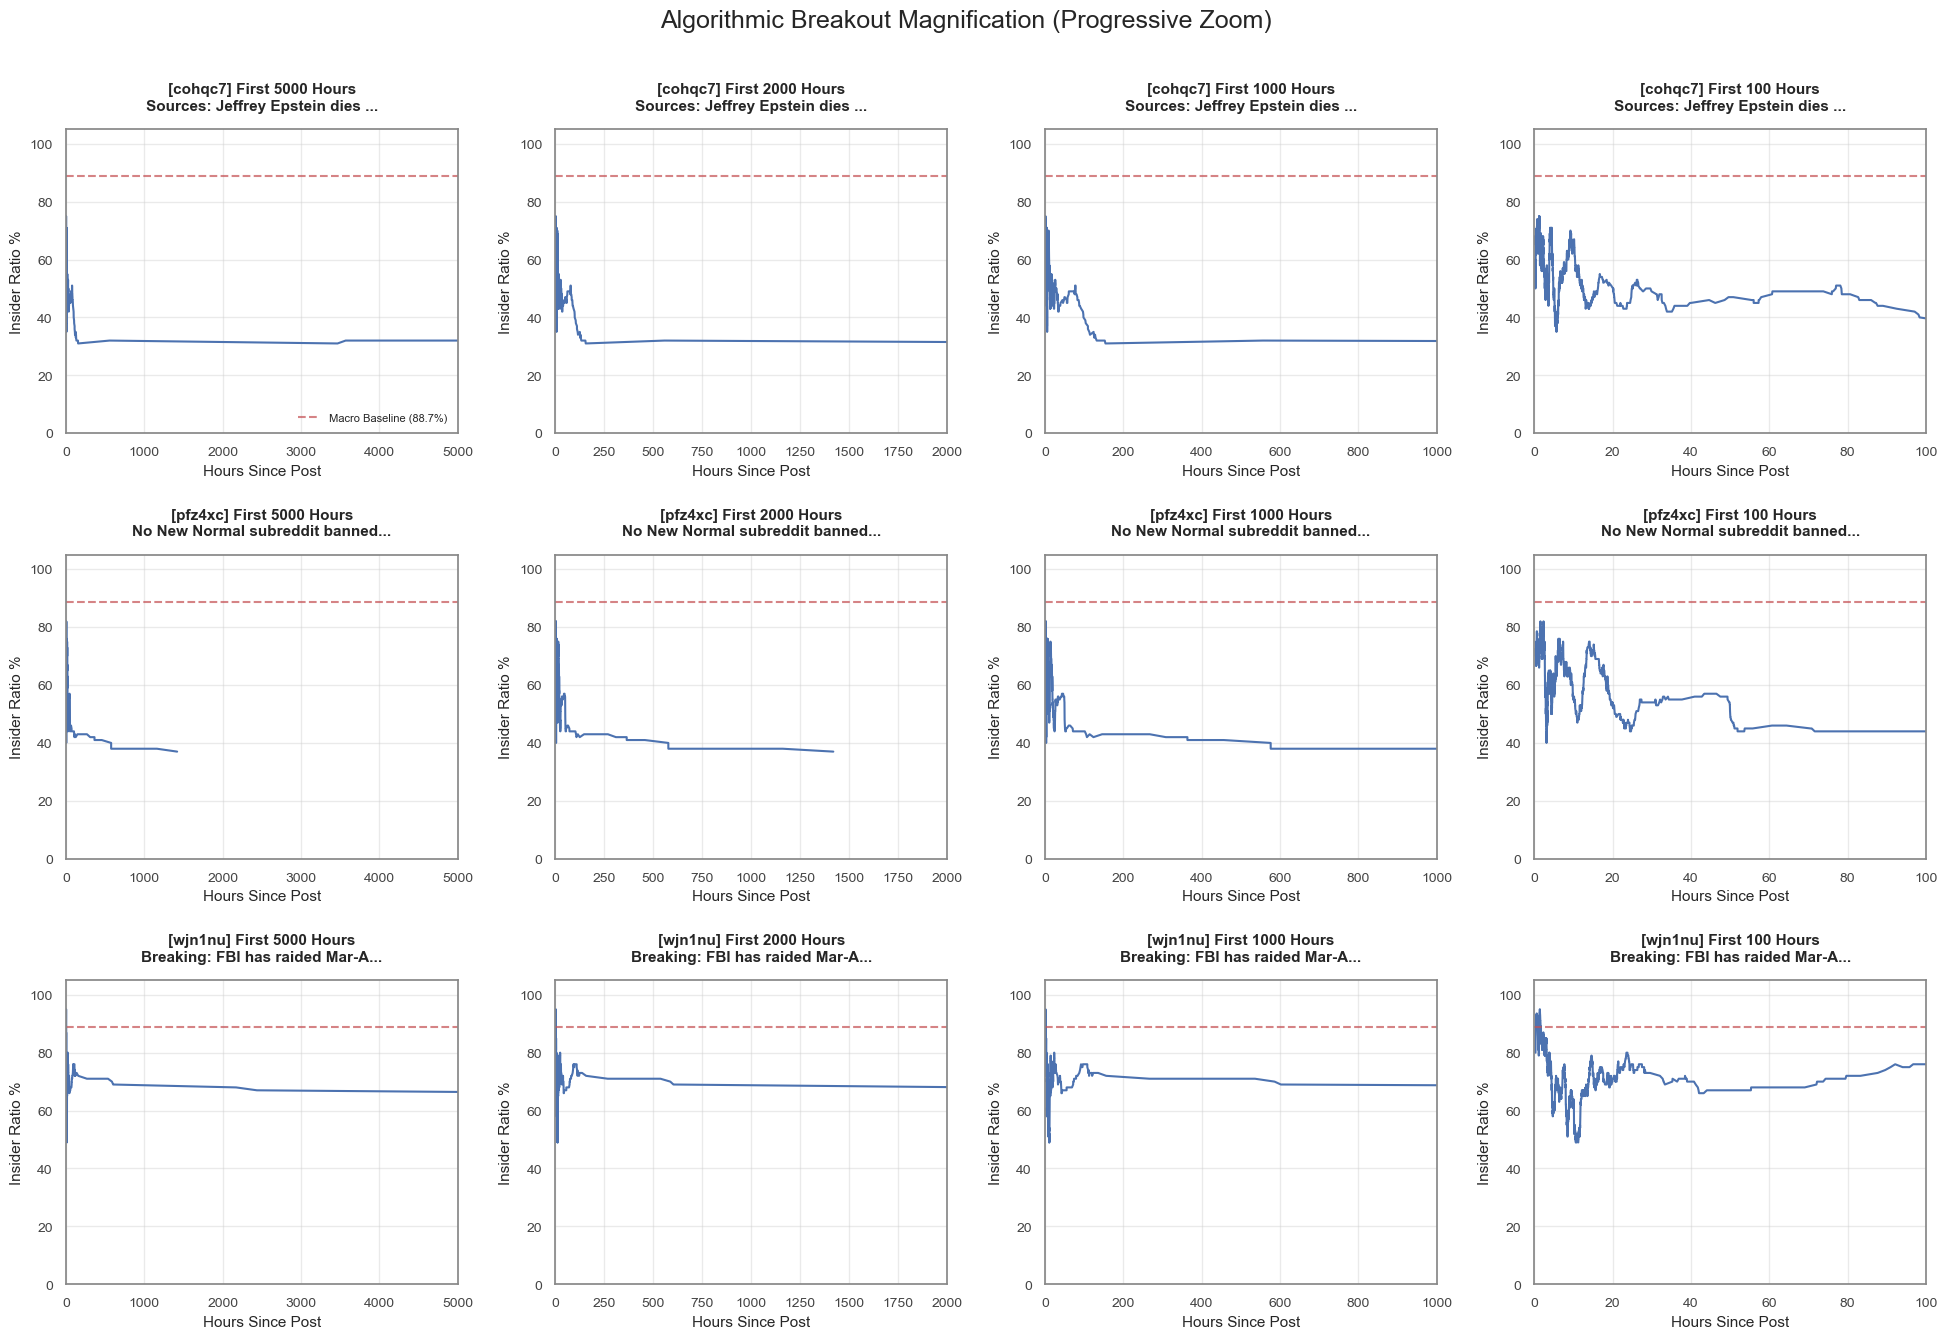

In [84]:
import matplotlib.pyplot as plt

# Using the df_target_posts and df_raw_comments already in your memory
target_ids = ['cohqc7', 'pfz4xc', 'wjn1nu']
time_limits = [5000, 2000, 1000, 100]

fig, axes = plt.subplots(3, 4, figsize=(24, 15))
fig.subplots_adjust(hspace=0.4, wspace=0.25)
baseline_avg = 88.7

for row_idx, post_id in enumerate(target_ids):
    post_meta = df_target_posts[df_target_posts['id'] == post_id].iloc[0]
    df_thread = df_raw_comments[df_raw_comments['clean_link_id'] == post_id].copy()
    
    # Calculate continuous timeline
    df_thread['hours_since_post'] = (df_thread['comment_created_utc'] - post_meta['post_created_utc']) / 3600.0
    df_thread = df_thread[df_thread['hours_since_post'] >= 0].sort_values('hours_since_post')
    
    # Map insider status to binary integer for rolling average calculations
    df_thread['is_insider_num'] = (df_thread['user_type'] == 'insider').astype(int)
    
    # Calculate the rolling ratio
    df_thread['rolling_insider_ratio'] = df_thread['is_insider_num'].rolling(window=100, min_periods=10).mean() * 100.0
    
    short_title = (post_meta['title'][:30] + '...') if len(post_meta['title']) > 30 else post_meta['title']
    
    for col_idx, t_limit in enumerate(time_limits):
        ax = axes[row_idx, col_idx]
        
        # Plot the data
        ax.plot(df_thread['hours_since_post'], df_thread['rolling_insider_ratio'], color='b', linewidth=1.5)
        ax.axhline(y=baseline_avg, color='r', linestyle='--', alpha=0.7, label='Macro Baseline (88.7%)')
        
        # Apply the specific zoom level directly to the x-axis limits
        ax.set_xlim(0, t_limit)
        ax.set_ylim(0, 105)
        
        if row_idx == 0 and col_idx == 0:
            ax.legend(loc='lower right', fontsize=8)
            
        ax.set_title(f"[{post_id}] First {t_limit} Hours\n{short_title}", fontsize=11)
        ax.set_xlabel("Hours Since Post")
        ax.set_ylabel("Insider Ratio %")
        ax.grid(True, alpha=0.4)

plt.suptitle("Algorithmic Breakout Magnification (Progressive Zoom)", fontsize=18, y=0.96)
plt.show()

Selecting reproducible random threads from each stratum...
Loading sampled strata data from cache...

Data ready. Generating plots...


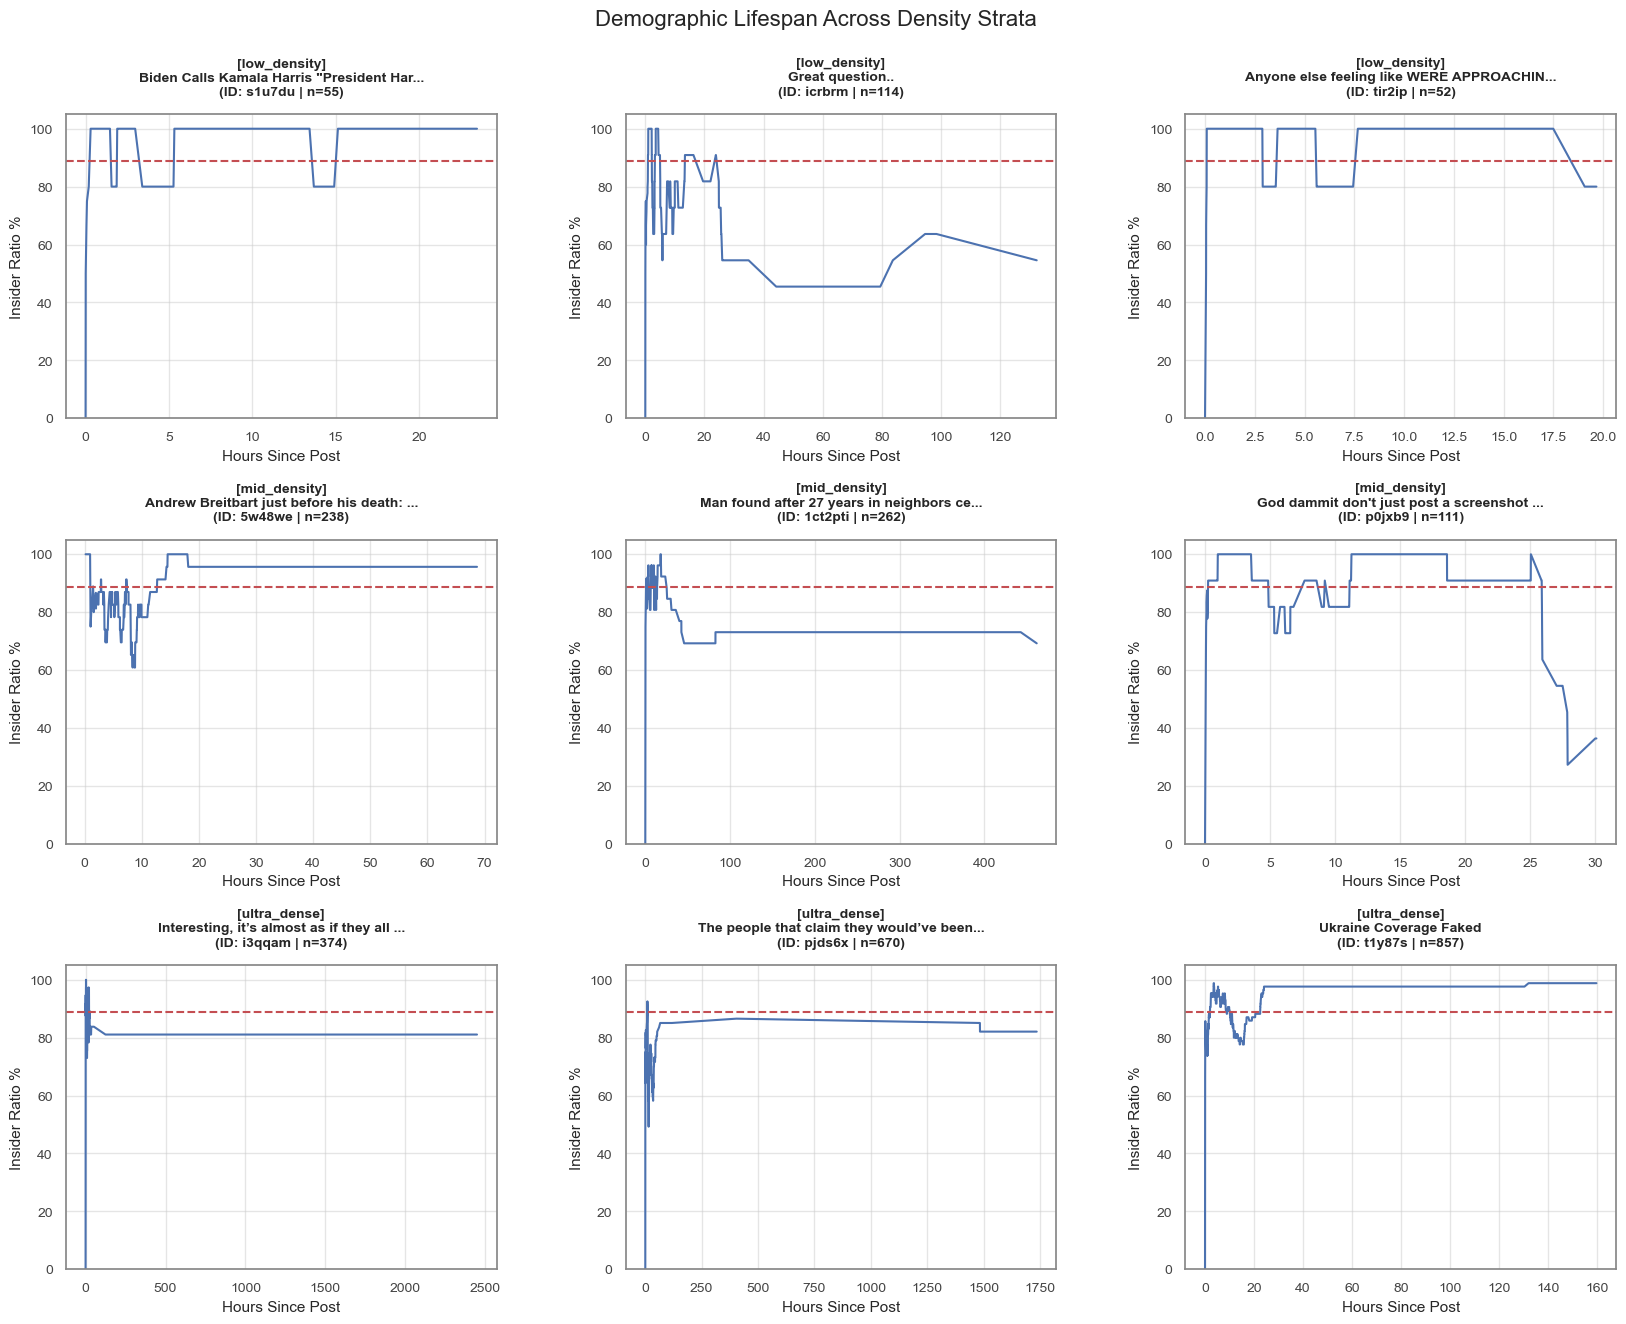

In [85]:
import os
import pandas as pd
import matplotlib.pyplot as plt

print("Selecting reproducible random threads from each stratum...")

SAMPLE_PATH = BASE + 'api_audit_sampling_1k.parquet'
POSTS_STRATA_CACHE = BASE + "sampled_strata_posts_meta.csv"
COMMENTS_STRATA_CACHE = BASE + "sampled_strata_raw_comments.csv"

# --- 1. THE CACHE PATTERN ---
if os.path.exists(POSTS_STRATA_CACHE) and os.path.exists(COMMENTS_STRATA_CACHE):
    print("Loading sampled strata data from cache...")
    df_strata_posts = pd.read_csv(POSTS_STRATA_CACHE)
    df_strata_comments = pd.read_csv(COMMENTS_STRATA_CACHE)
    
    df_sample = pd.read_parquet(SAMPLE_PATH)
    df_sample = df_sample[~df_sample['link_id'].isin(['cohqc7', 'wjn1nu', 'pfz4xc'])]
    sampled_targets = df_sample.groupby('strata').sample(n=3, random_state=42)

else:
    print("Cache not found. Scanning Parquet database...")
    
    df_sample = pd.read_parquet(SAMPLE_PATH)
    df_sample = df_sample[~df_sample['link_id'].isin(['cohqc7', 'wjn1nu', 'pfz4xc'])]
    sampled_targets = df_sample.groupby('strata').sample(n=3, random_state=42)
    target_ids = sampled_targets['link_id'].tolist()
    
    target_ids_sql = ", ".join([f"'{tid}'" for tid in target_ids])
    target_ids_prefixed = ", ".join([f"'t3_{tid}'" for tid in target_ids])
    
    # Grab Post Metadata
    posts_query = f"""
        SELECT id, created_utc as post_created_utc, title
        FROM read_json_auto('{RAW_POSTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE id IN ({target_ids_sql})
    """
    df_strata_posts = con.execute(posts_query).df()
    
    # Accurate raw query
    comments_query = f"""
        WITH global_author_counts AS (
            SELECT author, COUNT(*) as total_sub_comments
            FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
            WHERE author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
            GROUP BY author
        ),
        raw_comments AS (
            SELECT 
                CASE WHEN c.link_id LIKE 't3_%' THEN SUBSTRING(c.link_id, 4) ELSE c.link_id END as clean_link_id,
                c.author,
                c.created_utc as comment_created_utc
            FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True) c
            WHERE c.link_id IN ({target_ids_prefixed})
              AND c.body IS NOT NULL AND c.body NOT IN ('[deleted]', '[removed]')
        )
        SELECT 
            rc.clean_link_id,
            rc.comment_created_utc,
            CASE WHEN gac.total_sub_comments >= 21 THEN 1 ELSE 0 END as is_insider_num
        FROM raw_comments rc
        LEFT JOIN global_author_counts gac ON rc.author = gac.author
    """
    df_strata_comments = con.execute(comments_query).df()
    
    df_strata_posts.to_csv(POSTS_STRATA_CACHE, index=False)
    df_strata_comments.to_csv(COMMENTS_STRATA_CACHE, index=False)
    print("Data successfully cached.")

print("\nData ready. Generating plots...")

# --- 2. THE PLOTTING LOGIC ---
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

strata_order = ['low_density', 'mid_density', 'ultra_dense']
baseline_avg = 88.7

for row_idx, strata in enumerate(strata_order):
    strata_ids = sampled_targets[sampled_targets['strata'] == strata]['link_id'].tolist()
    
    for col_idx, post_id in enumerate(strata_ids):
        ax = axes[row_idx, col_idx]
        
        post_meta_match = df_strata_posts[df_strata_posts['id'] == post_id]
        if post_meta_match.empty:
            ax.set_title(f"{post_id} (Metadata Missing)")
            continue
            
        post_meta = post_meta_match.iloc[0]
        df_thread = df_strata_comments[df_strata_comments['clean_link_id'] == post_id].copy()
        
        if df_thread.empty:
            ax.set_title(f"{post_id} (No Comments Found)")
            continue
        
        df_thread['hours_since_post'] = (df_thread['comment_created_utc'] - post_meta['post_created_utc']) / 3600.0
        df_thread = df_thread[df_thread['hours_since_post'] >= 0].sort_values('hours_since_post')
        
        # Dynamic rolling window based on thread volume
        window_size = min(100, max(5, len(df_thread) // 10))
        df_thread['rolling_insider_ratio'] = df_thread['is_insider_num'].rolling(window=window_size, min_periods=1).mean() * 100.0
        
        ax.plot(df_thread['hours_since_post'], df_thread['rolling_insider_ratio'], color='b')
        ax.axhline(y=baseline_avg, color='r', linestyle='--', label='Macro Baseline')
        
        short_title = (post_meta['title'][:40] + '...') if len(post_meta['title']) > 40 else post_meta['title']
        ax.set_title(f"[{strata}]\n{short_title}\n(ID: {post_id} | n={len(df_thread)})", fontsize=10)
        ax.set_xlabel("Hours Since Post")
        ax.set_ylabel("Insider Ratio %")
        ax.set_ylim(0, 105)
        ax.grid(True, alpha=0.5)

plt.suptitle("Demographic Lifespan Across Density Strata", fontsize=16, y=0.95)
plt.show()


Filtering for verified cross-posted threads...
Found 299 eligible cross-posted threads in the sample.
Selected Targets: ['8esst2', 'b3h4t4', '1k8v23c', 'acumre', '6o9spf', '9g10yq', '1m73qox', 'm58yfc', 'rp28n2']
Loading cross-posted strata data from cache...

Data ready. Generating progressive zoom matrix...


/var/folders/ym/6mr3ypl97rj6468b4m65lq240000gp/T/ipykernel_11738/378747385.py:23: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



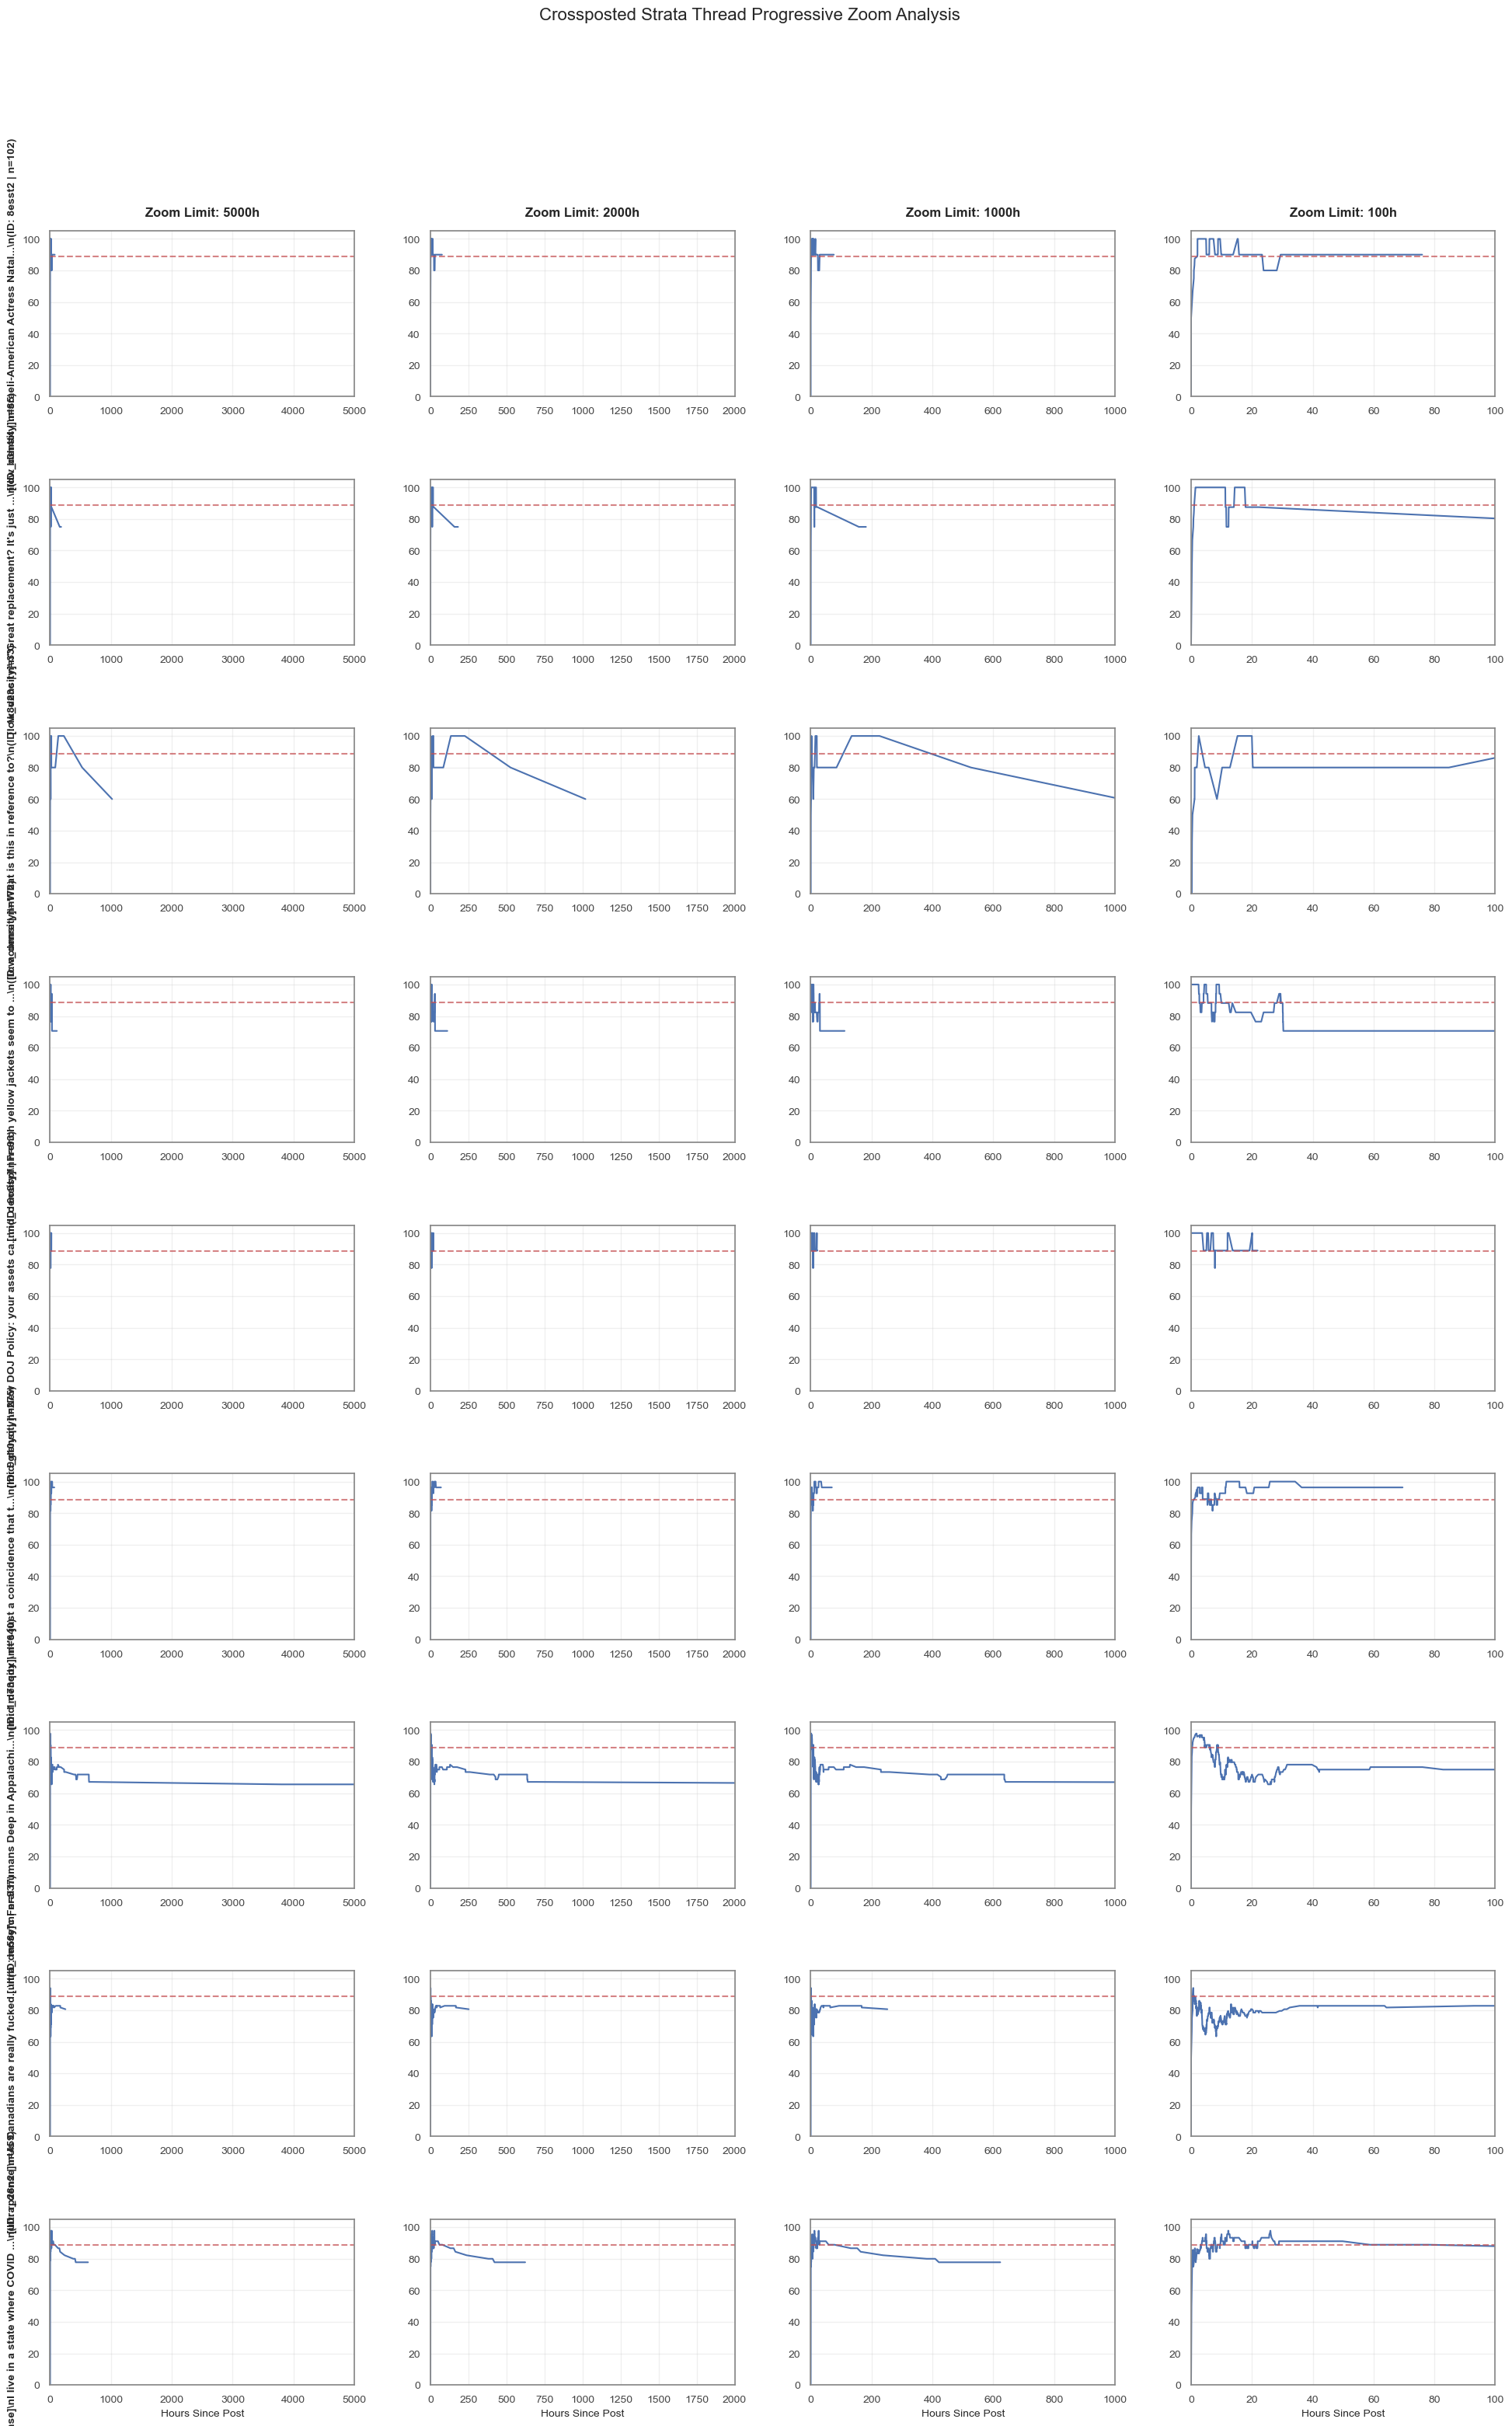

In [86]:
import os
import pandas as pd
import matplotlib.pyplot as plt

print("Filtering for verified cross-posted threads...")

# 1. Define paths and new dedicated cache files
SAMPLE_PATH = BASE + 'api_audit_sampling_1k.parquet'
PROGRESS_CSV = BASE + 'cross_post_audit_results.csv'
POSTS_CROSSPOST_CACHE = BASE + "crosspost_strata_posts_meta.csv"
COMMENTS_CROSSPOST_CACHE = BASE + "crosspost_strata_raw_comments.csv"

# --- 2. PANDAS FILTERING & SAMPLING (Takes milliseconds) ---
df_audit = pd.read_csv(PROGRESS_CSV)
crossposted_ids = df_audit[df_audit['external_subreddit'] != 'NONE_FOUND']['source_post_id'].astype(str).unique()

df_sample = pd.read_parquet(SAMPLE_PATH)
df_sample = df_sample[~df_sample['link_id'].isin(['cohqc7', 'wjn1nu', 'pfz4xc'])]
df_crossposted = df_sample[df_sample['link_id'].astype(str).isin(crossposted_ids)]

print(f"Found {len(df_crossposted)} eligible cross-posted threads in the sample.")

sampled_targets = df_crossposted.groupby('strata').apply(lambda x: x.sample(n=min(len(x), 3), random_state=42)).reset_index(drop=True)

strata_order = ['low_density', 'mid_density', 'ultra_dense']
sampled_targets['strata_cat'] = pd.Categorical(sampled_targets['strata'], categories=strata_order, ordered=True)
sampled_targets = sampled_targets.sort_values('strata_cat')

target_ids = sampled_targets['link_id'].tolist()
print(f"Selected Targets: {target_ids}")

# --- 3. THE CACHE PATTERN & PARQUET UPGRADE ---
if os.path.exists(POSTS_CROSSPOST_CACHE) and os.path.exists(COMMENTS_CROSSPOST_CACHE):
    print("Loading cross-posted strata data from cache...")
    df_crosspost_posts = pd.read_csv(POSTS_CROSSPOST_CACHE)
    df_crosspost_comments = pd.read_csv(COMMENTS_CROSSPOST_CACHE)

else:
    print("Cache not found. Scanning...")
    target_ids_sql = ", ".join([f"'{tid}'" for tid in target_ids])
    target_ids_prefixed = ", ".join([f"'t3_{tid}'" for tid in target_ids])
    
    # Use RAW_POSTS wildcard instead of UNION ALL
    posts_query = f"""
        SELECT id, created_utc as post_created_utc, title
        FROM read_json_auto('{RAW_POSTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE id IN ({target_ids_sql})
    """
    df_crosspost_posts = con.execute(posts_query).df()
    
    # Accurate raw query
    comments_query = f"""
        WITH global_author_counts AS (
            SELECT author, COUNT(*) as total_sub_comments
            FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
            WHERE author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
            GROUP BY author
        ),
        raw_comments AS (
            SELECT 
                CASE WHEN c.link_id LIKE 't3_%' THEN SUBSTRING(c.link_id, 4) ELSE c.link_id END as clean_link_id,
                c.author,
                c.created_utc as comment_created_utc
            FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True) c
            WHERE c.link_id IN ({target_ids_prefixed})
              AND c.body IS NOT NULL AND c.body NOT IN ('[deleted]', '[removed]')
        )
        SELECT 
            rc.clean_link_id,
            rc.comment_created_utc,
            CASE WHEN gac.total_sub_comments >= 21 THEN 1 ELSE 0 END as is_insider_num
        FROM raw_comments rc
        LEFT JOIN global_author_counts gac ON rc.author = gac.author
    """
    df_crosspost_comments = con.execute(comments_query).df()
    
    df_crosspost_posts.to_csv(POSTS_CROSSPOST_CACHE, index=False)
    df_crosspost_comments.to_csv(COMMENTS_CROSSPOST_CACHE, index=False)
    print("Data successfully cached.")

print("\nData ready. Generating progressive zoom matrix...")

# --- 4. THE PLOTTING LOGIC ---
time_limits = [5000, 2000, 1000, 100]
num_targets = len(target_ids)

fig, axes = plt.subplots(num_targets, 4, figsize=(24, 4 * num_targets))
fig.subplots_adjust(hspace=0.5, wspace=0.25)
baseline_avg = 88.7

for row_idx, post_id in enumerate(target_ids):
    strata_val = sampled_targets[sampled_targets['link_id'] == post_id]['strata'].iloc[0]
    
    post_meta_match = df_crosspost_posts[df_crosspost_posts['id'] == post_id]
    if post_meta_match.empty:
        for ax in axes[row_idx, :]: ax.set_visible(False)
        continue
        
    post_meta = post_meta_match.iloc[0]
    df_thread = df_crosspost_comments[df_crosspost_comments['clean_link_id'] == post_id].copy()
    
    if df_thread.empty:
        for ax in axes[row_idx, :]: ax.set_visible(False)
        continue
        
    # Calculate continuous timeline
    df_thread['hours_since_post'] = (df_thread['comment_created_utc'] - post_meta['post_created_utc']) / 3600.0
    df_thread = df_thread[df_thread['hours_since_post'] >= 0].sort_values('hours_since_post')
    
    # Dynamic window size so sparse low_density threads chart cleanly
    window_size = min(100, max(5, len(df_thread) // 10))
    df_thread['rolling_insider_ratio'] = df_thread['is_insider_num'].rolling(window=window_size, min_periods=1).mean() * 100.0
    
    short_title = (post_meta['title'][:30] + '...') if len(post_meta['title']) > 30 else post_meta['title']
    
    for col_idx, t_limit in enumerate(time_limits):
        if num_targets == 1:
            ax = axes[col_idx]
        else:
            ax = axes[row_idx, col_idx]
            
        ax.plot(df_thread['hours_since_post'], df_thread['rolling_insider_ratio'], color='b', linewidth=1.5)
        ax.axhline(y=baseline_avg, color='r', linestyle='--', alpha=0.7, label='Macro Baseline (88.7%)')
        
        ax.set_xlim(0, t_limit)
        ax.set_ylim(0, 105)
        ax.grid(True, alpha=0.3)
        
        if row_idx == 0:
            ax.set_title(f"Zoom Limit: {t_limit}h", fontsize=12, fontweight='bold')
            
        if col_idx == 0:
            ax.set_ylabel(f"[{strata_val}]\\n{short_title}\\n(ID: {post_id} | n={len(df_thread)})", fontsize=10, fontweight='bold')
            
        if row_idx == num_targets - 1:
            ax.set_xlabel("Hours Since Post", fontsize=10)

plt.suptitle("Crossposted Strata Thread Progressive Zoom Analysis", fontsize=16, y=0.96)
plt.show()


In [87]:
SAMPLE_PATH = BASE + 'api_audit_sampling_1k.parquet'

print("Aggregating system-wide demographic baselines across all sampling strata...")

macro_strata_query = f"""
    WITH sample_targets AS (
        SELECT link_id, strata
        FROM read_parquet('{SAMPLE_PATH}')
    ),
    global_author_counts AS (
        SELECT author, COUNT(*) as total_sub_comments
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
        GROUP BY author
    ),
    raw_comments AS (
        SELECT
            CASE WHEN c.link_id LIKE 't3_%' THEN SUBSTRING(c.link_id, 4) ELSE c.link_id END as clean_link_id,
            c.author
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True) c
        WHERE c.body IS NOT NULL AND c.body NOT IN ('[deleted]', '[removed]')
    ),
    joined_metrics AS (
        SELECT
            st.strata,
            st.link_id,
            CASE WHEN gac.total_sub_comments >= 21 THEN 1 ELSE 0 END as is_regular
        FROM raw_comments rc
        JOIN sample_targets st ON rc.clean_link_id = st.link_id
        LEFT JOIN global_author_counts gac ON rc.author = gac.author
    )
    SELECT
        strata,
        COUNT(DISTINCT link_id) as total_threads_measured,
        COUNT(*) as total_comments_analyzed,
        ROUND(SUM(is_regular) * 100.0 / COUNT(*), 2) as aggregate_regular_ratio_pct
    FROM joined_metrics
    GROUP BY strata
    ORDER BY aggregate_regular_ratio_pct DESC
"""
try:
    df_macro_baseline = cached_query_csv(con, BASE + "macro_baseline.csv", macro_strata_query)
except Exception as e:
    print("Macro aggregation failed:", e)
print("\n=== Macro Demographic Ratios Across Strata ===")
print(df_macro_baseline.to_string(index=False))


Aggregating system-wide demographic baselines across all sampling strata...
Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/macro_baseline.csv

=== Macro Demographic Ratios Across Strata ===
     strata  total_threads_measured  total_comments_analyzed  aggregate_regular_ratio_pct
low_density                     329                    28783                       88.670
mid_density                     513                    93083                       87.970
ultra_dense                     158                    90866                       83.060


In [88]:
import os
import pandas as pd

print("Calculating baseline active users and estimated voting pools...")

CACHE_FILE = BASE + "insider_vote_baselines.csv"

query = f"""
    WITH valid_comments AS (
        SELECT
            author,
            date_trunc('month', to_timestamp(created_utc)) as comment_month
        FROM read_json_auto('{COMMENTS_GLOB}', maximum_object_size=50000000, union_by_name=True)
        WHERE author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
    ),
    author_totals AS (
        SELECT author, COUNT(*) as lifetime_comments
        FROM valid_comments
        GROUP BY author
    ),
    monthly_activity AS (
        SELECT
            v.comment_month,
            COUNT(DISTINCT v.author) as monthly_unique_authors,
            COUNT(DISTINCT CASE WHEN a.lifetime_comments >= 21 THEN v.author END) as monthly_unique_insiders
        FROM valid_comments v
        JOIN author_totals a ON v.author = a.author
        GROUP BY v.comment_month
    )
    SELECT
        strftime(comment_month, '%Y-%m') as month,
        monthly_unique_authors as total_authors,
        monthly_unique_insiders as insider_authors,
        ROUND(monthly_unique_insiders / 30.0, 0)::INT as avg_daily_insider_commenters,
        ROUND((monthly_unique_insiders / 30.0) * 10, 0)::INT as estimated_daily_insider_votes
    FROM monthly_activity
    ORDER BY comment_month ASC
"""

try:
    df_base_rate = cached_query_csv(con, CACHE_FILE, query)
    print("\n=== Recent Monthly Baselines ===")
    print(df_base_rate.tail(24).to_string(index=False))
except Exception as e:
    print("Base rate calculation failed:", e)


Calculating baseline active users and estimated voting pools...
Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/insider_vote_baselines.csv

=== Recent Monthly Baselines ===
  month  total_authors  insider_authors  avg_daily_insider_commenters  estimated_daily_insider_votes
2024-07          46586            25203                           840                           8401
2024-08          40276            23681                           789                           7894
2024-09          36423            21727                           724                           7242
2024-10          39334            22785                           760                           7595
2024-11          40539            23637                           788                           7879
2024-12          39352            21994                           733                           7331
2025-01          39450            22427                           748                 

In [89]:
print("Analyzing the distribution of user activity in r/conspiracy...\n")

query_percentiles = f"""
    WITH author_counts AS (
        SELECT author, COUNT(*) as total_comments
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
        GROUP BY author
    )
    SELECT
        COUNT(*) as total_unique_authors,
        percentile_cont(0.50) WITHIN GROUP (ORDER BY total_comments) as median_comments,
        percentile_cont(0.75) WITHIN GROUP (ORDER BY total_comments) as p75_comments,
        percentile_cont(0.90) WITHIN GROUP (ORDER BY total_comments) as p90_comments,
        percentile_cont(0.95) WITHIN GROUP (ORDER BY total_comments) as p95_comments,
        percentile_cont(0.99) WITHIN GROUP (ORDER BY total_comments) as p99_comments
    FROM author_counts
"""

query_tiers = f"""
    WITH author_counts AS (
        SELECT author, COUNT(*) as total_comments
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
        GROUP BY author
    )
    SELECT
        CASE
            WHEN total_comments = 1 THEN '01: 1 comment (Drive-by)'
            WHEN total_comments BETWEEN 2 AND 5 THEN '02: 2-5 comments (Tourist)'
            WHEN total_comments BETWEEN 6 AND 20 THEN '03: 6-20 comments (Casual)'
            WHEN total_comments BETWEEN 21 AND 50 THEN '04: 21-50 comments (Regular)'
            WHEN total_comments BETWEEN 51 AND 200 THEN '05: 51-200 comments (Active)'
            WHEN total_comments BETWEEN 201 AND 1000 THEN '06: 201-1000 comments (Power User)'
            WHEN total_comments > 1000 THEN '07: 1000+ comments (Super User)'
        END as activity_tier,
        COUNT(*) as number_of_authors,
        SUM(total_comments) as total_comments_generated
    FROM author_counts
    GROUP BY 1
    ORDER BY 1
"""

def _add_tier_percentages(df):
    df['pct_of_authors'] = (df['number_of_authors'] / df['number_of_authors'].sum() * 100).round(2)
    df['pct_of_total_comments'] = (df['total_comments_generated'] / df['total_comments_generated'].sum() * 100).round(2)
    return df

try:
    print("--- User Percentiles ---")
    df_percentiles = cached_query_csv(con, BASE + "percentiles.csv", query_percentiles)
    print(df_percentiles.to_string(index=False))

    print("\n--- Distribution Tiers ---")
    df_tiers = cached_query_csv(con, BASE + "tiers.csv", query_tiers, postprocess=_add_tier_percentages)
    print(df_tiers.to_string(index=False))
except Exception as e:
    print("Error:", e)


Analyzing the distribution of user activity in r/conspiracy...

--- User Percentiles ---
Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/percentiles.csv
 total_unique_authors  median_comments  p75_comments  p90_comments  p95_comments  p99_comments
              1217900            2.000         9.000        38.000        97.000       522.000

--- Distribution Tiers ---
Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/tiers.csv
                     activity_tier  number_of_authors  total_comments_generated  pct_of_authors  pct_of_total_comments
          01: 1 comment (Drive-by)             447644                447644.000          36.760                  1.180
        02: 2-5 comments (Tourist)             370177               1098519.000          30.390                  2.900
        03: 6-20 comments (Casual)             215806               2299525.000          17.720                  6.080
      04: 21-50 comments (R

---
### 9.8 Lexical Insider Score & Community Convergence

Builds a month-specific "core vocabulary" baseline, then scores each commenter's cosine similarity to that norm. Key question: **does consistent approval require epistemic alignment with community jargon?**

Shared variables: `TARGET_MONTH`, `BASELINE_CSV`, `df_base`, `vocab`, `vectorizer`. Each visualization cell is a distinct cut (tier, thread size, keyness vocabulary, Aug 2022 comparison).

In [90]:
# Shared setup for Section 9.8 (run once before the visualization cells)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity

TARGET_MONTH = '2025-01'  # section-wide month; the Aug-2022 anomaly cell uses its own ANOMALY_MONTH
BASELINE_CSV = f'{BASE}lexical_baseline_{TARGET_MONTH}.csv'
df_base = pd.read_csv(BASELINE_CSV)

# --- CONCEPTUAL FIX: Semantic Stop-Word Filtering ---
# Instead of blindly slicing the top 100 words (iloc[100:]), we filter out 
# linguistic stop words and generic internet jargon to isolate true subcultural markers.
custom_stops = set(ENGLISH_STOP_WORDS).union({
    'just', 'like', 'don', 'people', 'think', 'know', 'really', 'make', 'did', 'does',
    'reddit', 'sub', 'conspiracy', 'post', 'comment', 'http', 'https', 'com', 'www',
    've', 'll', 're', 'didn', 'doesn', 'going', 'say', 'way', 'got', 'right', 'good', 'time'
})

# Filter the baseline vocabulary
df_jargon = df_base[~df_base['word'].isin(custom_stops)].copy()

# Set the global vocabulary and corpus vector for all subsequent query cells
vocab = df_jargon['word'].tolist()
corpus_counts = df_jargon['term_frequency'].values.reshape(1, -1)
print(f"Loaded global baseline. Kept {len(vocab)} non-stop words for semantic scoring.")

# --- UNIFIED PLOTTING HELPER ---
# Condenses boilerplate for vectorizing, scoring convergence, and plotting boxplots.
def score_and_boxplot(df, text_col, group_col, title, x_label="Strict Jargon Score", y_label="", palette="viridis", order=None, show_summary=True, orient='h', rotation=0, custom_vocab=None, custom_counts=None):
    v = custom_vocab if custom_vocab is not None else vocab
    c = custom_counts if custom_counts is not None else corpus_counts
    
    vectorizer = CountVectorizer(vocabulary=v)
    user_matrix = vectorizer.fit_transform(df[text_col])
    similarities = cosine_similarity(user_matrix, c)
    df['lexical_insider_score'] = similarities.flatten()
    
    df_signal = df[df['lexical_insider_score'] > 0.0].copy()
    
    if show_summary:
        summary = df_signal.groupby(group_col).agg(
            user_count=('author' if 'author' in df_signal.columns else group_col, 'count'),
            avg_lexical_score=('lexical_insider_score', 'mean'),
            median_lexical_score=('lexical_insider_score', 'median')
        ).reset_index()
        print(f"=== {title} ===")
        print(summary.to_string(index=False))
        print("\n")
        
    plt.figure(figsize=(12, 6) if orient == 'h' else (14, 7))
    sns.set_style("whitegrid")
    
    if orient == 'v':
        sns.boxplot(data=df_signal, x=group_col, y='lexical_insider_score', palette=palette, showfliers=False, order=order if order else sorted(df_signal[group_col].unique()))
        plt.xlabel(x_label if x_label else group_col, fontsize=12)
        plt.ylabel("Strict Jargon Score", fontsize=12)
    else:
        sns.boxplot(data=df_signal, y=group_col, x='lexical_insider_score', palette=palette, showfliers=False, order=order if order else sorted(df_signal[group_col].unique()))
        plt.xlabel("Strict Jargon Score", fontsize=12)
        plt.ylabel(y_label if y_label else group_col, fontsize=12)
        
    plt.title(title, fontsize=15, pad=15)
    if rotation:
        plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()
    return df_signal


Loaded global baseline. Kept 4972 non-stop words for semantic scoring.


In [91]:
# 1. Setup paths and load the baseline
# NOTE: depends on TARGET_MONTH and df_base being set by the lexical baseline cell above

if os.path.exists(BASE + "liscc.csv"):
    results = pd.read_csv(BASE + "liscc.csv")
    
    print("=== Lexical Profiles of Top Upvoted Users ===")
    print(results.to_string(index=False))
else:
    
    print(f"Loading baseline vocabulary for {TARGET_MONTH}...")
    vocab = df_base['word'].tolist()
    corpus_counts = df_base['term_frequency'].values.reshape(1, -1)
    
    # 2. Find target threads in Jan 2025 from the stratified sample
    print("Locating Ultra-Dense and Low-Density threads in Jan 2025...")
    find_threads_query = f"""
        WITH posts AS (
            SELECT id, strftime(to_timestamp(created_utc), '%Y-%m') as post_month
            FROM read_json_auto('{RAW_POSTS}', maximum_object_size=50000000, union_by_name=True)
        ),
        sample AS (
            SELECT * FROM '{SAMPLE_PATH}'
        )
        SELECT s.link_id, s.strata
        FROM sample s
        JOIN posts p ON s.link_id = p.id
        WHERE p.post_month = '{TARGET_MONTH}'
          AND s.strata IN ('low_density', 'ultra_dense')
    """
    df_threads = con.execute(find_threads_query).df()
    
    # Get one of each (if available)
    low_density_id = df_threads[df_threads['strata'] == 'low_density']['link_id'].iloc[0] if not df_threads[df_threads['strata'] == 'low_density'].empty else None
    ultra_dense_id = df_threads[df_threads['strata'] == 'ultra_dense']['link_id'].iloc[0] if not df_threads[df_threads['strata'] == 'ultra_dense'].empty else None
    
    if not low_density_id or not ultra_dense_id:
        print("WARNING: Could not find both a low_density and ultra_dense thread in Jan 2025 in your sample.")
        print("Try generating a baseline for a month where you know you have both (e.g., '2022-08').")
    else:
        print(f"Selected Low Density: {low_density_id} | Selected Ultra Dense: {ultra_dense_id}")
        
        target_ids_sql = f"'{low_density_id}', '{ultra_dense_id}'"
    
        scoring_query = f"""
            WITH top_comments AS (
                SELECT 
                    CASE WHEN link_id LIKE 't3_%' THEN SUBSTRING(link_id, 4) ELSE link_id END as clean_link_id,
                    author,
                    score
                FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
                WHERE CASE WHEN link_id LIKE 't3_%' THEN SUBSTRING(link_id, 4) ELSE link_id END IN ({target_ids_sql})
                  AND author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
            ),
            ranked_authors AS (
                SELECT 
                    clean_link_id, author, MAX(score) as max_upvotes,
                    ROW_NUMBER() OVER(PARTITION BY clean_link_id ORDER BY MAX(score) DESC) as rn
                FROM top_comments
                GROUP BY clean_link_id, author
            ),
            target_authors AS (
                SELECT clean_link_id, author, max_upvotes 
                FROM ranked_authors WHERE rn <= 30
            ),
            monthly_text AS (
                SELECT 
                    author, 
                    STRING_AGG(lower(regexp_replace(body, '[^a-zA-Z]', ' ', 'g')), ' ') as aggregated_text
                FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
                WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
                GROUP BY author
            )
            SELECT t.clean_link_id as thread_id, t.author, t.max_upvotes, m.aggregated_text
            FROM target_authors t
            JOIN monthly_text m ON t.author = m.author
        """
        ...
        
        df_targets = con.execute(scoring_query).df()
        print(f"Extracted {len(df_targets)} target authors. Calculating Lexical Similarity...\n")
    
        # 4. Vectorize and Score
        vectorizer = CountVectorizer(vocabulary=vocab)
        user_matrix = vectorizer.fit_transform(df_targets['aggregated_text'])
        similarities = cosine_similarity(user_matrix, corpus_counts)
        df_targets['lexical_insider_score'] = similarities.flatten()
    
        # 5. Label the strata and aggregate
        df_targets['strata'] = df_targets['thread_id'].map({low_density_id: 'Organic (Low Density)', ultra_dense_id: 'Hijacked (Ultra Dense)'})
        
        results = df_targets.groupby('strata').agg(
            top_commenters_scored=('author', 'count'),
            avg_upvotes=('max_upvotes', 'mean'),
            avg_lexical_score=('lexical_insider_score', 'mean'),
            median_lexical_score=('lexical_insider_score', 'median')
        ).reset_index()
        results.to_csv(BASE+"liscc.csv", index = False)
    
        print("=== Lexical Profiles of Top Upvoted Users ===")
        print(results.to_string(index=False))


=== Lexical Profiles of Top Upvoted Users ===
                strata  top_commenters_scored  avg_upvotes  avg_lexical_score  median_lexical_score
Hijacked (Ultra Dense)                     30      148.167              0.300                 0.292
 Organic (Low Density)                     24        9.167              0.299                 0.265


Extracting massive length-filtered sample by Granular Upvote Tiers...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Sampled 6771 LONG comments. Scoring and plotting...



=== Do Highly Upvoted Comments Sound Like the Community? (2025-01) ===
           upvote_tier  user_count  avg_lexical_score  median_lexical_score
    01: Downvoted (<1)        2000              0.101                 0.097
     02: Normal (1-10)        2000              0.241                 0.110
      03: Good (11-50)        2000              0.096                 0.091
    04: Great (51-100)         429              0.096                 0.091
05: Breakout (101-200)         201              0.096                 0.092
   06: Viral (201-500)         112              0.097                 0.091
 07: Mega-Viral (500+)          29              0.085                 0.086




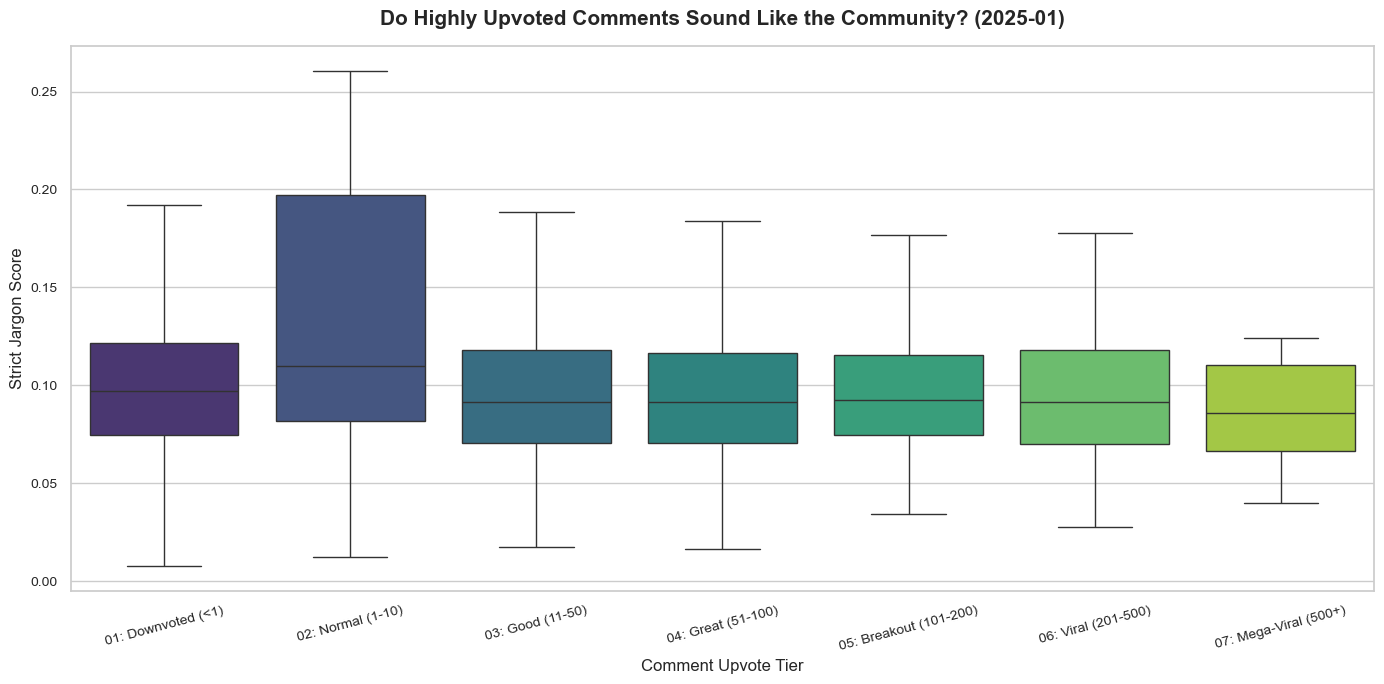

In [92]:
print("Extracting massive length-filtered sample by Granular Upvote Tiers...")

# 2. Extract balanced sample, strictly filtering for length (> 300 characters)
query = f"""
    WITH all_month AS (
        SELECT 
            score,
            lower(regexp_replace(body, '[^a-zA-Z]', ' ', 'g')) as clean_body,
            CASE 
                WHEN score < 1 THEN '01: Downvoted (<1)'
                WHEN score BETWEEN 1 AND 10 THEN '02: Normal (1-10)'
                WHEN score BETWEEN 11 AND 50 THEN '03: Good (11-50)'
                WHEN score BETWEEN 51 AND 100 THEN '04: Great (51-100)'
                WHEN score BETWEEN 101 AND 200 THEN '05: Breakout (101-200)'
                WHEN score BETWEEN 201 AND 500 THEN '06: Viral (201-500)'
                WHEN score > 500 THEN '07: Mega-Viral (500+)'
            END as upvote_tier,
            RANDOM() as rnd
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
          AND body IS NOT NULL AND body NOT IN ('[deleted]', '[removed]')
          -- STRICT LENGTH FILTER
          AND length(body) > 300 
    ),
    sampled AS (
        SELECT * FROM (
            SELECT *, ROW_NUMBER() OVER(PARTITION BY upvote_tier ORDER BY rnd) as rn 
            FROM all_month
        )
        -- Pull up to 2,000 long comments per tier to ensure robust medians
        WHERE rn <= 2000
    )
    SELECT upvote_tier, score, clean_body 
    FROM sampled
    ORDER BY upvote_tier
"""

df_sample = con.execute(query).df()
print(f"Sampled {len(df_sample)} LONG comments. Scoring and plotting...\n")

df_signal = score_and_boxplot(
    df=df_sample,
    text_col='clean_body',
    group_col='upvote_tier',
    title=f"Do Highly Upvoted Comments Sound Like the Community? ({TARGET_MONTH})",
    x_label="Comment Upvote Tier",
    palette='viridis',
    orient='v',
    rotation=15
)


Calculating thread sizes and extracting sample...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Sampled 11779 LONG comments across thread sizes. Scoring and plotting...



=== Linguistic Dilution: How Thread Size Affects Community Jargon (2025-01) ===
      thread_size_tier  user_count  avg_lexical_score  median_lexical_score
       01: Dead (1-10)        2500              0.494                 0.696
     02: Niche (11-50)        2500              0.233                 0.108
   03: Active (51-200)        2500              0.143                 0.099
    04: Hot (201-1000)        2500              0.113                 0.097
05: Megathread (1000+)        1779              0.105                 0.098




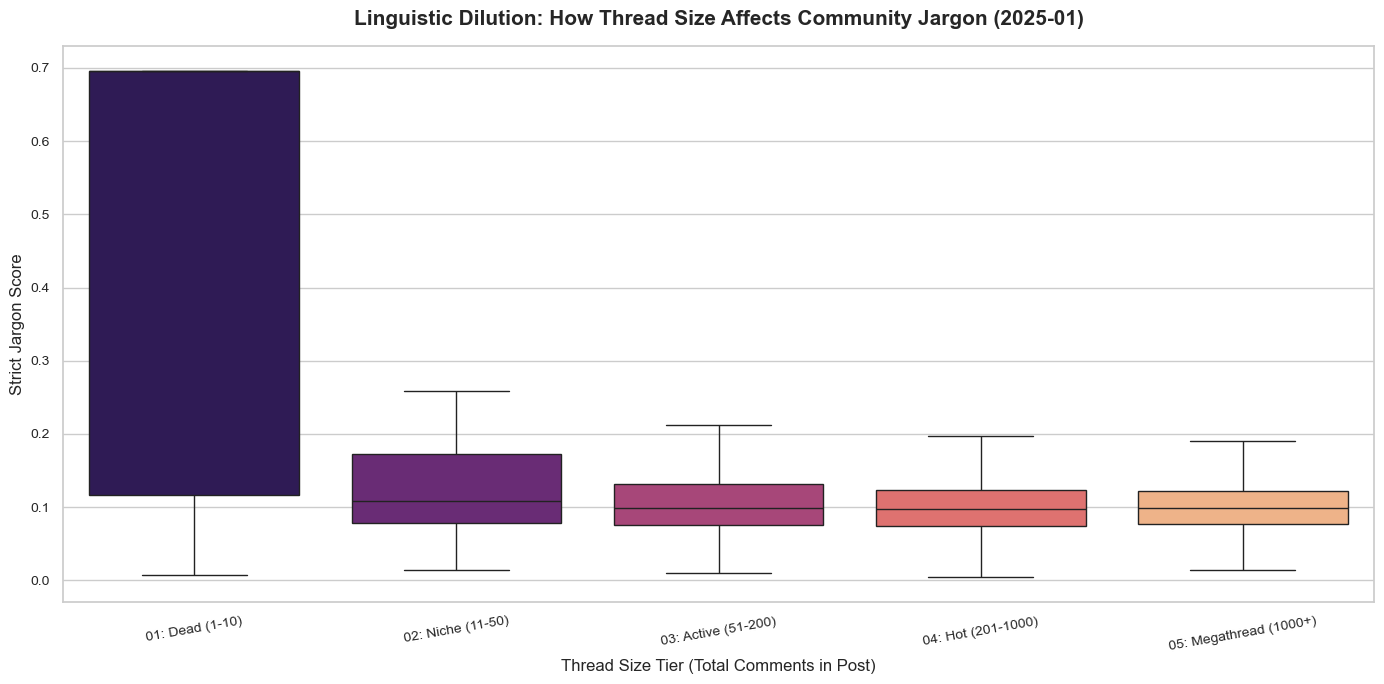

In [93]:
print("Calculating thread sizes and extracting sample...")

query = f"""
    WITH thread_sizes AS (
        SELECT 
            CASE WHEN link_id LIKE 't3_%' THEN SUBSTRING(link_id, 4) ELSE link_id END as clean_link_id,
            COUNT(*) as total_comments_in_thread
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
        GROUP BY clean_link_id
    ),
    long_comments AS (
        SELECT 
            CASE WHEN link_id LIKE 't3_%' THEN SUBSTRING(link_id, 4) ELSE link_id END as clean_link_id,
            lower(regexp_replace(body, '[^a-zA-Z]', ' ', 'g')) as clean_body
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
          AND body IS NOT NULL AND body NOT IN ('[deleted]', '[removed]')
          AND length(body) > 300 
    ),
    joined AS (
        SELECT 
            lc.clean_body,
            ts.total_comments_in_thread,
            CASE 
                WHEN ts.total_comments_in_thread BETWEEN 1 AND 10 THEN '01: Dead (1-10)'
                WHEN ts.total_comments_in_thread BETWEEN 11 AND 50 THEN '02: Niche (11-50)'
                WHEN ts.total_comments_in_thread BETWEEN 51 AND 200 THEN '03: Active (51-200)'
                WHEN ts.total_comments_in_thread BETWEEN 201 AND 1000 THEN '04: Hot (201-1000)'
                WHEN ts.total_comments_in_thread > 1000 THEN '05: Megathread (1000+)'
            END as thread_size_tier,
            RANDOM() as rnd
        FROM long_comments lc
        JOIN thread_sizes ts ON lc.clean_link_id = ts.clean_link_id
    ),
    sampled AS (
        SELECT * FROM (
            SELECT *, ROW_NUMBER() OVER(PARTITION BY thread_size_tier ORDER BY rnd) as rn 
            FROM joined
        )
        WHERE rn <= 2500
    )
    SELECT thread_size_tier, total_comments_in_thread, clean_body 
    FROM sampled
    ORDER BY thread_size_tier
"""

df_sample = con.execute(query).df()
print(f"Sampled {len(df_sample)} LONG comments across thread sizes. Scoring and plotting...\n")

df_signal = score_and_boxplot(
    df=df_sample,
    text_col='clean_body',
    group_col='thread_size_tier',
    title=f"Linguistic Dilution: How Thread Size Affects Community Jargon ({TARGET_MONTH})",
    x_label="Thread Size Tier (Total Comments in Post)",
    palette='magma',
    orient='v',
    rotation=10
)


Extracting max upvotes and aggregating text by Author...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Sampled 10306 unique commenters. Calculating User Lexical Scores...



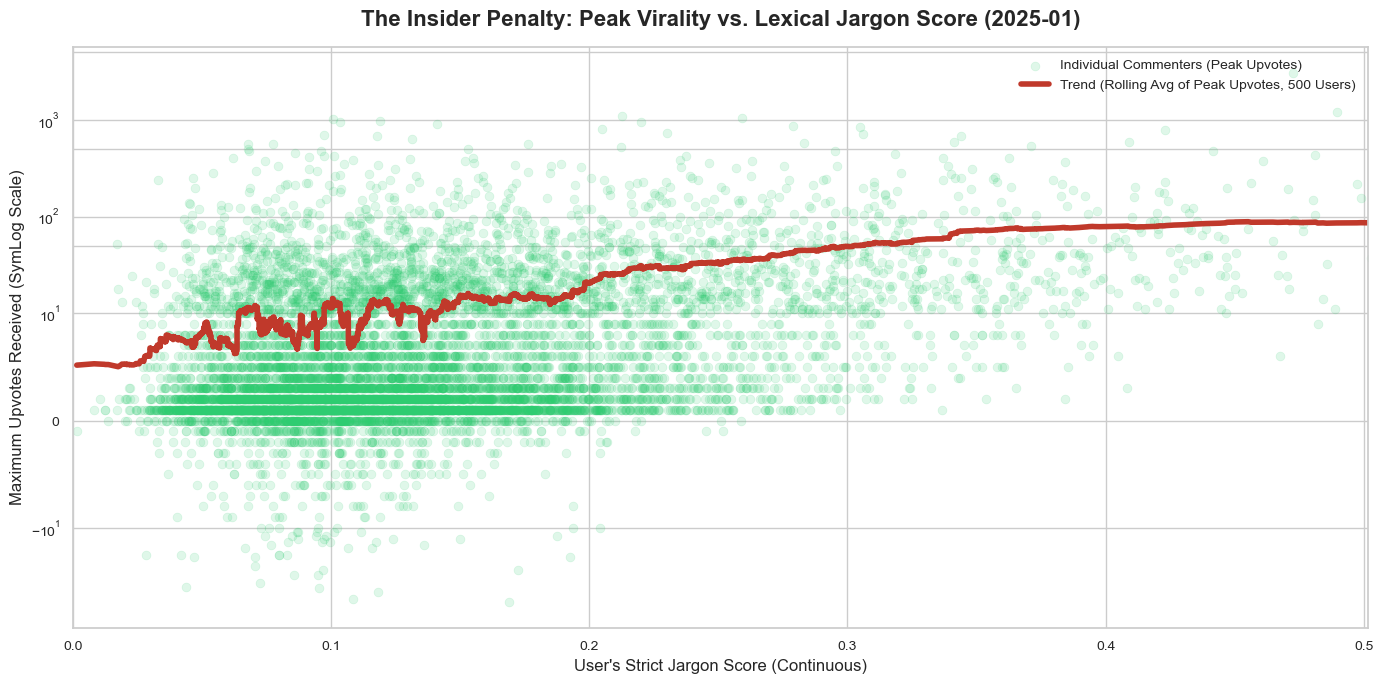

In [94]:
# 1. Setup paths



print("Extracting max upvotes and aggregating text by Author...")

# 2. Extract unique users, their max upvotes, and their aggregated long comments
query = f"""
    WITH user_data AS (
        SELECT 
            author,
            MAX(score) as peak_upvotes,
            COUNT(*) as num_long_comments,
            STRING_AGG(lower(regexp_replace(body, '[^a-zA-Z]', ' ', 'g')), ' ') as aggregated_text
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
          AND body IS NOT NULL AND body NOT IN ('[deleted]', '[removed]')
          AND author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
          AND length(body) > 300 
        GROUP BY author
    )
    SELECT * FROM user_data
    ORDER BY num_long_comments DESC
    LIMIT 25000
"""

df_users = con.execute(query).df()
print(f"Sampled {len(df_users)} unique commenters. Calculating User Lexical Scores...\n")

# 3. Vectorize and Score the Users
vectorizer = CountVectorizer(vocabulary=vocab)
user_matrix = vectorizer.fit_transform(df_users['aggregated_text'])
similarities = cosine_similarity(user_matrix, corpus_counts)
df_users['lexical_insider_score'] = similarities.flatten()

# 4. Filter out the absolute zeros to clean the noise
df_signal = df_users[df_users['lexical_insider_score'] > 0.0].copy()

# 5. Sort continuously and calculate a rolling average for the trendline
df_signal = df_signal.sort_values('lexical_insider_score')
# A 500-user rolling window smoothing out the peak_upvotes
df_signal['rolling_avg_peak_upvotes'] = df_signal['peak_upvotes'].rolling(window=500, min_periods=100, center=True).mean()

# 6. Plotting
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Plot the raw scatter of all users
sns.scatterplot(
    data=df_signal,
    x='lexical_insider_score',
    y='peak_upvotes',
    alpha=0.15,
    color='#2ecc71',
    edgecolor=None,
    s=40,
    label='Individual Commenters (Peak Upvotes)'
)

# Overlay the continuous trendline
plt.plot(
    df_signal['lexical_insider_score'], 
    df_signal['rolling_avg_peak_upvotes'], 
    color='#c0392b', 
    linewidth=4, 
    label='Trend (Rolling Avg of Peak Upvotes, 500 Users)'
)

# Use SymLog to handle huge positive variance and negative upvote counts
plt.yscale('symlog', linthresh=10)
plt.yticks([-10, 0, 10, 50, 100, 500, 1000, 5000])

plt.title(f"The Insider Penalty: Peak Virality vs. Lexical Jargon Score ({TARGET_MONTH})", fontsize=16, pad=15)
plt.xlabel("User's Strict Jargon Score (Continuous)", fontsize=12)
plt.ylabel("Maximum Upvotes Received (SymLog Scale)", fontsize=12)

# Dynamic X limit to cut off empty whitespace
plt.xlim(0, df_signal['lexical_insider_score'].quantile(0.999))

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [95]:
ANOMALY_MONTH = '2022-08'

# 1. Setup paths and load the baseline vocabulary for Aug 2022 using semantic stop-words
BASELINE_CSV_2022 = f'{BASE}lexical_baseline_{ANOMALY_MONTH}.csv'
df_base_2022 = pd.read_csv(BASELINE_CSV_2022)
custom_stops_2022 = set(ENGLISH_STOP_WORDS).union({
    'just', 'like', 'don', 'people', 'think', 'know', 'really', 'make', 'did', 'does',
    'reddit', 'sub', 'conspiracy', 'post', 'comment', 'http', 'https', 'com', 'www',
    've', 'll', 're', 'didn', 'doesn', 'going', 'say', 'way', 'got', 'right', 'good', 'time'
})
df_jargon_2022 = df_base_2022[~df_base_2022['word'].isin(custom_stops_2022)].copy()
vocab_2022 = df_jargon_2022['word'].tolist()
corpus_counts_2022 = df_jargon_2022['term_frequency'].values.reshape(1, -1)

print(f"Extracting Upvote Tiers for the {ANOMALY_MONTH} Anomaly...")

query = f"""
    WITH all_month AS (
        SELECT 
            score,
            lower(regexp_replace(body, '[^a-zA-Z]', ' ', 'g')) as clean_body,
            CASE 
                WHEN score < 1 THEN '01: Downvoted (<1)'
                WHEN score BETWEEN 1 AND 10 THEN '02: Normal (1-10)'
                WHEN score BETWEEN 11 AND 50 THEN '03: Good (11-50)'
                WHEN score BETWEEN 51 AND 100 THEN '04: Great (51-100)'
                WHEN score BETWEEN 101 AND 200 THEN '05: Breakout (101-200)'
                WHEN score BETWEEN 201 AND 500 THEN '06: Viral (201-500)'
                WHEN score > 500 THEN '07: Mega-Viral (500+)'
            END as upvote_tier,
            RANDOM() as rnd
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{ANOMALY_MONTH}'
          AND body IS NOT NULL AND body NOT IN ('[deleted]', '[removed]')
          AND length(body) > 300 
    ),
    sampled AS (
        SELECT * FROM (
            SELECT *, ROW_NUMBER() OVER(PARTITION BY upvote_tier ORDER BY rnd) as rn 
            FROM all_month
        )
        WHERE rn <= 2500
    )
    SELECT upvote_tier, score, clean_body 
    FROM sampled
    ORDER BY upvote_tier
"""

df_sample = con.execute(query).df()

vectorizer = CountVectorizer(vocabulary=vocab_2022)
user_matrix = vectorizer.fit_transform(df_sample['clean_body'])
similarities = cosine_similarity(user_matrix, corpus_counts_2022)
df_sample['lexical_insider_score'] = similarities.flatten()

# Filter out absolute zeros
df_signal = df_sample[df_sample['lexical_insider_score'] > 0.0].copy()

summary = df_signal.groupby('upvote_tier').agg(
    comments_analyzed=('score', 'count'),
    median_score=('lexical_insider_score', 'median')
).reset_index()

print(f"=== Lexical Collapse During the {ANOMALY_MONTH} Anomaly ===")
print(summary.to_string(index=False))


Extracting Upvote Tiers for the 2022-08 Anomaly...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== Lexical Collapse During the 2022-08 Anomaly ===
           upvote_tier  comments_analyzed  median_score
    01: Downvoted (<1)               2500         0.106
     02: Normal (1-10)               2500         0.116
      03: Good (11-50)               2500         0.101
    04: Great (51-100)                660         0.102
05: Breakout (101-200)                242         0.101
   06: Viral (201-500)                109         0.098
 07: Mega-Viral (500+)                 30         0.094


Vectorizer calibrated with 3,189 verified epistemic terms.

Extracting all regular commenters (5+ total comments) and measuring Consistency...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Isolated 9625 regular commenters. Scoring and plotting...



=== Does Consistent Approval Require Epistemic Alignment? (2025-01)
(Scored exclusively on Cross-Corpus Keyness) ===
             consistency_archetype  user_count  avg_lexical_score  median_lexical_score
01: Highly Consistent (Median 10+)         228              0.175                 0.164
  02: Solidly Upvoted (Median 5-9)         721              0.200                 0.195
03: Baseline Regulars (Median 2-4)        3815              0.236                 0.221
04: Frequently Ignored (Median <2)        4860              0.223                 0.213




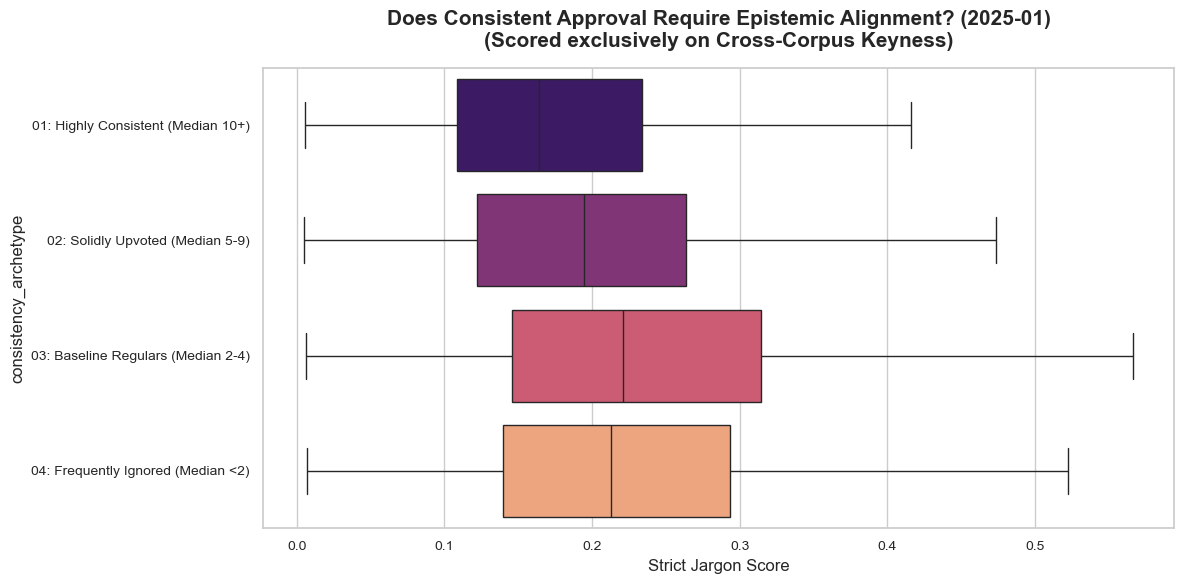

In [96]:
# 1. Setup paths
KEYNESS_CSV = f'{BASE}lexical_keyness_{TARGET_MONTH}.csv'
df_keyness = pd.read_csv(KEYNESS_CSV)

# 2. ISOLATE THE TRUE JARGON
# Must be used 2x more than standard Reddit, and occur at least 10 times to filter out typos
df_jargon = df_keyness[(df_keyness['keyness_ratio'] > 2.0) & (df_keyness['term_frequency'] > 10)].copy()

keyness_vocab = df_jargon['word'].tolist()
keyness_counts = df_jargon['term_frequency'].values.reshape(1, -1)
print(f"Vectorizer calibrated with {len(keyness_vocab):,} verified epistemic terms.\n")

print("Extracting all regular commenters (5+ total comments) and measuring Consistency...")

# 3. Extract users, aggregating ALL their comments
query = f"""
    WITH user_stats AS (
        SELECT 
            author,
            COUNT(*) as total_comments,
            MAX(score) as peak_upvotes,
            MEDIAN(score) as median_upvotes,
            STRING_AGG(lower(regexp_replace(body, '[^a-zA-Z]', ' ', 'g')), ' ') as aggregated_text
        FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
          AND body IS NOT NULL AND body NOT IN ('[deleted]', '[removed]')
          AND author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
        GROUP BY author
        -- 5+ comments to establish a valid median upvote count
        -- Total combined text must be at least 150 characters
        HAVING COUNT(*) >= 5
           AND length(STRING_AGG(body, ' ')) > 150
    )
    SELECT * FROM user_stats
"""

df_users = con.execute(query).df()
print(f"Isolated {len(df_users)} regular commenters. Scoring and plotting...\n")

def consistency_tier(row):
    if row['median_upvotes'] >= 10:
        return '01: Highly Consistent (Median 10+)'
    elif row['median_upvotes'] >= 5:
        return '02: Solidly Upvoted (Median 5-9)'
    elif row['median_upvotes'] >= 2:
        return '03: Baseline Regulars (Median 2-4)'
    else:
        return '04: Frequently Ignored (Median <2)'

df_users['consistency_archetype'] = df_users.apply(consistency_tier, axis=1)

df_signal = score_and_boxplot(
    df=df_users,
    text_col='aggregated_text',
    group_col='consistency_archetype',
    title=f"Does Consistent Approval Require Epistemic Alignment? ({TARGET_MONTH})\n(Scored exclusively on Cross-Corpus Keyness)",
    palette='magma',
    custom_vocab=keyness_vocab,
    custom_counts=keyness_counts
)


Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/df_users_live.csv


=== One-Hit Wonders vs. Consistent Performers (2025-01) ===
                        user_archetype  user_count  avg_lexical_score  median_lexical_score
    01: Consistent Stars (3+ Big Hits)          28              0.348                 0.361
02: One-Hit Wonders (1 Viral Hit >100)         139              0.262                 0.250
       03: Minor One-Hit Wonders (>50)         192              0.252                 0.242
        04: Solid Regulars (Max 10-49)        1035              0.235                 0.219
                05: Ignored (Max < 10)        1462              0.200                 0.191




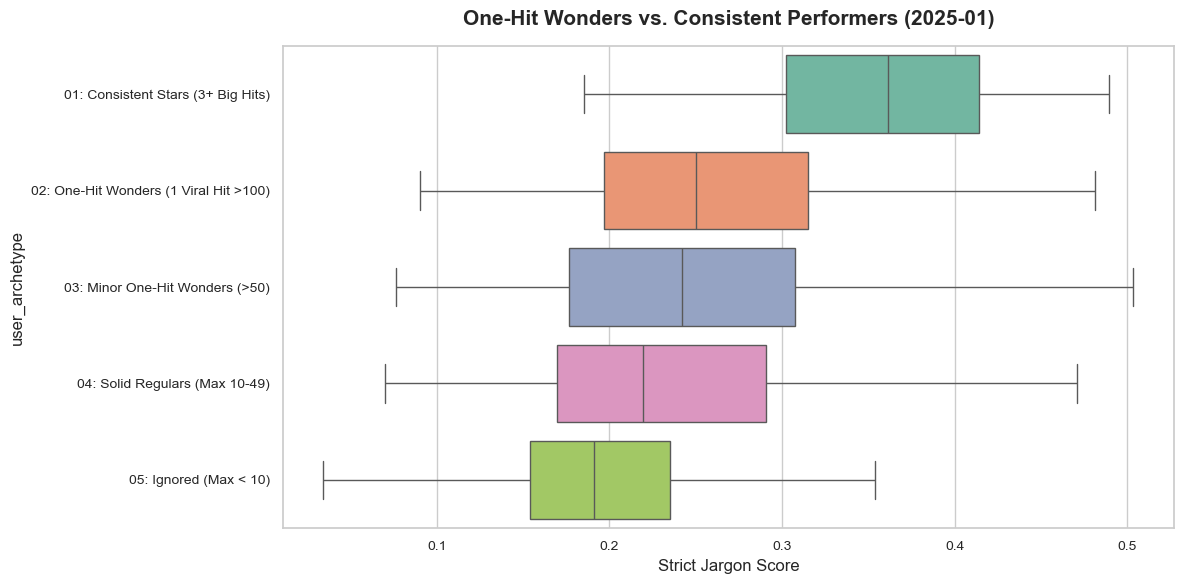

In [97]:
# 1. Setup paths and load cache if exists
ARCHETYPE_CACHE = BASE + "df_users_live.csv"
query = f"""
    WITH user_data AS (
        SELECT
            author,
            COUNT(*) as total_long_comments,
            MAX(score) as peak_upvotes,
            MEDIAN(score) as median_upvotes,
            SUM(CASE WHEN score >= 50 THEN 1 ELSE 0 END) as big_hits,
            STRING_AGG(lower(regexp_replace(body, '[^a-zA-Z]', ' ', 'g')), ' ') as aggregated_text
        FROM read_json_auto('{COMMENTS_GLOB}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
          AND body IS NOT NULL AND body NOT IN ('[deleted]', '[removed]')
          AND author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
          AND length(body) > 300
        GROUP BY author
        HAVING COUNT(*) >= 3
    )
    SELECT * FROM user_data
"""
df_users_arch = cached_query_csv(con, ARCHETYPE_CACHE, query)

def categorize_user(row):
    if row['big_hits'] >= 3:
        return '01: Consistent Stars (3+ Big Hits)'
    elif row['peak_upvotes'] >= 100 and row['big_hits'] == 1:
        return '02: One-Hit Wonders (1 Viral Hit >100)'
    elif row['peak_upvotes'] >= 50 and row['big_hits'] == 1:
        return '03: Minor One-Hit Wonders (>50)'
    elif row['peak_upvotes'] >= 10 and row['big_hits'] == 0:
        return '04: Solid Regulars (Max 10-49)'
    else:
        return '05: Ignored (Max < 10)'

df_users_arch['user_archetype'] = df_users_arch.apply(categorize_user, axis=1)

df_signal_arch = score_and_boxplot(
    df=df_users_arch,
    text_col='aggregated_text',
    group_col='user_archetype',
    title=f"One-Hit Wonders vs. Consistent Performers ({TARGET_MONTH})",
    palette='Set2'
)


Extracting Active Users (10+ comments) and measuring Consistency...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Isolated 688 active regulars. Scoring and plotting...



=== Does the Community Consistently Reward Insiders? (2025-01)
(Filtering out One-Hit Wonders & Tourists) ===
             consistency_archetype  user_count  avg_lexical_score  median_lexical_score
01: Highly Consistent (Median 10+)           6              0.252                 0.268
  02: Solidly Upvoted (Median 5-9)          38              0.313                 0.311
03: Baseline Regulars (Median 2-4)         285              0.329                 0.323
04: Frequently Ignored (Median <2)         359              0.319                 0.313




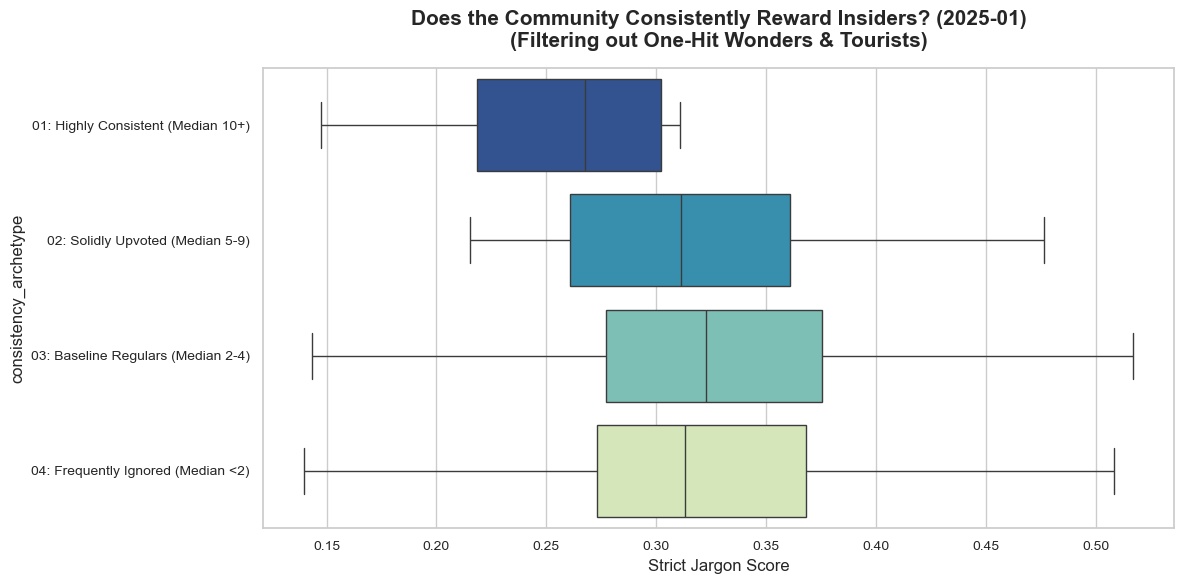

In [98]:
print("Extracting Active Users (10+ comments) and measuring Consistency...")
query = f"""
    WITH user_stats AS (
        SELECT 
            author,
            COUNT(*) as total_comments,
            MAX(score) as peak_upvotes,
            MEDIAN(score) as median_upvotes,
            STRING_AGG(lower(regexp_replace(body, '[^a-zA-Z]', ' ', 'g')), ' ') as aggregated_text
        FROM read_json_auto('{COMMENTS_GLOB}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
          AND body IS NOT NULL AND body NOT IN ('[deleted]', '[removed]')
          AND author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
          AND length(body) > 300 
        GROUP BY author
        -- STRICT ACTIVITY FLOOR: 10+ long comments to establish a valid median
        HAVING COUNT(*) >= 10
    )
    SELECT * FROM user_stats
"""
df_users_stair_10 = con.execute(query).df()
print(f"Isolated {len(df_users_stair_10)} active regulars. Scoring and plotting...\n")

def consistency_tier(row):
    if row['median_upvotes'] >= 10:
        return '01: Highly Consistent (Median 10+)'
    elif row['median_upvotes'] >= 5:
        return '02: Solidly Upvoted (Median 5-9)'
    elif row['median_upvotes'] >= 2:
        return '03: Baseline Regulars (Median 2-4)'
    else:
        return '04: Frequently Ignored (Median <2)'

df_users_stair_10['consistency_archetype'] = df_users_stair_10.apply(consistency_tier, axis=1)

df_signal_stair_10 = score_and_boxplot(
    df=df_users_stair_10,
    text_col='aggregated_text',
    group_col='consistency_archetype',
    title=f"Does the Community Consistently Reward Insiders? ({TARGET_MONTH})\n(Filtering out One-Hit Wonders & Tourists)",
    palette='YlGnBu_r'
)


Extracting Regular Users (5+ paragraphs) and measuring Consistency...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Isolated 3498 regular commenters. Scoring and plotting...



=== The 'Middle Class' of r/conspiracy (2025-01)
Does consistent upvoting require insider language? ===
             consistency_archetype  user_count  avg_lexical_score  median_lexical_score
01: Highly Consistent (Median 10+)          89              0.191                 0.186
  02: Solidly Upvoted (Median 5-9)         308              0.223                 0.207
03: Baseline Regulars (Median 2-4)        1356              0.249                 0.232
04: Frequently Ignored (Median <2)        1745              0.237                 0.221




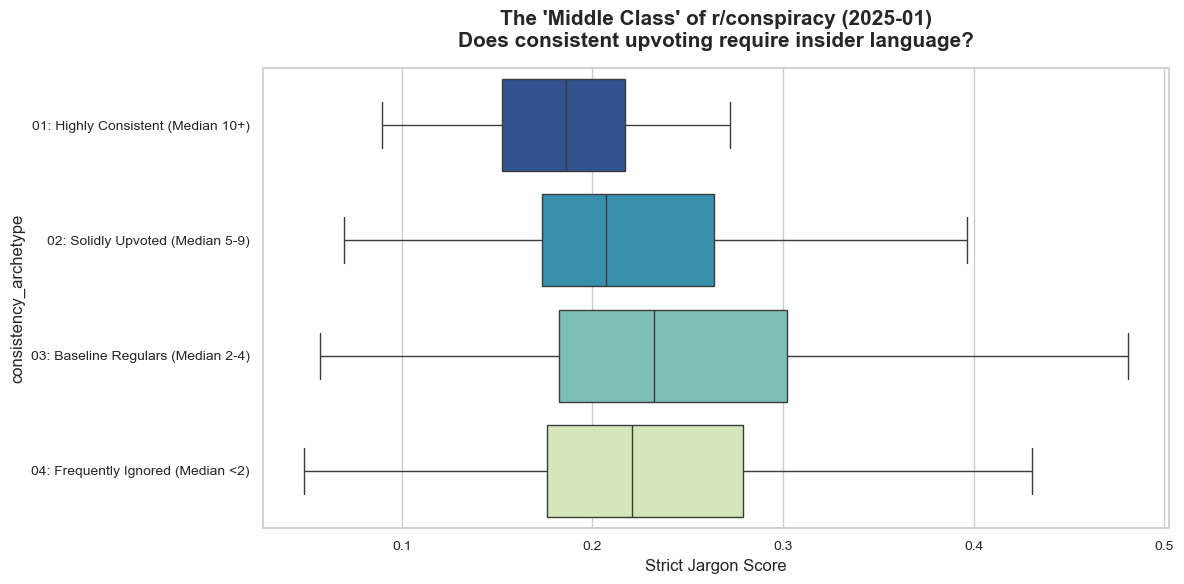

In [99]:
print("Extracting Regular Users (5+ paragraphs) and measuring Consistency...")
query = f"""
    WITH user_stats AS (
        SELECT 
            author,
            COUNT(*) as total_paragraphs,
            MAX(score) as peak_upvotes,
            MEDIAN(score) as median_upvotes,
            STRING_AGG(lower(regexp_replace(body, '[^a-zA-Z]', ' ', 'g')), ' ') as aggregated_text
        FROM read_json_auto('{COMMENTS_GLOB}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
          AND body IS NOT NULL AND body NOT IN ('[deleted]', '[removed]')
          AND author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
          -- RELAXED LENGTH: >150 chars (~25 words, a standard paragraph)
          AND length(body) > 150 
        GROUP BY author
        -- RELAXED ACTIVITY: 5+ comments to establish a median
        HAVING COUNT(*) >= 5
    )
    SELECT * FROM user_stats
"""
df_users_stair_5p = con.execute(query).df()
print(f"Isolated {len(df_users_stair_5p)} regular commenters. Scoring and plotting...\n")

def consistency_tier(row):
    if row['median_upvotes'] >= 10:
        return '01: Highly Consistent (Median 10+)'
    elif row['median_upvotes'] >= 5:
        return '02: Solidly Upvoted (Median 5-9)'
    elif row['median_upvotes'] >= 2:
        return '03: Baseline Regulars (Median 2-4)'
    else:
        return '04: Frequently Ignored (Median <2)'

df_users_stair_5p['consistency_archetype'] = df_users_stair_5p.apply(consistency_tier, axis=1)

df_signal_stair_5p = score_and_boxplot(
    df=df_users_stair_5p,
    text_col='aggregated_text',
    group_col='consistency_archetype',
    title=f"The 'Middle Class' of r/conspiracy ({TARGET_MONTH})\nDoes consistent upvoting require insider language?",
    palette='YlGnBu_r'
)


Extracting all commenters (5+ total comments) and measuring Consistency...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Isolated 9625 regular commenters. Scoring and plotting...



=== Upvote Consistency vs. Community Jargon (2025-01)
(All comments included) ===
             consistency_archetype  user_count  avg_lexical_score  median_lexical_score
01: Highly Consistent (Median 10+)         228              0.139                 0.134
  02: Solidly Upvoted (Median 5-9)         721              0.164                 0.154
03: Baseline Regulars (Median 2-4)        3815              0.196                 0.176
04: Frequently Ignored (Median <2)        4861              0.186                 0.168




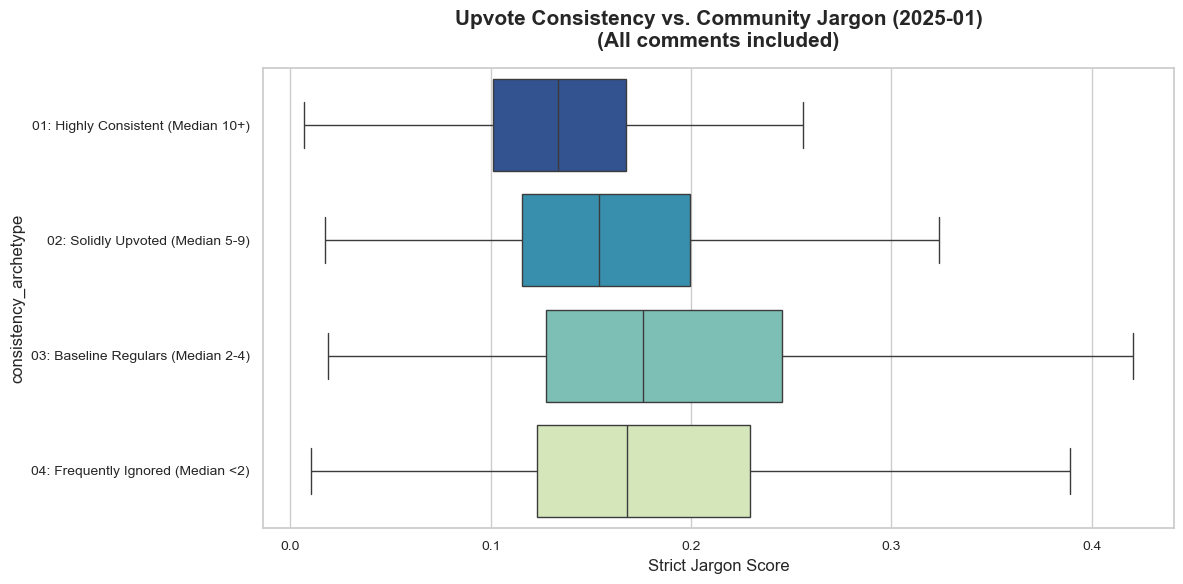

In [100]:
print("Extracting all commenters (5+ total comments) and measuring Consistency...")
query = f"""
    WITH user_stats AS (
        SELECT 
            author,
            COUNT(*) as total_comments,
            MAX(score) as peak_upvotes,
            MEDIAN(score) as median_upvotes,
            STRING_AGG(lower(regexp_replace(body, '[^a-zA-Z]', ' ', 'g')), ' ') as aggregated_text
        FROM read_json_auto('{COMMENTS_GLOB}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
          AND body IS NOT NULL AND body NOT IN ('[deleted]', '[removed]')
          AND author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
        GROUP BY author
        -- 5+ comments to establish a valid median
        -- Total combined text must be at least 150 characters
        HAVING COUNT(*) >= 5
           AND length(STRING_AGG(body, ' '))
    )
    SELECT * FROM user_stats
"""
# Wait, the query string was split, let's complete the query and load code:
query = f"""
    WITH user_stats AS (
        SELECT 
            author,
            COUNT(*) as total_comments,
            MAX(score) as peak_upvotes,
            MEDIAN(score) as median_upvotes,
            STRING_AGG(lower(regexp_replace(body, '[^a-zA-Z]', ' ', 'g')), ' ') as aggregated_text
        FROM read_json_auto('{COMMENTS_GLOB}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
          AND body IS NOT NULL AND body NOT IN ('[deleted]', '[removed]')
          AND author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
        GROUP BY author
        -- 5+ comments to establish a valid median
        -- Total combined text must be at least 150 characters
        HAVING COUNT(*) >= 5
           AND length(STRING_AGG(body, ' ')) > 150
    )
    SELECT * FROM user_stats
"""
df_users_stair_5c = con.execute(query).df()
print(f"Isolated {len(df_users_stair_5c)} regular commenters. Scoring and plotting...\n")

def consistency_tier(row):
    if row['median_upvotes'] >= 10:
        return '01: Highly Consistent (Median 10+)'
    elif row['median_upvotes'] >= 5:
        return '02: Solidly Upvoted (Median 5-9)'
    elif row['median_upvotes'] >= 2:
        return '03: Baseline Regulars (Median 2-4)'
    else:
        return '04: Frequently Ignored (Median <2)'

df_users_stair_5c['consistency_archetype'] = df_users_stair_5c.apply(consistency_tier, axis=1)

df_signal_stair_5c = score_and_boxplot(
    df=df_users_stair_5c,
    text_col='aggregated_text',
    group_col='consistency_archetype',
    title=f"Upvote Consistency vs. Community Jargon ({TARGET_MONTH})\n(All comments included)",
    palette='YlGnBu_r'
)


In [101]:
# Flashpoint vs Inward-Facing (control) thread sets for the divergence plot below.
# The original selection cell was lost; this pins a documented, reproducible rule:
#   flashpoints = the 3 most-commented threads of TARGET_MONTH (>200 comments),
#                 matching the preserved output of the original 2025-01 run
#                 (t3_1i614xr, t3_1icexy9, t3_1i6x8ol)
#   controls    = 10 mid-size threads (50-200 comments) sampled with a fixed seed,
#                 i.e. active community threads that never went viral
THREAD_SETS_CSV = BASE + f'flashpoint_control_threads_{TARGET_MONTH}.csv'

if os.path.exists(THREAD_SETS_CSV):
    df_thread_sets = pd.read_csv(THREAD_SETS_CSV)
    print(f"Loaded pinned thread sets from {THREAD_SETS_CSV}")
else:
    thread_counts = con.execute(f"""
        SELECT link_id, COUNT(*) as comment_count
        FROM read_json_auto('{COMMENTS_GLOB}', maximum_object_size=50000000, union_by_name=True)
        WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
        GROUP BY link_id
    """).df()

    flashpoints = (thread_counts[thread_counts['comment_count'] > 200]
                   .nlargest(3, 'comment_count').assign(role='flashpoint'))
    controls = (thread_counts[thread_counts['comment_count'].between(50, 200)]
                .sample(n=10, random_state=42).assign(role='control'))

    df_thread_sets = pd.concat([flashpoints, controls], ignore_index=True)
    df_thread_sets.to_csv(THREAD_SETS_CSV, index=False)
    print(f"Computed and pinned thread sets to {THREAD_SETS_CSV}")

flashpoint_threads = df_thread_sets.loc[df_thread_sets['role'] == 'flashpoint', 'link_id'].tolist()
control_threads = df_thread_sets.loc[df_thread_sets['role'] == 'control', 'link_id'].tolist()
print(df_thread_sets[['link_id', 'comment_count', 'role']])


Loaded pinned thread sets from /Users/nash/Projects/ConspiracyComments/data/processed/flashpoint_control_threads_2025-01.csv
       link_id  comment_count        role
0   t3_1i614xr           3035  flashpoint
1   t3_1icexy9           1986  flashpoint
2   t3_1i6x8ol           1399  flashpoint
3   t3_1i6kl9x             79     control
4   t3_1i7pwyv            136     control
5   t3_1i8yqsh             98     control
6   t3_1hqtt58             90     control
7   t3_1i11lxz             54     control
8   t3_1hs2ezm             87     control
9   t3_1hzc616            156     control
10  t3_1i3krk1             76     control
11  t3_1ib9t6e             51     control
12  t3_1hwwj61            105     control


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

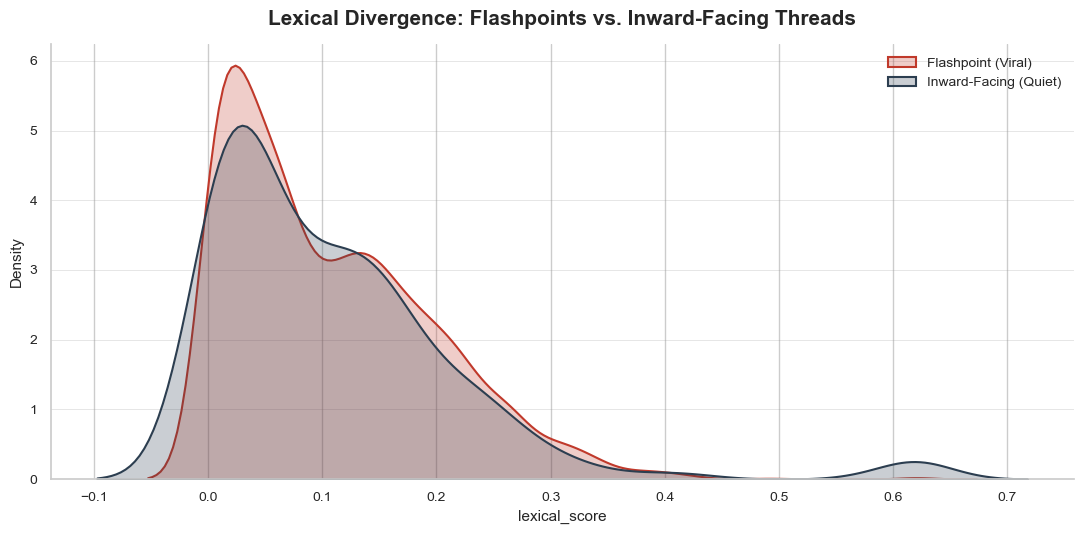

In [102]:
# 1. Load Vocab
df_base = pd.read_csv(f'{BASE}lexical_baseline_{TARGET_MONTH}.csv')
vocab = df_base.head(5000)['word'].tolist()
corpus_counts = df_base.head(5000)['term_frequency'].values.reshape(1, -1)
vectorizer = CountVectorizer(vocabulary=vocab)

# 1. Pull ALL thread data in ONE query
all_threads = list(flashpoint_threads) + list(control_threads)
thread_str = ",".join([f"'{t}'" for t in all_threads])

# This does the heavy lifting in one scan of the JSONL file
query = f"""
    SELECT link_id, author, STRING_AGG(body, ' ') as aggregated_text
    FROM read_json_auto('{COMMENTS_GLOB}', maximum_object_size=50000000, union_by_name=True)
    WHERE link_id IN ({thread_str})
    GROUP BY link_id, author
"""
df_all = con.execute(query).df()

# 2. Score everything in one vectorization pass
user_matrix = vectorizer.transform(df_all['aggregated_text'])
scores = cosine_similarity(user_matrix, corpus_counts).flatten()
df_all['lexical_score'] = scores

# 3. Split back out for plotting
flashpoint_scores = df_all[df_all['link_id'].isin(flashpoint_threads)]['lexical_score']
control_scores = df_all[df_all['link_id'].isin(control_threads)]['lexical_score']

import utils.visualization as viz
viz.plot_lexical_divergence(flashpoint_scores, control_scores)

In [103]:
# 1. Setup paths and load cache if exists
RANKINGS_CACHE = BASE + "df_rankings_live.csv"
query = f"""
    SELECT
        author,
        COUNT(*) as total_comment_volume,
        STRING_AGG(body, ' ') as aggregated_text
    FROM read_json_auto('{COMMENTS_GLOB}', maximum_object_size=50000000, union_by_name=True)
    WHERE strftime(to_timestamp(created_utc), '%Y-%m') = '{TARGET_MONTH}'
      AND body IS NOT NULL AND body NOT IN ('[deleted]', '[removed]')
      AND author NOT IN ('[deleted]', '[removed]', 'AutoModerator')
    GROUP BY author
    HAVING COUNT(*) > 2 -- Filter out true one-offs to stabilize the score
"""

def _score_lexical_convergence(df):
    user_matrix = vectorizer.transform(df['aggregated_text'])
    df['lexical_score'] = cosine_similarity(user_matrix, corpus_counts).flatten()
    return df

df_rankings = cached_query_csv(con, RANKINGS_CACHE, query, postprocess=_score_lexical_convergence)

# Define insider weight based on the lexical score
df_rankings['insider_weight'] = df_rankings['lexical_score']
print(f"df_rankings loaded/calculated successfully. Shape: {df_rankings.shape}")


Loading cached result from /Users/nash/Projects/ConspiracyComments/data/processed/df_rankings_live.csv


df_rankings loaded/calculated successfully. Shape: (20283, 6)


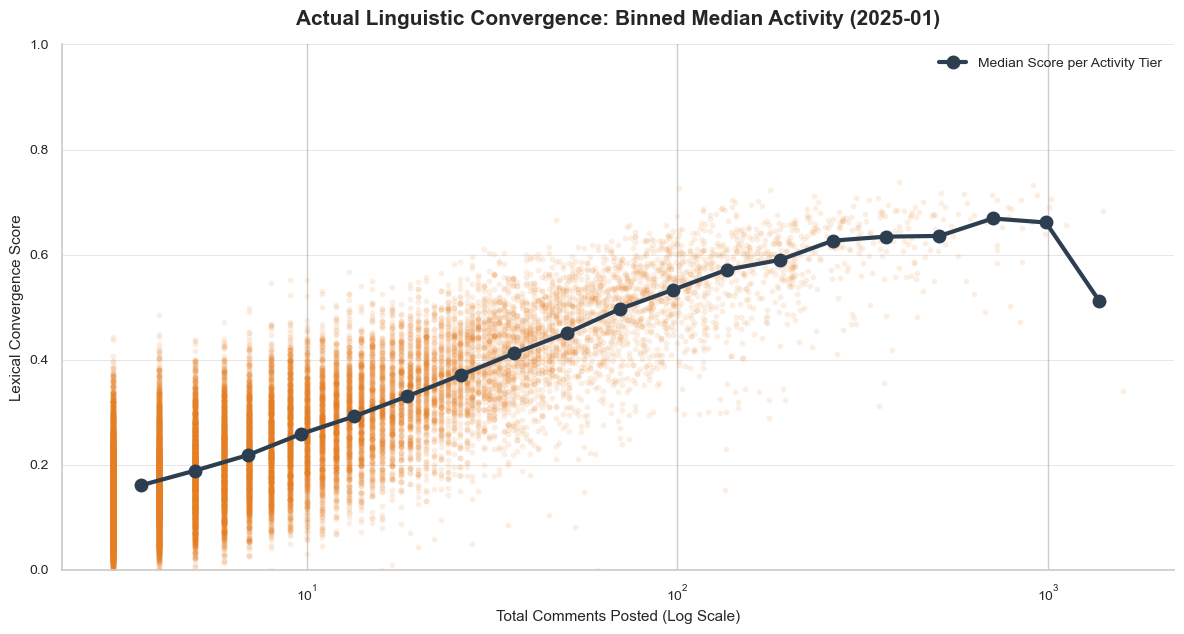

In [104]:
# 1. Create bins for the comment volume (Logarithmic binning)
# This creates bins that get wider as volume increases
bins = np.logspace(np.log10(df_rankings['total_comment_volume'].min()), 
                   np.log10(df_rankings['total_comment_volume'].max()), 20)

df_rankings['bin'] = pd.cut(df_rankings['total_comment_volume'], bins=bins)

# 2. Calculate median score per bin
binned_data = df_rankings.groupby('bin', observed=True)['lexical_score'].median().reset_index()
# Get the midpoint of each bin for plotting
binned_data['bin_mid'] = [b.mid for b in binned_data['bin']]

import utils.visualization as viz
viz.plot_binned_linguistic_gravity(df_rankings, binned_data, TARGET_MONTH)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

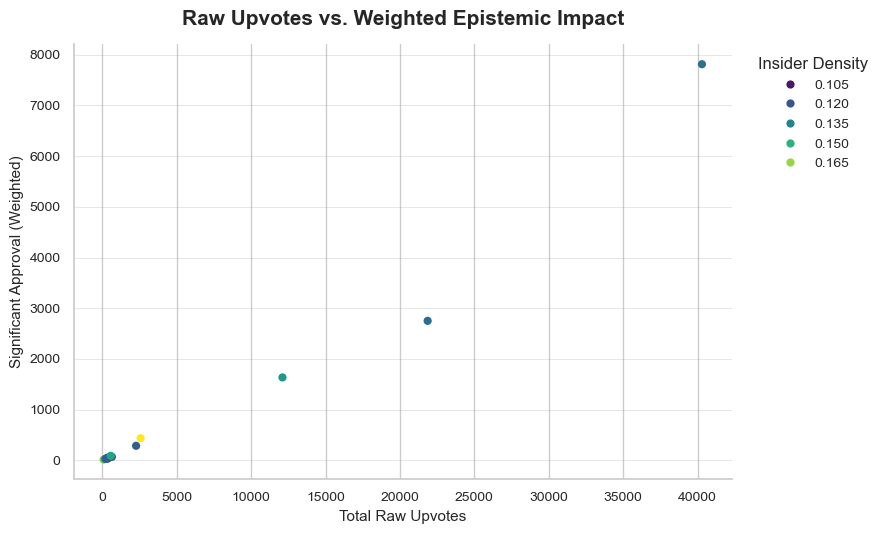

In [105]:
thread_str = ",".join([f"'{t}'" for t in all_threads])

# 1. Update the query to include 'score'
query = f"""
    SELECT link_id, author, body as score_body_proxy, score
    FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
    WHERE link_id IN ({thread_str})
"""

# Note: We keep the raw body here to do the aggregation separately if needed, 
# but we must ensure 'score' is in the resulting dataframe.
df_raw_data = con.execute(query).df()

# 2. Merge user weights
df_weighted_impact = df_raw_data.merge(df_rankings[['author', 'insider_weight']], on='author', how='left')

# 3. Calculate "Significant Approval" 
# Ensure we fill NaN weights for authors not in rankings (e.g., deleted users) with a baseline of 0.1
df_weighted_impact['insider_weight'] = df_weighted_impact['insider_weight'].fillna(0.1)

# Now 'score' exists, so this will work:
df_weighted_impact['significant_upvotes'] = df_weighted_impact['score'].clip(lower=0) * df_weighted_impact['insider_weight']

# 4. Grouping by link_id
thread_significance = df_weighted_impact.groupby('link_id').agg(
    total_raw_upvotes=('score', 'sum'),
    weighted_epistemic_impact=('significant_upvotes', 'sum'),
    insider_density=('insider_weight', 'mean')
).reset_index()

import utils.visualization as viz
viz.plot_epistemic_impact(thread_significance)

In [106]:
# 1. Calculate the "Epistemic Excess"
# We define this as the residual: how much the weighted impact exceeds the simple linear trend
import statsmodels.api as sm

X = thread_significance['total_raw_upvotes']
y = thread_significance['weighted_epistemic_impact']
model = sm.OLS(y, sm.add_constant(X)).fit()
thread_significance['expected_impact'] = model.predict(sm.add_constant(X))
thread_significance['epistemic_excess'] = thread_significance['weighted_epistemic_impact'] - thread_significance['expected_impact']

# 2. Extract the top 10 "Gold Standard" threads
top_excess_threads = thread_significance.sort_values('epistemic_excess', ascending=False).head(10)
thread_ids = top_excess_threads['link_id'].tolist()
thread_str = "'" + "','".join(thread_ids) + "'"

# 3. Pull the content of these high-impact threads
content_query = f"""
    SELECT link_id, author, body, score
    FROM read_json_auto('{COMMENTS_GLOB}', maximum_object_size=50000000, union_by_name=True)
    WHERE link_id IN ({thread_str})
    ORDER BY link_id, score DESC
"""
df_gold_standard = con.execute(content_query).df()

# 4. Print them for your review
for tid in thread_ids:
    print(f"\n{'='*20} THREAD: {tid} {'='*20}")
    print(f"Excess Impact Score: {top_excess_threads[top_excess_threads['link_id'] == tid]['epistemic_excess'].values[0]:.2f}")
    subset = df_gold_standard[df_gold_standard['link_id'] == tid]
    # Print the highest-voted comment in this high-impact thread
    print(f"Top Comment: {subset.iloc[0]['body'][:500]}...")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


==================== THREAD: t3_1i614xr ====================
Excess Impact Score: 694.15
Top Comment: Is there a video of it?  I assume the video shows the full motion of his arm, which would be easier to decipher the meaning of his gesture…...

==================== THREAD: t3_1i11lxz ====================
Excess Impact Score: 107.85
Top Comment: There’s no way in hell we went a couple times 50 years ago only to never go back again 🤦 lost technology?
Waste of money?

Gimme a break...

==================== THREAD: t3_1i8yqsh ====================
Excess Impact Score: 98.26
Top Comment: Mexican with an expired green card = bad

Asian to steal your job at Telsa with H1-b = good...

==================== THREAD: t3_1i3krk1 ====================
Excess Impact Score: 97.61
Top Comment: Joe Rogan is just a rugged version of Anderson Cooper... edgy, different, and tailored for another crowd.


But whether you’re tuning into CNN or YouTube, listening to Rogan or Cooper, it’s the same mainstream na

---
### 9.9 Epistemic Strategy vs Social Capital

Uses the top "epistemic excess" threads (cell above) as a gold-standard sample. Correlates lexicon dimension counts with upvotes at comment and author level.

**Run order:** epistemic-excess selection → correlation heatmap → author aggregation → power-user scatter grid.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

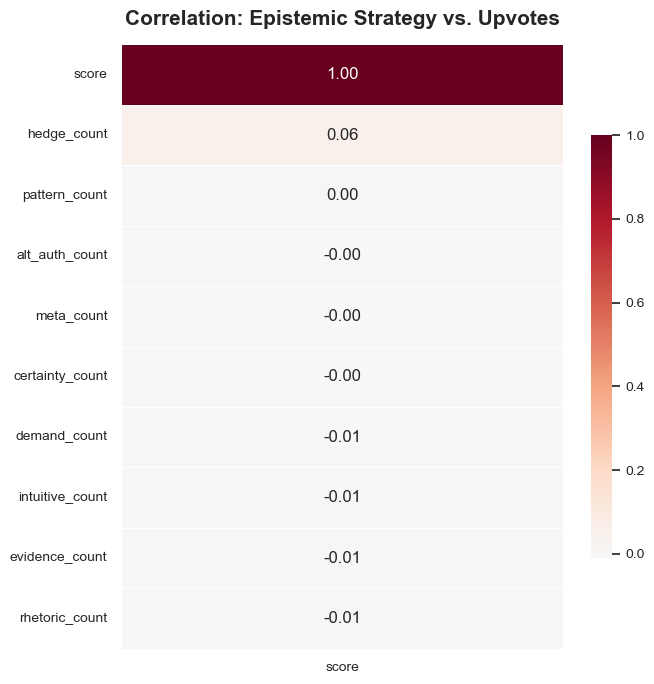

In [107]:
import re
from utils.epistemic_lexicon import lex
thread_str = ",".join([f"'{t}'" for t in all_threads])
# Build dimension word sets from externalized lexicon (see Section 9.1)
dimensions = {
    name: set(w.lower().replace("_", " ") for w in lex.get(key, []))
    for name, key in [
        ("evidence", "evidence"),
        ("rhetoric", "adversarial"),
        ("hedge", "hedge"),
        ("certainty", "certainty"),
        ("alt_auth", "alt_authority"),
        ("intuitive", "intuitive"),
        ("pattern", "pattern"),
        ("meta", "meta"),
        ("demand", "demand"),
    ]
}
patterns = dimensions  # alias for downstream cells

# Requires `thread_str` from the epistemic-excess cell above
query = f"""
    SELECT author, body, score
    FROM read_json_auto('{RAW_COMMENTS}', maximum_object_size=50000000, union_by_name=True)
    WHERE link_id IN ({thread_str})
"""
df_raw = con.execute(query).df()

def count_dimension_matches(text, word_set):
    if not isinstance(text, str):
        return 0
    words = set(re.findall(r'\b\w+\b', text.lower()))
    return len(words.intersection(word_set))

for dim_name, word_set in dimensions.items():
    df_raw[f'{dim_name}_count'] = df_raw['body'].apply(lambda x: count_dimension_matches(x, word_set))

corr_matrix = df_raw[[f'{d}_count' for d in dimensions.keys()] + ['score']].corr()

import utils.visualization as viz
viz.plot_epistemic_strategy_correlation(corr_matrix)


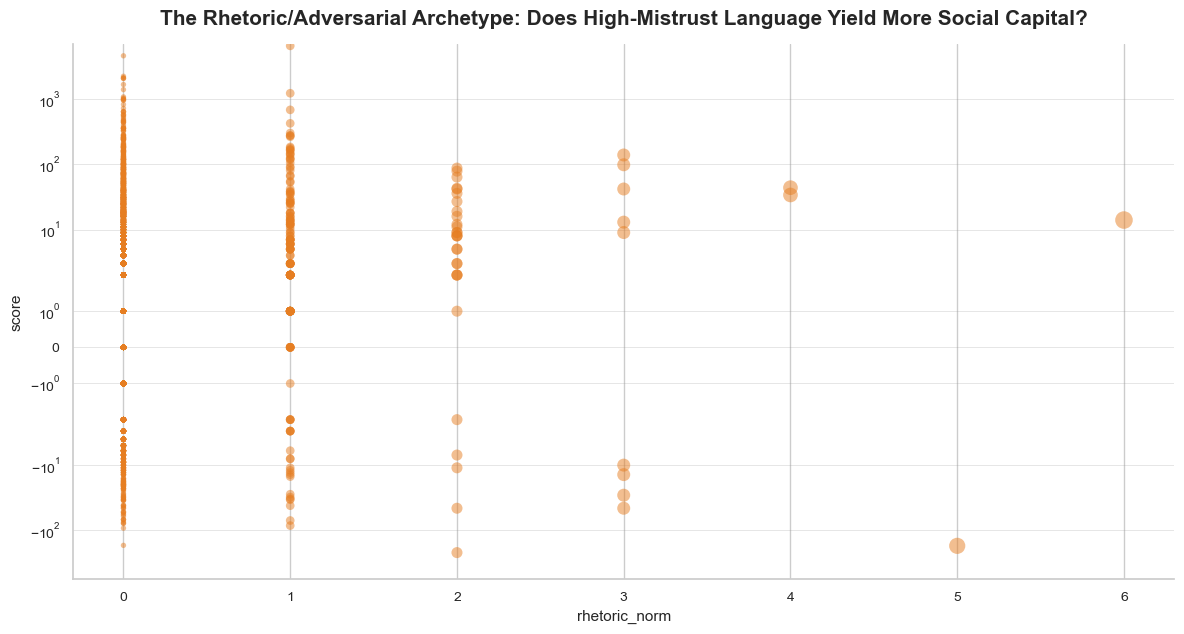

In [108]:
# 1. Aggregate Lexical Dimensions by Author for the Gold Standard Threads
df_commenters = df_raw.groupby('author').agg({
    'score': 'sum', # Total upvotes earned in these threads
    **{f'{name}_count': 'sum' for name in dimensions.keys()}
}).reset_index()

# 2. Normalize to "Dimensions per 100 comments" 
# (Totaling counts per author so we aren't biased by length-per-comment)
for name in dimensions.keys():
    df_commenters[f'{name}_norm'] = df_commenters[f'{name}_count'] 

# 3. Correlation: How does an archetype perform?
corr_matrix_authors = df_commenters[[f'{d}_norm' for d in dimensions.keys()] + ['score']].corr()

# 4. Visualization
import utils.visualization as viz
viz.plot_archetype_performance(df_commenters)

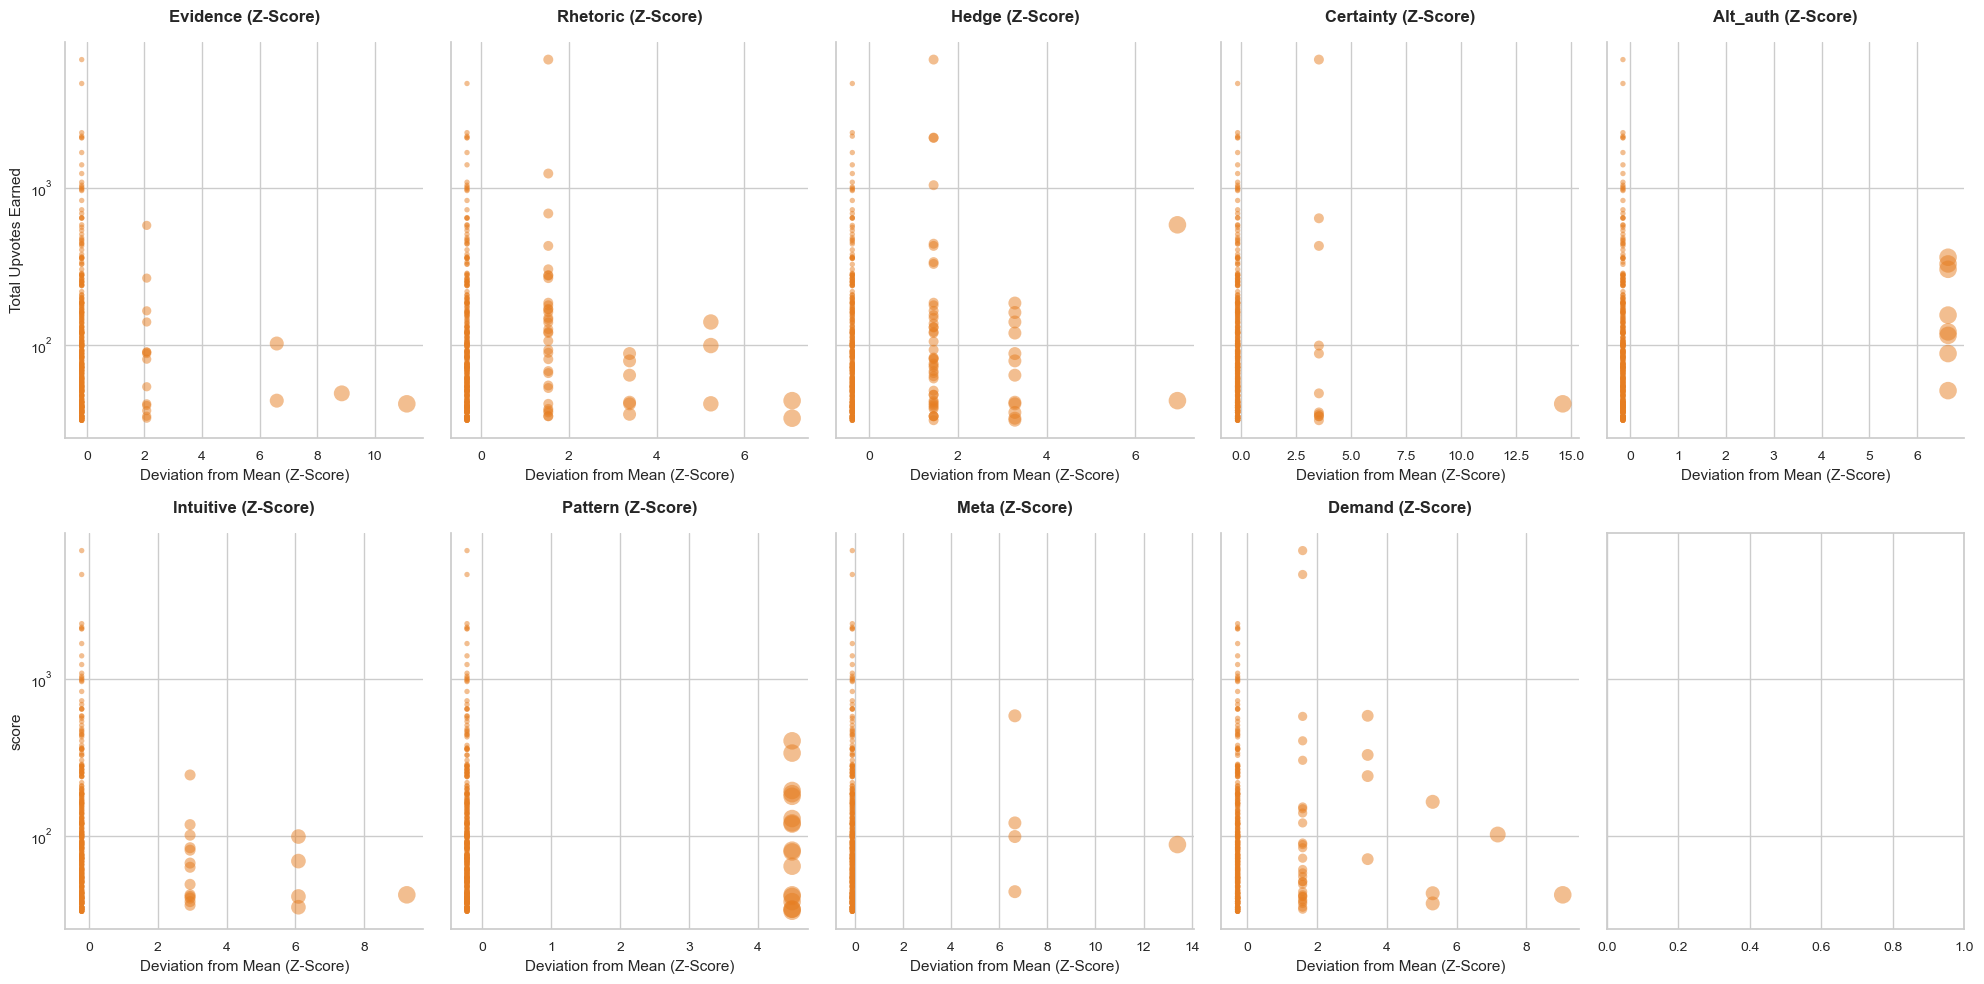

In [109]:
from sklearn.preprocessing import StandardScaler
# 1. & 2. (Keep your existing filtering and scaling logic)
volume_threshold = df_commenters['score'].quantile(0.9) 
df_power_users = df_commenters[df_commenters['score'] >= volume_threshold].copy()

scaler = StandardScaler()
dim_cols = [f'{name}_count' for name in dimensions.keys()]
df_power_users[dim_cols] = scaler.fit_transform(df_power_users[dim_cols])

import utils.visualization as viz
viz.plot_zscore_power_users(df_power_users, dim_cols)

---
### 9.10 Full-Corpus Scale-Up & Maverick Authority Analysis

This section integrates the massive 21.5-million-row scale-up results. Rather than analyzing a subset of gold-standard threads, we join our staged classification scores (Personal Experience and Procedural Skepticism) with the full Empath baseline lexicons. We also load our localized Maverick Authority entity lift list, which resolves bag-of-words classification limits by performing spaCy NER strictly on predicted trigger spans.

In [110]:
import pandas as pd
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("=== LOADING FULL-CORPUS CONSTRUCT CORRELATION MATRIX (21.5M rows) ===")
corr_path = 'data/processed/construct_correlation_matrix.csv'
if os.path.exists(corr_path):
    df_corr = pd.read_csv(corr_path, index_col=0)
    display(df_corr[['pe_prob', 'ps_prob', 'evidence_count', 'hedge_count', 'anecdotal_count', 'char_length', 'has_link']])
else:
    print("Correlation matrix CSV not found. Run src/compute_correlation_matrix.py first.")

print("\n=== LOADING FULL-CORPUS ENGAGEMENT REGRESSIONS (21.5M rows) ===")
reg_path = 'data/processed/engagement_regression_results.csv'
if os.path.exists(reg_path):
    df_reg = pd.read_csv(reg_path)
    for name in ['Personal Experience', 'Procedural Skepticism']:
        print(f"\n--- {name.upper()} Decile Summary ---")
        sub = df_reg[df_reg['construct'] == name][['decile', 'min_score', 'max_score', 'median_upvotes', 'mean_upvotes', 'controversiality_rate', 'high_traction_rate', 'count']]
        display(sub)
else:
    print("Regression results CSV not found. Run src/compute_engagement_regression.py first.")

print("\n=== LOADING SPAN-LOCALIZED MAVERICK AUTHORITY ENTITIES (n=108 candidates) ===")
mav_path = 'data/processed/maverick_authority_entities_localized.csv'
if os.path.exists(mav_path):
    df_mav = pd.read_csv(mav_path)
    print("Top 25 Maverick Authority Entities by Lift (min 2 positive mentions):")
    display(df_mav[df_mav['positive_mentions'] >= 2].head(25))
else:
    print("Localized maverick entities CSV not found. Run src/extract_maverick_entities_localized.py first.")

=== LOADING FULL-CORPUS CONSTRUCT CORRELATION MATRIX (21.5M rows) ===


,pe_prob,ps_prob,evidence_count,hedge_count,anecdotal_count,char_length,has_link
pe_prob,1.0000,0.0495,0.0397,0.1283,0.1795,0.2568,-0.0537
ps_prob,0.0495,1.0000,0.4048,0.0892,0.0350,0.2241,0.0026
evidence_count,0.0397,0.4048,1.0000,0.0775,0.0261,0.2815,0.1085
adversarial_count,0.0415,0.1880,0.0552,0.0598,0.0295,0.1681,-0.0314
hedge_count,0.1283,0.0892,0.0775,1.0000,0.0911,0.2808,-0.0501
certainty_count,0.0269,0.0912,0.0549,0.0408,0.0171,0.1073,-0.0079
alt_authority_count,0.0271,0.0614,0.1093,0.0502,0.0144,0.1511,0.0299
intuitive_count,0.0351,0.2020,0.0317,0.0566,0.0238,0.1154,-0.0232
pattern_count,0.0601,0.0525,0.0562,0.0784,0.0383,0.1815,0.0051
meta_count,0.0124,0.0990,0.0335,0.0255,0.0093,0.0644,-0.0083



=== LOADING FULL-CORPUS ENGAGEMENT REGRESSIONS (21.5M rows) ===

--- PERSONAL EXPERIENCE Decile Summary ---


,decile,min_score,max_score,median_upvotes,mean_upvotes,controversiality_rate,high_traction_rate,count
0,0,0.0000,0.4460,1.0000,4.9903,0.0788,0.2216,19373323
1,1,0.4460,0.6358,2.0000,5.7113,0.0739,0.2451,2152592



--- PROCEDURAL SKEPTICISM Decile Summary ---


,decile,min_score,max_score,median_upvotes,mean_upvotes,controversiality_rate,high_traction_rate,count
2,0,0.0000,0.5398,1.0000,5.1289,0.0770,0.2245,19373323
3,1,0.5398,0.6780,1.0000,4.4642,0.0901,0.2187,2152592



=== LOADING SPAN-LOCALIZED MAVERICK AUTHORITY ENTITIES (n=108 candidates) ===
Top 25 Maverick Authority Entities by Lift (min 2 positive mentions):


,entity,positive_mentions,negative_mentions,positive_rate,negative_rate,lift
0,Julian,3,0,0.0330,0.0000,4.3300
1,CIA,6,1,0.0670,0.0100,3.8300
2,WikiLeaks,2,0,0.0220,0.0000,3.2200
3,Seymour Hersh,2,0,0.0220,0.0000,3.2200
67,FBI,3,2,0.0330,0.0200,1.4400
68,Assange,6,6,0.0670,0.0600,1.1000


In [111]:
srchsr = '%well.](https://youtu.be/rdrKCilEhC0?t=1313%'

In [112]:
import duckdb

# Get columns directly from a Parquet file
df_info = duckdb.sql(f'''
DESCRIBE SELECT * FROM '{EMPATH}'
''').df()
print(df_info[["column_name", "column_type"]])


            column_name column_type
0                    id     VARCHAR
1                author     VARCHAR
2               upvotes      DOUBLE
3      controversiality      BIGINT
4             parent_id     VARCHAR
5               link_id     VARCHAR
6           created_utc      BIGINT
7           char_length      BIGINT
8              has_link     INTEGER
9                  text     VARCHAR
10       evidence_count     INTEGER
11    adversarial_count     INTEGER
12          hedge_count     INTEGER
13      certainty_count     INTEGER
14  alt_authority_count     INTEGER
15      intuitive_count     INTEGER
16        pattern_count     INTEGER
17           meta_count     INTEGER
18         demand_count     INTEGER
19      anecdotal_count     INTEGER
20   quantitative_count     INTEGER


In [113]:
import duckdb

search_term = srchsr # The % signs are wildcards

query = f"""
    SELECT * 
    FROM '{EMPATH}' 
    WHERE text ILIKE '{search_term}'
"""

# DuckDB filters on disk and only pulls matching rows into memory
filtered_df = duckdb.sql(query).df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [114]:
filtered_df

,id,author,upvotes,controversiality,parent_id,link_id,created_utc,char_length,has_link,text,evidence_count,adversarial_count,hedge_count,certainty_count,alt_authority_count,intuitive_count,pattern_count,meta_count,demand_count,anecdotal_count,quantitative_count
0,gre493r,hIXhnWUmMvw,1.0000,0,t1_grb06iu,t3_m7fc2c,1616091903,1998,1,"\n[We live in a pretend society.](https://pastebin.com/YPEErwTK)\n\n\n[Is your mind blown how people fall for same thing every time? It shouldn't be. Because divided, singled out individuals has no chance against organized criminal entity; corporation.](https://archive.org/details/TheCorp)\n\nCo...",1,0,0,0,0,0,1,0,0,0,0
1,gt266ac,hIXhnWUmMvw,10.0000,0,t3_mi0rk7,t3_mi0rk7,1617302457,1998,1,"\n[We live in a pretend society.](https://pastebin.com/YPEErwTK)\n\n\n[Is your mind blown how people fall for same thing every time? It shouldn't be. Because divided, singled out individuals has no chance against organized criminal entity; corporation.](https://archive.org/details/TheCorp)\n\nCo...",1,0,0,0,0,0,1,0,0,0,0
2,gt5bapa,hIXhnWUmMvw,3.0000,0,t1_gt4ub0m,t3_mig3xw,1617376119,1997,1,"[We live in a pretend society.](https://pastebin.com/YPEErwTK)\n\n\n[Is your mind blown how people fall for same thing every time? It shouldn't be. Because divided, singled out individuals has no chance against organized criminal entity; corporation.](https://archive.org/details/TheCorp)\n\nCorp...",1,0,0,0,0,0,1,0,0,0,0
3,gtgya0f,hIXhnWUmMvw,8.0000,0,t1_gtghm86,t3_mklu1q,1617641138,1997,1,"[We live in a pretend society.](https://pastebin.com/YPEErwTK)\n\n\n[Is your mind blown how people fall for same thing every time? It shouldn't be. Because divided, singled out individuals has no chance against organized criminal entity; corporation.](https://archive.org/details/TheCorp)\n\nCorp...",1,0,0,0,0,0,1,0,0,0,0
4,gukuhu1,hIXhnWUmMvw,1.0000,0,t1_gujips2,t3_mqzobo,1618468261,1997,1,"[We live in a pretend society.](https://pastebin.com/YPEErwTK)\n\n\n[Is your mind blown how people fall for same thing every time? It shouldn't be. Because divided, singled out individuals has no chance against organized criminal entity; corporation.](https://archive.org/details/TheCorp)\n\nCorp...",1,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1256,j2mfe48,hIXhnWUmMvw,-3.0000,0,t1_j2k9hmo,t3_100whvd,1672661123,2237,1,"AOA and [We live in a pretend society.](https://pastebin.com/YPEErwTK)\n\n[Is your mind blown how people fall for same thing every time? It shouldn't be. Because divided, singled out individuals has no chance against organized criminal entity; corporation.](https://archive.org/details/TheCorp)\n...",1,0,0,0,0,0,1,0,0,0,0
1257,j2mjiny,hIXhnWUmMvw,2.0000,0,t1_j2kte5p,t3_100umtp,1672664020,2237,1,"Because [We live in a pretend society?](https://pastebin.com/YPEErwTK)\n\n[Is your mind blown how people fall for same thing every time? It shouldn't be. Because divided, singled out individuals has no chance against organized criminal entity; corporation.](https://archive.org/details/TheCorp)\n...",1,0,0,0,0,0,1,0,0,0,0
1258,j2mktgk,hIXhnWUmMvw,1.0000,0,t1_j2ipjo0,t3_100leuq,1672664854,2229,1,"[We live in a pretend society.](https://pastebin.com/YPEErwTK)\n\n[Is your mind blown how people fall for same thing every time? It shouldn't be. Because divided, singled out individuals has no chance against organized criminal entity; corporation.](https://archive.org/details/TheCorp)\n\nCorpor...",1,0,0,0,0,0,1,0,0,0,0
1259,j31zkfl,hIXhnWUmMvw,-9.0000,0,t1_j31dogl,t3_103v0cd,1672929873,2697,1,"\n[We live in a pretend society.](https://pastebin.com/YPEErwTK)\n\n[Is your mind blown how people fall for same thing every time? It shouldn't be. Because divided, singled out individuals has no chance against organized criminal entity; corporation.](https://archive.org/details/TheCorp)\n\nCorp...",1,0,0,0,0,0,1,0,0,0,0


**Entity spot-checks**: ad-hoc lookups against the authoritative disambiguated entity table
(`entity_final_review.csv`, produced by `src/stage_e_consolidate.py` and consumed by the core
regression, `consensus_experts_verified.py`, and `combined_maverick_detector.py` — see
`handoff/PROJECT_INVENTORY.md`). Not a new finding on its own; this inspects the bucket
labels (`final_bucket_guess`) and spot-checks individual entities to sanity-check the
allowlists used elsewhere in the pipeline.

> **Dating caveat (found during a 2026-07-18 documentation pass):** `entity_final_review.csv` was generated **2026-07-14**, but `stage_e_consolidate.py`, `build_historical_officeholders.py`, `flag_non_person_contamination.py`, and `consensus_experts_verified.py` were all modified the **next day** (2026-07-15, commits `0a14e33`/`f58f3a9`) specifically to fix consensus-expert contamination and non-person false positives. This file has not been regenerated since those fixes, so the entity buckets spot-checked below may not reflect the corrected allowlists. This is an entity-list judgment call, not a documentation fix -- flagging for Nash/Antigravity to confirm whether `entity_final_review.csv` needs regenerating, not deciding it here.


In [115]:
NER = pd.read_csv(BASE + 'entity_final_review.csv')

In [116]:
NER.columns

Index(['entity', 'doc_count', 'best_identity', 'wp_description', 'final_bucket_guess', 'bucket_confidence', 'disambiguation_note', 'likely_pure_junk', 'dual_purpose_word', 'corpus_example', 'in_candidate_list', 'final_decision', 'natural_cluster', 'weak_hint_bucket_guess', 'has_expert_credential', 'epistemic_authority_kind', 'has_institutional_insider'], dtype='object')

In [117]:
NER['final_bucket_guess'].unique()

array(['mainstream_figure_not_source', 'AMBIGUOUS_CLUSTER', nan,
       'maverick_authority', 'AMBIGUOUS_NAME', 'villain',
       'mainstream_source', 'AMBIGUOUS_NAME_PARTITIONED',
       'alternative_source', 'mainstream_expert_authority', 'other'],
      dtype=object)

In [118]:
NER[NER['final_bucket_guess']=='mainstream_expert_authority']

,entity,doc_count,best_identity,wp_description,final_bucket_guess,bucket_confidence,disambiguation_note,likely_pure_junk,dual_purpose_word,corpus_example,in_candidate_list,final_decision,natural_cluster,weak_hint_bucket_guess,has_expert_credential,epistemic_authority_kind,has_institutional_insider
51,Lancet,2310.0000,The Lancet,Academic journal,mainstream_expert_authority,reliable_categories,NaN,False,True,"...anchester Royal Infirmary, almost certainly of an immune deficiency. His case was written up in The Lancet of 29 October 1960 by Trevor Stretton, John Leonard (his doctors) and George Williams (the patholog... || ...s repeated with a blind control. Still positive. The doctors went public with...",False,NaN,NaN,mainstream_expert_authority,True,formal_credential,False
172,Einstein,1129.0000,Albert Einstein,German-born theoretical physicist (1879–1955),mainstream_expert_authority,reliable_categories,NaN,False,False,NaN,False,NaN,NaN,mainstream_expert_authority,True,formal_credential,False
365,Plato,681.0000,Plato,Ancient Greek philosopher,mainstream_expert_authority,reliable_categories,NaN,False,False,...Greek verb kubernan which means to steer and was used for the first time in a metaphorical sense by Plato. It then passed on to Latin and then on to many languages.[1] from [http://www.answers.com/topic/g... || Socrates never fucked a boy over twelve. That's not gay. And Plato gave his own ...,False,NaN,NaN,mainstream_expert_authority,True,formal_credential,False
401,Antony C. Sutton,645.0000,Antony C. Sutton,British-American researcher (1925–2002),mainstream_expert_authority,reliable_categories,NaN,False,False,NaN,False,NaN,NaN,mainstream_expert_authority,True,formal_credential,False
434,Dershowitz,611.0000,Alan Dershowitz,American lawyer and author (born 1938),mainstream_expert_authority,reliable_categories,NaN,False,False,...on to take place. Attack the person who *dared* to speak out. Change the subject at all costs. Alan Dershowitz is a master of that tactic. He'll even pull it out when debating a fellow Jew. Pathetic. Here's a... || ...ggy Siegal says Epstein’s two big charitable causes are science** and Isra...,False,NaN,NaN,mainstream_expert_authority,True,formal_credential,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15760,Christine Grady,20.0000,Christine Grady,Nurse-bioethicist and researcher,mainstream_expert_authority,reliable_categories,NaN,False,False,NaN,False,NaN,NaN,mainstream_expert_authority,True,formal_credential,False
15803,Angela Merkel's,20.0000,Angela Merkel,Chancellor of Germany from 2005 to 2021,mainstream_expert_authority,reliable_categories,NaN,False,False,"Yes, but why is the MSM focused on Angela Merkel's phone... when we have reliable whistleblowers (who have been proven correct) saying, for example, t... || ...your surveillance mostly useless? Dang, better use all that surveillance for something, how about Angela Merkel's emails, that's gotta...",False,NaN,NaN,mainstream_expert_authority,True,formal_credential,False
15885,Robert Koch,20.0000,Robert Koch,German physician and bacteriologist (1843–1910),mainstream_expert_authority,reliable_categories,NaN,False,False,"...Duesburg, get AIDS? > HIV now fulfills the classic postulates of disease causation established by Robert Koch and > AZT and illicit drugs, which Duesberg argues can cause AIDS, don’t cause the immune defici... || ...or example, the contest is set up very specific and asks for ONE study fr...",False,NaN,NaN,mainstream_expert_authority,True,formal_credential,False
15898,Science Advances,20.0000,Science Advances,American academic journal,mainstream_expert_authority,reliable_categories,NaN,False,False,"I know, right? Really though I think the days of major science advances, particularly in a field like physics, being made by amateur workshop tinkers and hobbyists are pas... || ...d if they weren't going to starve, they were in danger of dying much, much younger of disease. Our science advanc...",Fals

In [119]:
MSM = NER[NER['final_bucket_guess']=="mainstream_source"]

In [120]:
MSM

,entity,doc_count,best_identity,wp_description,final_bucket_guess,bucket_confidence,disambiguation_note,likely_pure_junk,dual_purpose_word,corpus_example,in_candidate_list,final_decision,natural_cluster,weak_hint_bucket_guess,has_expert_credential,epistemic_authority_kind,has_institutional_insider
23,the Washington Post,2827.0000,The Washington Post,American daily newspaper,mainstream_source,reliable_categories,NaN,False,False,NaN,False,NaN,NaN,mainstream_source,False,NaN,False
33,Guardian,2682.0000,The Guardian,British national daily newspaper,mainstream_source,reliable_categories,NaN,False,False,NaN,False,NaN,NaN,mainstream_source,False,NaN,False
37,DEA,2623.0000,Drug Enforcement Administration,United States federal law enforcement agency,mainstream_source,reliable_categories,NaN,False,False,NaN,False,NaN,NaN,mainstream_source,False,NaN,False
38,WaPo,2608.0000,The Washington Post,American daily newspaper,mainstream_source,reliable_categories,NaN,False,False,"...n.com for bringing this to light (for me, anyway; I had no idea and don't generally read the filthy WaPo or bother with local news) || .../www.washingtonpost.com/wp-dyn/content/gallery/2009/06/10/GA2009061002480.html?sid=ST2009061402807 WaPo is a known propaganda outlet so we can trust their...",False,NaN,NaN,mainstream_source,False,NaN,False
39,NPR,2593.0000,NPR,American nonprofit media organization,mainstream_source,reliable_categories,NaN,False,False,NaN,False,NaN,NaN,mainstream_source,False,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15750,U.S. Department of Health and Human Services,20.0000,United States Department of Health and Human Services,Department of the U.S. federal government,mainstream_source,reliable_categories,NaN,False,False,NaN,False,NaN,NaN,mainstream_source,False,NaN,False
15758,the United States National Security Agency,20.0000,National Security Agency,U.S. signals intelligence organization,mainstream_source,reliable_categories,NaN,False,False,"It's funny because NSA created SELinux too. >[The United States National Security Agency (NSA), the original primary developer of SELinux...](http://en.wikipedia.org/wiki/Security-Enhanced... || I work for the United States National Security Agency and I just bought this reddit username for $10...",False,NaN,NaN,mainstream_source,False,NaN,False
15881,Magazine,20.0000,Magazine,Publication that is typically distributed at a regular interval,mainstream_source,reliable_categories,NaN,False,True,"...k out ""Forged Origins of the New Testament"" and ""Criminal History of the Papacy""\r \r http://www.nexusmagazine.com/index.php?option=com_docman&task=cat_view&gid=30&Itemid=71 || [Scroogled](http://www.radaronline.com/from-the-magazine/2007/09/google_fiction_evil_dangerous_surveillance_control_...",False,NaN,NaN,mainstream_source,False,NaN,False
15932,Executive Intelligence,8.0000,Executive Intelligence Review,American LaRouchist magazine,mainstream_source,reliable_categories,NaN,False,False,NaN,False,NaN,NaN,mainstream_source,False,NaN,False


In [121]:
MA = NER[NER['final_bucket_guess']=='maverick_authority']

In [122]:
MA[:100]

,entity,doc_count,best_identity,wp_description,final_bucket_guess,bucket_confidence,disambiguation_note,likely_pure_junk,dual_purpose_word,corpus_example,in_candidate_list,final_decision,natural_cluster,weak_hint_bucket_guess,has_expert_credential,epistemic_authority_kind,has_institutional_insider
3,Seth Rich,9139.0000,Murder of Seth Rich,"2016 unsolved murder in Washington, D.C., US",maverick_authority,reliable_categories,NaN,False,False,"Debbie Wasserman Schultz today: > “Seth Rich was a dedicated, selfless public servant who worked tirelessly to protect *the most sacred right we... || You misunderstood. I'm saying that Seth Rich may have been involved in voter fraud *for* Clinton and *against* Sanders. Sanders supporters fou...",False,NaN,NaN,maverick_authority,False,NaN,False
4,Alex Jones,8243.0000,Alex Jones,American radio host (born 1974),maverick_authority,reliable_categories,NaN,False,False,"I know how most of reddit feels about anything Alex Jones has to say. But this much is sadly true. >If 125 film stars booked out a hotel, arrived in dark-tin... || Alex Jones was running the exact same story about these plastic coffins in Georgia almost 3 years ago, claimin... || ...ning it's a ...",True,NaN,NaN,maverick_authority,False,NaN,False
18,Elon Musk,2965.0000,Elon Musk,Businessman and public official (born 1971),maverick_authority,reliable_categories,NaN,False,False,...aze back to Earth http://phys.org/news/2012-05-famed-alien-seeker-shifts-earth.html Interview: Elon Musk on what's next for SpaceX http://www.newscientist.com/blogs/onepercent/2012/05/spacex-the-apple-of... || I would rather give 3 billion to Elon Musk. IMHO the whole shuttle program wa...,False,NaN,NaN,maverick_authority,True,formal_credential,False
43,QAnon,2511.0000,QAnon,American conspiracy theory and political movement,maverick_authority,reliable_categories,NaN,False,False,NaN,False,NaN,NaN,maverick_authority,False,NaN,False
58,Joe Rogan,2198.0000,Joe Rogan,American podcaster and comedian (born 1967),maverick_authority,reliable_categories,NaN,False,False,NaN,True,NaN,NaN,maverick_authority,False,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2943,David Icke's,116.0000,David Icke,English conspiracy theorist (born 1952),maverick_authority,reliable_categories,NaN,False,False,NaN,False,NaN,NaN,maverick_authority,False,NaN,False
3043,Mike Yeadon,112.0000,Michael Yeadon,British researcher and conspiracy theorist,maverick_authority,reliable_categories,NaN,False,False,"...is the important thing… you don’t find weak evidence. What you find, folks is fraud. Fraud.” -Dr. Mike Yeadon || Mike Yeadon had a talk with James Delingpole on Rumble in a church a few years ago and Mike Yeadon said that Iv... || Mike Yeadon had a talk with James Delingpole on Rumble in a c...",False,NaN,NaN,maverick_authority,True,"formal_credential, institutional_insider",True
3081,Robert David Steele,110.0000,Robert David Steele,American CIA officer and conspiracy theorist (1952–2021),maverick_authority,reliable_categories,NaN,False,False,NaN,True,NaN,NaN,maverick_authority,True,formal_credential,False
3084,Russel Brand,110.0000,Russell Brand,"English comedian, actor, and podcaster (born 1975)",maverick_authority,reliable_categories,NaN,False,False,"...why it's posted here. It's more that point that annoys me than anything. The fact that just because Russel Brand said it, and he also said something about the corporations... that it gets posted here straight awa... || Interesting that you mention Russel Brand because I believe his Ex-Wife, K...",False,NaN,NaN,maverick_authority,False,NaN,False


In [123]:
NER[NER['entity']=='Graham Hancock']

,entity,doc_count,best_identity,wp_description,final_bucket_guess,bucket_confidence,disambiguation_note,likely_pure_junk,dual_purpose_word,corpus_example,in_candidate_list,final_decision,natural_cluster,weak_hint_bucket_guess,has_expert_credential,epistemic_authority_kind,has_institutional_insider
625,Graham Hancock,469.0000,Graham Hancock,British writer (born 1950),maverick_authority,reliable_categories,NaN,False,False,"...f ancient history, it is much easier to understand the open conspiracy. fingerprints of the gods - graham hancock is a good one. secret teachings of all ages. anything along those lines || ...the Gods by Erich von Däniken (he actually has quite a few good books), Fingerprints of the Gods by ...",True,NaN,NaN,maverick_authority,True,formal_credential,False


---
### 9.11 Spam & Bot Detection

During source-citation resolution work on the YouTube-video references in Section 4.1.3, a small number of accounts turned out to be reposting the same or near-identical text hundreds to thousands of times — inflating raw comment counts if left unaccounted for. This section profiles the corpus for two related but distinct patterns, using only comment *metadata* (author name, comment count, distinct-text count per author) — no comment content is inspected to produce either flag:

- **Bots** — accounts following a Reddit bot-naming convention (`AutoModerator`, `*Bot`), or posting a tiny number of template texts an extreme number of times.
- **Repeat posters** — human accounts reposting the same or a small set of texts far more often than a typical author, without being a template bot.

Flags are computed at the author level by `src/detect_spam_bots.py` and written to a standalone parquet file, left-joinable onto the corpus rather than mutating it — downstream analyses can then choose to exclude, cap, or separately study this activity.

In [124]:
import os
import subprocess

FLAGS_PATH = BASE + 'author_spam_bot_flags.parquet'

if not os.path.exists(FLAGS_PATH):
    print("Flags not found — running src/detect_spam_bots.py...")
    subprocess.run(['python3', '-m', 'src.detect_spam_bots'], check=True, cwd=str(REPO_ROOT))
else:
    print("Loaded cached spam/bot flags.")

Loaded cached spam/bot flags.


In [125]:
summary_query = f"""
    SELECT
        CASE
            WHEN is_likely_bot THEN 'bot'
            WHEN is_repeat_poster THEN 'repeat_poster'
            ELSE 'normal'
        END AS category,
        COUNT(*) AS n_authors,
        SUM(n_comments) AS n_comments,
        ROUND(100.0 * SUM(n_comments) / SUM(SUM(n_comments)) OVER (), 2) AS pct_of_comments
    FROM '{FLAGS_PATH}'
    GROUP BY category
    ORDER BY n_comments DESC
"""
df_spam_summary = con.execute(summary_query).df()
print(df_spam_summary.to_string(index=False))

     category  n_authors    n_comments  pct_of_comments
       normal     847511 19497218.0000          98.7600
          bot       1051   210303.0000           1.0700
repeat_poster        201    35324.0000           0.1800


In [126]:
top_offenders_query = f"""
    SELECT
        author, n_comments, n_distinct_texts, dup_ratio,
        CASE WHEN is_likely_bot THEN 'bot' WHEN is_repeat_poster THEN 'repeat_poster' END AS category
    FROM '{FLAGS_PATH}'
    WHERE is_likely_bot OR is_repeat_poster
    ORDER BY n_comments DESC
    LIMIT 20
"""
df_top_offenders = con.execute(top_offenders_query).df()
df_top_offenders

,author,n_comments,n_distinct_texts,dup_ratio,category
0,rConBot,136940,8,17117.5000,bot
1,AmputatorBot,15706,13631,1.1500,bot
2,AssuredlyAThrowAway,11858,4517,2.6300,repeat_poster
3,Reddit-Book-Bot,11005,121,90.9500,bot
4,oatballlove,6265,4080,1.5400,repeat_poster
5,RemindMeBot,5481,5458,1.0000,bot
6,User_Name13,2142,1263,1.7000,repeat_poster
7,sixrwsbot,2023,2021,1.0000,bot
8,WikiSummarizerBot,1938,1640,1.1800,bot
9,hIXhnWUmMvw,1788,503,3.5500,repeat_poster


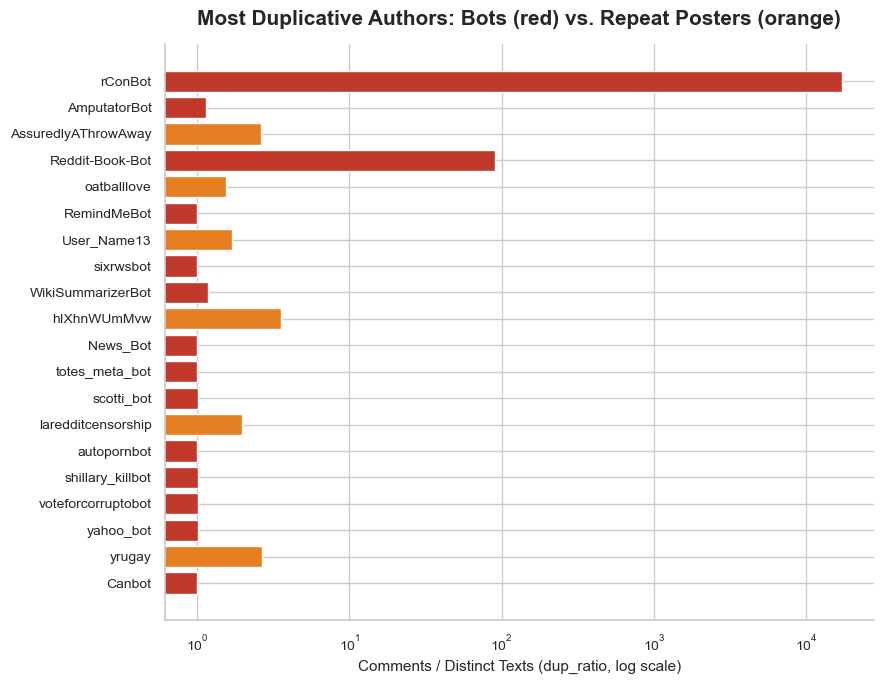

In [127]:
df_plot = con.execute(f"""
    SELECT author, dup_ratio, is_likely_bot
    FROM '{FLAGS_PATH}'
    WHERE is_likely_bot OR is_repeat_poster
    ORDER BY n_comments DESC
    LIMIT 20
""").df()
viz.plot_spam_bot_top_authors(df_plot)

> **Takeaway:** bots and human repeat-posters together account for a little over 1% of comments corpus-wide — small in aggregate, but concentrated enough on individual items (one account alone contributing over a thousand near-identical posts) to distort per-item counts such as "top referenced YouTube video." Any analysis that treats raw comment counts as independent evidence — citation counts, topic frequency, engagement totals — should join against `author_spam_bot_flags.parquet` and either drop `is_likely_bot` rows or cap `is_repeat_poster` contributions to one per (author, text) pair.

---
### 9.12 Near-Duplicate Spam Detection (Fuzzy, Cross-Author)

Section 9.11 catches copypasta only when the *same author* reuses the *exact same* text. It misses two patterns that matter just as much:

- the same author reposting the same claim with **minor edits** (a swapped link, an added sentence) — invisible to exact-text matching;
- a **coordinated campaign** where *different* accounts post near-identical text — no single author's stats look unusual, so per-author detection can't see it.

This section runs `src/detect_near_duplicate_spam.py`: 4-word shingles → MinHash (64 permutations) → locality-sensitive hashing (Jaccard threshold 0.75), streamed in chunks so the corpus is never fully materialized in memory. It only considers comments longer than a char_length threshold (copypasta-scale text) and skips authors already flagged as bots in 9.11. Results are written to a standalone parquet (`near_duplicate_clusters.parquet`) rather than mutating the corpus.

**Incremental coverage:** this machine has ~8GB RAM with as little as ~1.3GB free during normal use, so the detector was run conservatively high first (`--min-char-length 2000`, ~220K candidates) and then extended downward (`--min-char-length 1500 --max-char-length 2000`, ~186K more candidates) once the memory situation allowed, rather than reprocessing everything from scratch. `near_duplicate_clusters.parquet` accumulates across these runs (merged on `comment_id`, no reprocessing of already-covered ranges), and `near_duplicate_clusters_meta.json` tracks the true lowest char_length covered so downstream cells don't need to hardcode a threshold. Lowering further (toward `--min-char-length 1000`, ~930K candidates at full scale — a 150K-candidate dry run at that threshold held under 600MB RSS) is reasonable whenever more RAM is free; rerun with `--max-char-length` set to the current coverage boundary to avoid duplicating work.

In [128]:
import os
import subprocess

NEAR_DUP_PATH = BASE + 'near_duplicate_clusters.parquet'

if not os.path.exists(NEAR_DUP_PATH):
    print("Near-duplicate clusters not found — running src/detect_near_duplicate_spam.py (several minutes)...")
    subprocess.run(['python3', '-m', 'src.detect_near_duplicate_spam'], check=True, cwd=str(REPO_ROOT))
else:
    print("Loaded cached near-duplicate clusters.")

Loaded cached near-duplicate clusters.


In [129]:
import json as _json

with open(BASE + 'near_duplicate_clusters_meta.json') as f:
    _meta = _json.load(f)
MIN_CHAR_COVERED = _meta['min_char_length_covered']

df_near_dup = con.execute(f"SELECT * FROM '{NEAR_DUP_PATH}'").df()
df_clusters = df_near_dup.drop_duplicates('cluster_id')

n_candidates = con.execute(f'''
    SELECT COUNT(*) FROM '{LEXICAL}' WHERE char_length > {MIN_CHAR_COVERED}
''').fetchone()[0]

print(f"Candidate comments (char_length > {MIN_CHAR_COVERED}): {n_candidates:,}")
print(f"Clusters found:                          {len(df_clusters):,}")
print(f"Comments in a cluster:                   {len(df_near_dup):,} ({100 * len(df_near_dup) / n_candidates:.1f}% of candidates)")
print(f"Cross-author clusters:                   {(df_clusters['n_distinct_authors'] > 1).sum():,}")
print(f"Comments in cross-author clusters:       {df_near_dup[df_near_dup['n_distinct_authors'] > 1].shape[0]:,}")

Candidate comments (char_length > 1500): 419,244
Clusters found:                          11,865
Comments in a cluster:                   48,410 (11.5% of candidates)
Cross-author clusters:                   2,369
Comments in cross-author clusters:       13,096


In [130]:
top_clusters = (
    df_clusters
    .sort_values('cluster_size', ascending=False)
    .head(15)[['cluster_id', 'cluster_size', 'n_distinct_authors']]
)
top_clusters

,cluster_id,cluster_size,n_distinct_authors
9208,hiwojgm,1031,1
37321,gre493r,445,2
36425,i3i5t0t,309,219
14609,mucklg7,307,1
14091,m8fd68d,184,1
13302,lai2akq,184,1
13574,lc31c99,166,1
3220,g09sklz,151,72
14449,mpwrvn8,145,1
40142,mxb9zqe,140,1


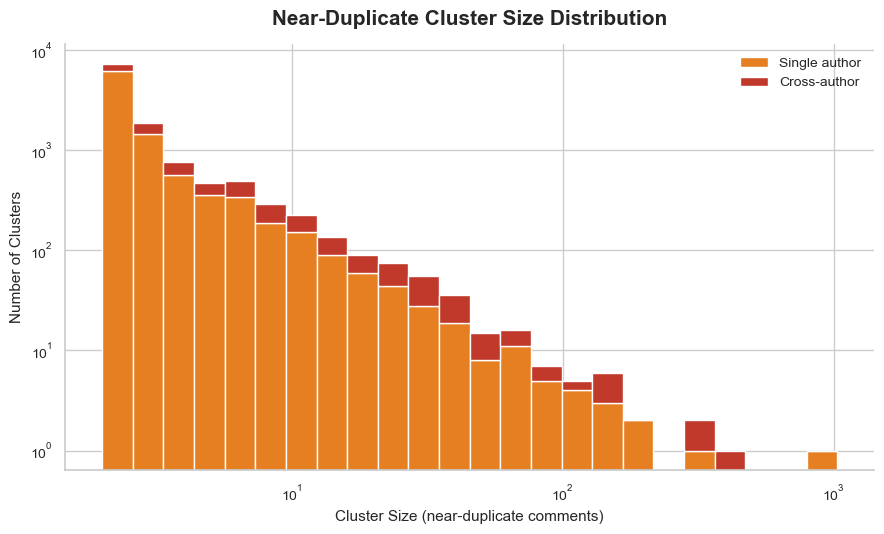

In [131]:
viz.plot_near_duplicate_cluster_sizes(df_clusters[['cluster_size', 'n_distinct_authors']])

> **Takeaway:** near-duplicate clustering surfaces two distinct patterns that exact-text matching cannot:
>
> 1. **Single-author near-dup campaigns bigger than exact matching suggested.** The account flagged in 9.11 as a repeat poster shows an even larger footprint here once minor text variations are counted as duplicates — the true scale of one account's repetition is understated by exact-match ratios alone.
> 2. **Genuine cross-author clusters** — comments spanning dozens of distinct accounts posting near-identical text. This is the pattern per-author statistics structurally cannot detect, since no single account's numbers look unusual in isolation. Whether this reflects coordinated posting, a widely-copied reference document, or independent users quoting the same external source is a question for manual review of the flagged clusters, not something the detector itself resolves.
>
> As with 9.11, treat these as **flags for downstream weighting**, not grounds for deletion: join `near_duplicate_clusters.parquet` on `comment_id` and cap each cluster's contribution to any claim-frequency or citation-count analysis rather than counting every near-duplicate as independent evidence.